In [80]:
import pandas as pd # type: ignore
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from matplotlib import font_manager, rc
import matplotlib.dates as mdates

# 한글 폰트 설정 (나눔 폰트)
rc('font', family='Apple SD Gothic Neo')
# 폰트 크기 설정 (global 설정)
plt.rcParams.update({'font.size': 16})  # 모든 텍스트의 기본 폰트 크기 16으로 설정

In [110]:
df

Date,Jeju_HPI,입도관광객수 (외국인),유료관광지 방문객수 (외국인),유료관광지 방문객수 (전체),무료관광지 방문객수 (전체),인구이동 (전입),인구이동 (전출)
2004.1.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004.2.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004.3.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004.4.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004.5.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2024.8.15,109.2,NaN,NaN,NaN,NaN,NaN,NaN
2024.9.15,110.1,NaN,NaN,NaN,NaN,NaN,NaN
2024.10.15,111.6,NaN,NaN,NaN,NaN,NaN,NaN
2024.11.15,110.7,NaN,NaN,NaN,NaN,NaN,NaN


In [112]:
df["2011.1.15":"2020.1.15"]

Date,Jeju_HPI,입도관광객수 (외국인),유료관광지 방문객수 (외국인),유료관광지 방문객수 (전체),무료관광지 방문객수 (전체),인구이동 (전입),인구이동 (전출)
2011.1.15,50.3,23714.0,61872.0,964384.0,107416.0,12621.0,12661.0
2011.2.15,49.8,33519.0,74792.0,1018608.0,92350.0,14244.0,14026.0
2011.3.15,51.3,46819.0,117312.0,1418884.0,92743.0,8701.0,8402.0
2011.4.15,53.0,69257.0,124944.0,2187931.0,162683.0,5370.0,5149.0
2011.5.15,50.6,79044.0,125157.0,2296079.0,178491.0,5267.0,4964.0
...,...,...,...,...,...,...,...
2019.9.15,91.1,149038.0,93911.0,1151241.0,109419.0,6278.0,6236.0
2019.10.15,92.4,167893.0,141589.0,1500131.0,159625.0,7095.0,7012.0
2019.11.15,92.4,145783.0,115001.0,1163821.0,136988.0,7121.0,7017.0
2019.12.15,92.8,147851.0,126328.0,1020070.0,117468.0,8627.0,8651.0


/var/folders/pc/0_qqcqxd1fncd71rzs72fhr00000gn/T/ipykernel_51353/1379772206.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("./data/jeju.csv", index_col=0, parse_dates=True).T["2010.1.15":"2020.7.15"]


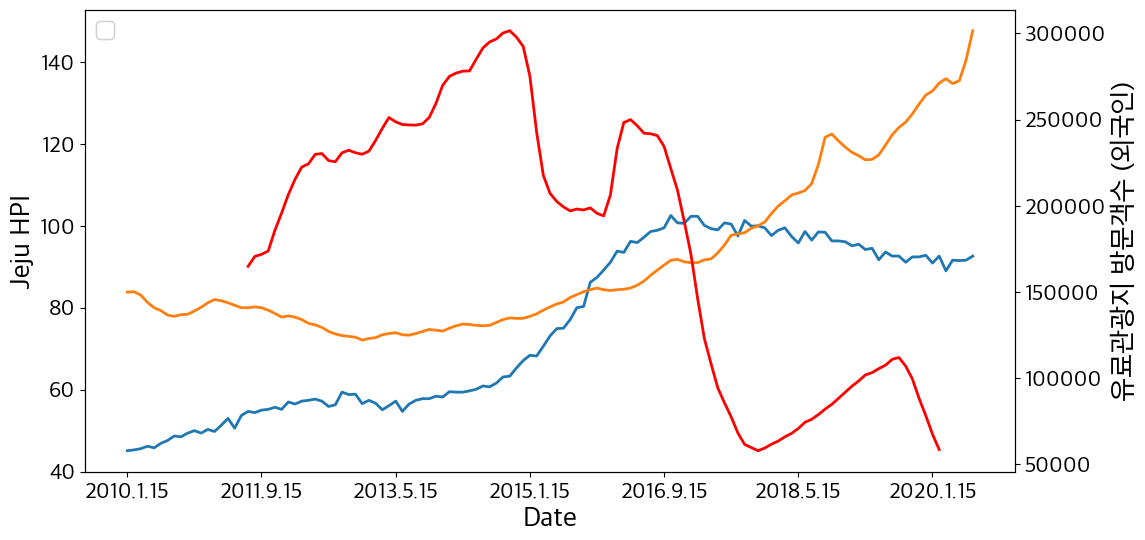

In [128]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1) CSV 읽을 때 날짜를 인덱스로 파싱
df = pd.read_csv("./data/jeju.csv", index_col=0, parse_dates=True).T["2010.1.15":"2020.7.15"]
# df["무료관광지 방문객수 (전체)"]
# 2) 왼쪽/오른쪽에 표시할 컬럼 지정
left_cols  = ["Jeju_HPI","Seoul_HPI"]     
right_cols = ["유료관광지 방문객수 (외국인)"]  # "유료관광지 방문객수 (외국인)", "인구이동 (전입)"

# 3) Figure/Axis 생성
fig, ax = plt.subplots(figsize=(12, 6))

# 4) 왼쪽 축에 그리기
df[left_cols].plot(ax=ax, linewidth=2)
ax.set_ylabel("Jeju HPI", fontsize=20)

# 5) 오른쪽 축 생성 & 그리기
ax2 = ax.twinx()
ax2.set_ylabel(right_cols[0], fontsize=20)
# df[right_cols].plot(ax=ax2, linestyle="--", color="red", linewidth=0.5)
df[right_cols].rolling(window=12, center=True).mean().plot(ax=ax2, color="red", linewidth=2)
# ax2.set_ylabel(right_cols[0], fontsize=20)

# 6) 범례, 레이블 정리
ax.set_xlabel("Date", fontsize=20)
ax.legend("", loc="upper left")
ax2.legend("", loc="upper left")

# plt.title("Jeju 데이터: 좌/우축 스케일 분리", fontsize=14)
# plt.tight_layout()
plt.show()


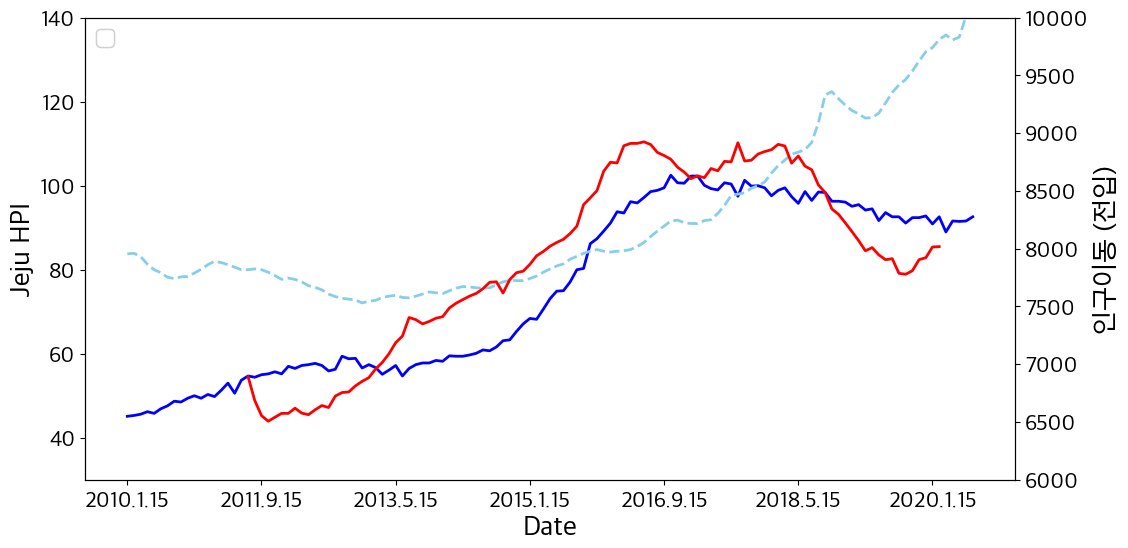

In [146]:
right_cols = ["인구이동 (전입)"]  # "유료관광지 방문객수 (외국인)", "인구이동 (전입)"

# 3) Figure/Axis 생성
fig, ax = plt.subplots(figsize=(12, 6))

# 4) 왼쪽 축에 그리기
df["Jeju_HPI"].plot(ax=ax, linewidth=2, color="blue")
ax.set_ylabel("Jeju HPI", fontsize=20)

# 5) 오른쪽 축 생성 & 그리기
ax2 = ax.twinx()
ax2.set_ylabel(right_cols[0], fontsize=20)
df["Seoul_HPI"].plot(ax=ax, linestyle="--", linewidth=2,color="skyblue")
# df[right_cols].plot(ax=ax2, linestyle="--", color="red", linewidth=0.5)
df[right_cols].rolling(window=12, center=True).mean().plot(ax=ax2, color="red", linewidth=2)
# ax2.set_ylabel(right_cols[0], fontsize=20)

# 6) 범례, 레이블 정리
ax.set_xlabel("Date", fontsize=20)
ax.legend("", loc="upper left")
ax2.legend("", loc="upper left")
ax.set_ylim(30, 140)
ax2.set_ylim(6000, 10000)
# plt.title("Jeju 데이터: 좌/우축 스케일 분리", fontsize=14)
# plt.tight_layout()
plt.show()

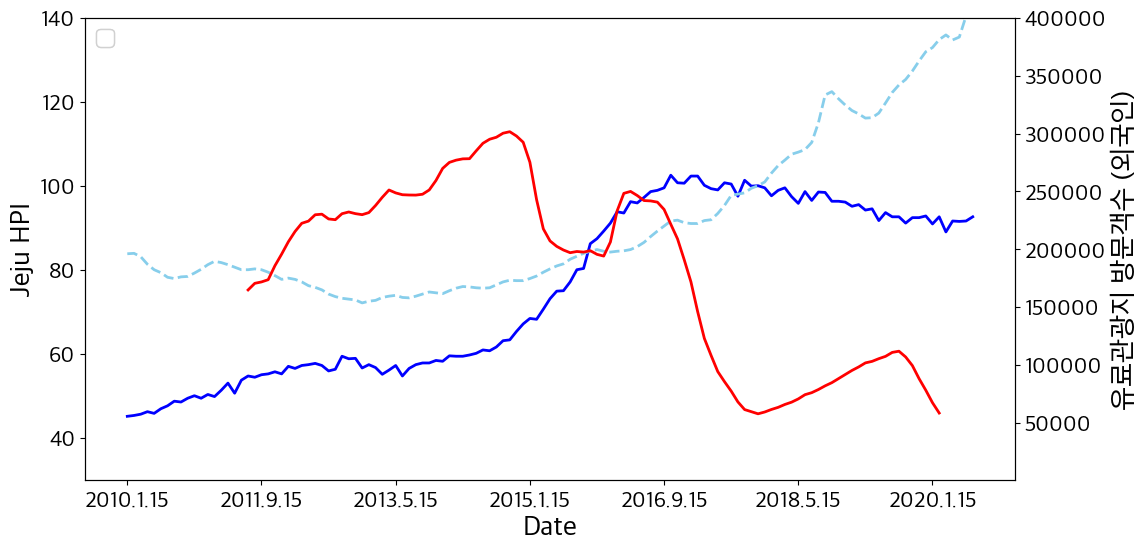

In [160]:
right_cols = ["유료관광지 방문객수 (외국인)"]  # "유료관광지 방문객수 (외국인)", "인구이동 (전입)"

# 3) Figure/Axis 생성
fig, ax = plt.subplots(figsize=(12, 6))

# 4) 왼쪽 축에 그리기
df["Jeju_HPI"].plot(ax=ax, linewidth=2, color="blue")
ax.set_ylabel("Jeju HPI", fontsize=20)

# 5) 오른쪽 축 생성 & 그리기
ax2 = ax.twinx()
ax2.set_ylabel(right_cols[0], fontsize=20)
df["Seoul_HPI"].plot(ax=ax, linestyle="--", linewidth=2,color="skyblue")
# df[right_cols].plot(ax=ax2, linestyle="--", color="red", linewidth=0.5)
df[right_cols].rolling(window=12, center=True).mean().plot(ax=ax2, color="red", linewidth=2)
# ax2.set_ylabel(right_cols[0], fontsize=20)

# 6) 범례, 레이블 정리
ax.set_xlabel("Date", fontsize=20)
ax.legend("", loc="upper left")
ax2.legend("", loc="upper left")
ax.set_ylim(30, 140)
ax2.set_ylim(1000, 400000)
# plt.title("Jeju 데이터: 좌/우축 스케일 분리", fontsize=14)
# plt.tight_layout()
plt.show()

In [173]:
df["인구이동 (전입) ma"] = df["인구이동 (전입)"].rolling(window=12, center=True).mean()

In [174]:
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests

data = df[["Jeju_HPI", "인구이동 (전입) ma"]].diff().dropna()  # 주의: grangercausalitytests는 NaN을 허용하지 않습니다.

# 3) 최대 시차 설정 (예: 1~12 시차까지 테스트)
maxlag = 30

# 4) Granger causality 테스트 실행
#    verbose=True로 상세 결과 출력
results = grangercausalitytests(data, maxlag=maxlag, verbose=True)

# 5) p-value만 간단히 추출해 보기
print(f"\n{'lag':<5}  {'ssr F p-value':>15}")
for lag, res in results.items():
    p_value = res[0]['ssr_ftest'][1]
    print(f"{lag:<5}  {p_value:>15.4f}")



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=19.5071 , p=0.0000  , df_denom=99, df_num=1
ssr based chi2 test:   chi2=20.0982 , p=0.0000  , df=1
likelihood ratio test: chi2=18.3450 , p=0.0000  , df=1
parameter F test:         F=19.5071 , p=0.0000  , df_denom=99, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=9.7675  , p=0.0001  , df_denom=96, df_num=2
ssr based chi2 test:   chi2=20.5524 , p=0.0000  , df=2
likelihood ratio test: chi2=18.7077 , p=0.0001  , df=2
parameter F test:         F=9.7675  , p=0.0001  , df_denom=96, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=5.8020  , p=0.0011  , df_denom=93, df_num=3
ssr based chi2 test:   chi2=18.7160 , p=0.0003  , df=3
likelihood ratio test: chi2=17.1564 , p=0.0007  , df=3
parameter F test:         F=5.8020  , p=0.0011  , df_denom=93, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=3.7138  , p=0.0076  , df_d

/Users/yeojisu/opt/anaconda3/envs/cv2024/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


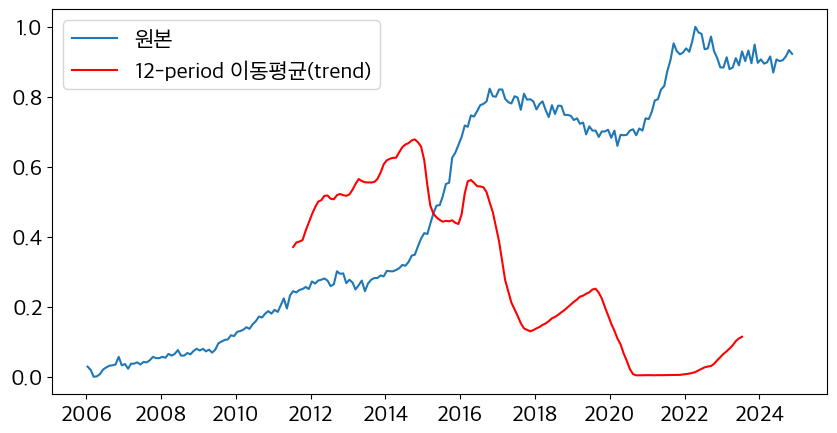

In [ ]:
# df_norm["유료관광지 방문객수 (외국인)"]
# window 길이(예: 월별 데이터라면 12 → 1년치 이동평균)
window = 12

# 중앙정렬(center=True) 옵션을 주면 과거·미래를 반씩 반영
trend_ma = df_norm["유료관광지 방문객수 (외국인)"].rolling(window=12, center=True).mean()

# 시각화

plt.figure(figsize=(10,5))
plt.plot(pd.to_datetime(df.index, format='mixed'),  df_norm["Jeju_HPI"], label="원본")
plt.plot(pd.to_datetime(df.index, format='mixed'), trend_ma, color="red",   label=f"{window}-period 이동평균(trend)")
plt.legend()
plt.show()


In [78]:
# df = pd.read_excel('./data/제주도_관광지_방문객_수.xlsx', engine='openpyxl') 
# df=df.drop(df.columns[0:2], axis = 1).reset_index(drop=True)
# df = pd.read_excel('./data/제주도_여행형태별_방문객.xlsx', engine='openpyxl')
df = pd.read_excel('./data/제주도_외국인.xlsx', engine='openpyxl') 
# df = pd.read_excel('./data/제주도_외국인_방문객수.xlsx', engine='openpyxl') 
# df = pd.read_excel('./data/제주도_인구이동.xlsx', engine='openpyxl') 
# df = pd.read_excel('./data/제주도_주민등록_전입지별_인구이동.xlsx', engine='openpyxl') 
# df = pd.read_excel('./data/제주도_항공노선별_수송_대한항공.xlsx', engine='openpyxl') 
# df = df.drop(df.columns[0:3], axis = 1).reset_index(drop=True)
# df = df.drop(df.columns[0], axis = 1).reset_index(drop=True)
# # 전국
# # 수도권
# # 지방
# value = df.iloc[3].values
# value = np.insert(value,0,[np.nan]*(12*(2006-2004)))
# val = pd.to_numeric(np.char.replace(value.astype(str), ',', ''), errors='coerce')
# pd.DataFrame(val).T.to_csv("./data/merge_data_V5.csv", mode='a', header=False, index=False)

/Users/yeojisu/opt/anaconda3/envs/cv2024/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [79]:
df

,주요국적별,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,주요국적별,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계
1,주요국적별,계,계,계,계,계,계,계,계,계,계,계,계,계
2,총계,7128,8736,10864,14204,16960,19593,21689,24841,25668,22943,20717,21592,25456
3,중국,2197,2560,3691,5709,7343,9001,9955,10968,10844,9258,7603,6881,8816
4,한국계중국인,545,564,716,1083,1269,1409,1467,1625,1656,1470,1298,1242,1350
5,베트남,1254,1716,1908,1983,2137,2303,2637,3364,3680,3459,3476,3662,4111
6,인도네시아,671,845,1047,1327,1364,1304,1409,1626,1843,1827,1732,2388,3194
7,필리핀,350,416,480,524,583,589,608,657,644,563,516,592,679
8,미국,327,366,383,401,435,457,531,607,679,692,731,723,704
9,일본,172,188,194,216,239,247,250,266,272,252,273,304,285


In [73]:
value = np.insert(df.iloc[2:3].values,0,[np.nan]*(2011-2004)*12)
value = pd.to_numeric(np.char.replace(value.astype(str), ',', ''), errors='coerce')
pd.DataFrame(value).T.to_csv("./data/jeju.csv", mode='a', header=False, index=False)

In [ ]:
df.iloc[7:8].T.to_csv("") (2011-2004)

,7
2011.01,23714
2011.02,33519
2011.03,46819
2011.04,69257
2011.05,79044
...,...
2023.08,84065
2023.09,82727
2023.10,85530
2023.11,73296


In [2]:
# CSV 파일 경로
file_path = './data/merge_data.csv'

# CSV 파일을 읽어서 데이터프레임으로 저장
df = pd.read_csv(file_path)

In [3]:
df

,Date,2004-01-15,2004-02-15,2004-03-15,2004-04-15,2004-05-15,2004-06-15,2004-07-15,2004-08-15,2004-09-15,...,2024-01-15,2024-02-15,2024-03-15,2024-04-15,2024-05-15,2024-06-15,2024-07-15,2024-08-15,2024-09-15,2024-10-15
0,콜금리,3.780000e+00,3.750000e+00,3.750000e+00,3.750000e+00,3.760000e+00,3.760000e+00,3.760000e+00,3.600000e+00,3.520000e+00,...,3.470000e+00,3.580000e+00,3.470000e+00,3.520000e+00,3.530000e+00,3.550000e+00,3.52,3.53,3.53,NaN
1,국고채 3년,4.880000e+00,4.830000e+00,4.580000e+00,4.540000e+00,4.390000e+00,4.280000e+00,4.190000e+00,3.820000e+00,3.590000e+00,...,3.270000e+00,3.350000e+00,3.310000e+00,3.440000e+00,3.430000e+00,3.260000e+00,3.08,2.92,2.87,NaN
2,국고채 5년,5.160000e+00,5.130000e+00,4.880000e+00,4.880000e+00,4.750000e+00,4.580000e+00,4.470000e+00,4.010000e+00,3.750000e+00,...,3.300000e+00,3.390000e+00,3.340000e+00,3.500000e+00,3.470000e+00,3.280000e+00,3.11,2.95,2.92,NaN
3,국고채 10년,5.420000e+00,5.430000e+00,5.260000e+00,5.250000e+00,5.160000e+00,5.010000e+00,4.880000e+00,4.330000e+00,4.140000e+00,...,3.350000e+00,3.430000e+00,3.390000e+00,3.570000e+00,3.530000e+00,3.340000e+00,3.17,3.0,3.01,NaN
4,예금은행 대출금리 - 대출평균,6.250000e+00,6.090000e+00,6.120000e+00,6.020000e+00,5.970000e+00,6.060000e+00,5.960000e+00,5.810000e+00,5.740000e+00,...,5.040000e+00,4.850000e+00,4.850000e+00,4.770000e+00,4.780000e+00,4.710000e+00,4.55,4.48,4.62,NaN
5,예금은행 대출금리 - 기업대출,6.230000e+00,6.110000e+00,6.130000e+00,6.010000e+00,5.950000e+00,6.080000e+00,5.970000e+00,5.860000e+00,5.770000e+00,...,5.220000e+00,5.030000e+00,4.960000e+00,4.880000e+00,4.900000e+00,4.880000e+00,4.78,4.67,4.77,NaN
6,예금은행 대출금리 - 가계대출,6.340000e+00,6.080000e+00,6.110000e+00,6.070000e+00,6.020000e+00,6.000000e+00,5.920000e+00,5.690000e+00,5.660000e+00,...,4.680000e+00,4.490000e+00,4.500000e+00,4.480000e+00,4.490000e+00,4.260000e+00,4.06,4.08,4.23,NaN
7,M1 한국,2.959399e+02,2.994303e+02,3.023790e+02,3.041115e+02,3.049866e+02,3.064421e+02,3.068942e+02,3.084920e+02,3.107787e+02,...,1.221110e+03,1.217657e+03,1.244401e+03,1.234806e+03,1.221570e+03,1.220525e+03,1216.5762,1217.8122,NaN,NaN
8,M1 한국 증가율,6.000000e+00,7.500000e+00,8.300000e+00,9.900000e+00,9.400000e+00,9.300000e+00,1.020000e+01,8.400000e+00,7.500000e+00,...,4.000000e-01,2.400000e+00,4.300000e+00,4.000000e+00,3.400000e+00,3.500000e+00,2.5,2.8,NaN,NaN
9,M2 한국,9.000018e+02,9.071728e+02,9.134808e+02,9.158892e+02,9.234294e+02,9.250363e+02,9.306418e+02,9.402055e+02,9.485525e+02,...,3.924203e+03,3.929858e+03,3.996217e+03,4.013228e+03,4.014131e+03,4.037581e+03,4054.9674,4062.6163,NaN,NaN


In [51]:
df.columns

Index(['Date', '2004-01-15', '2004-02-15', '2004-03-15', '2004-04-15',
       '2004-05-15', '2004-06-15', '2004-07-15', '2004-08-15', '2004-09-15',
       ...
       '2025-03-15', '2025-04-15', '2025-05-15', '2025-06-15', '2025-07-15',
       '2025-08-15', '2025-09-15', '2025-10-15', '2025-11-15', '2025-12-15'],
      dtype='object', length=265)

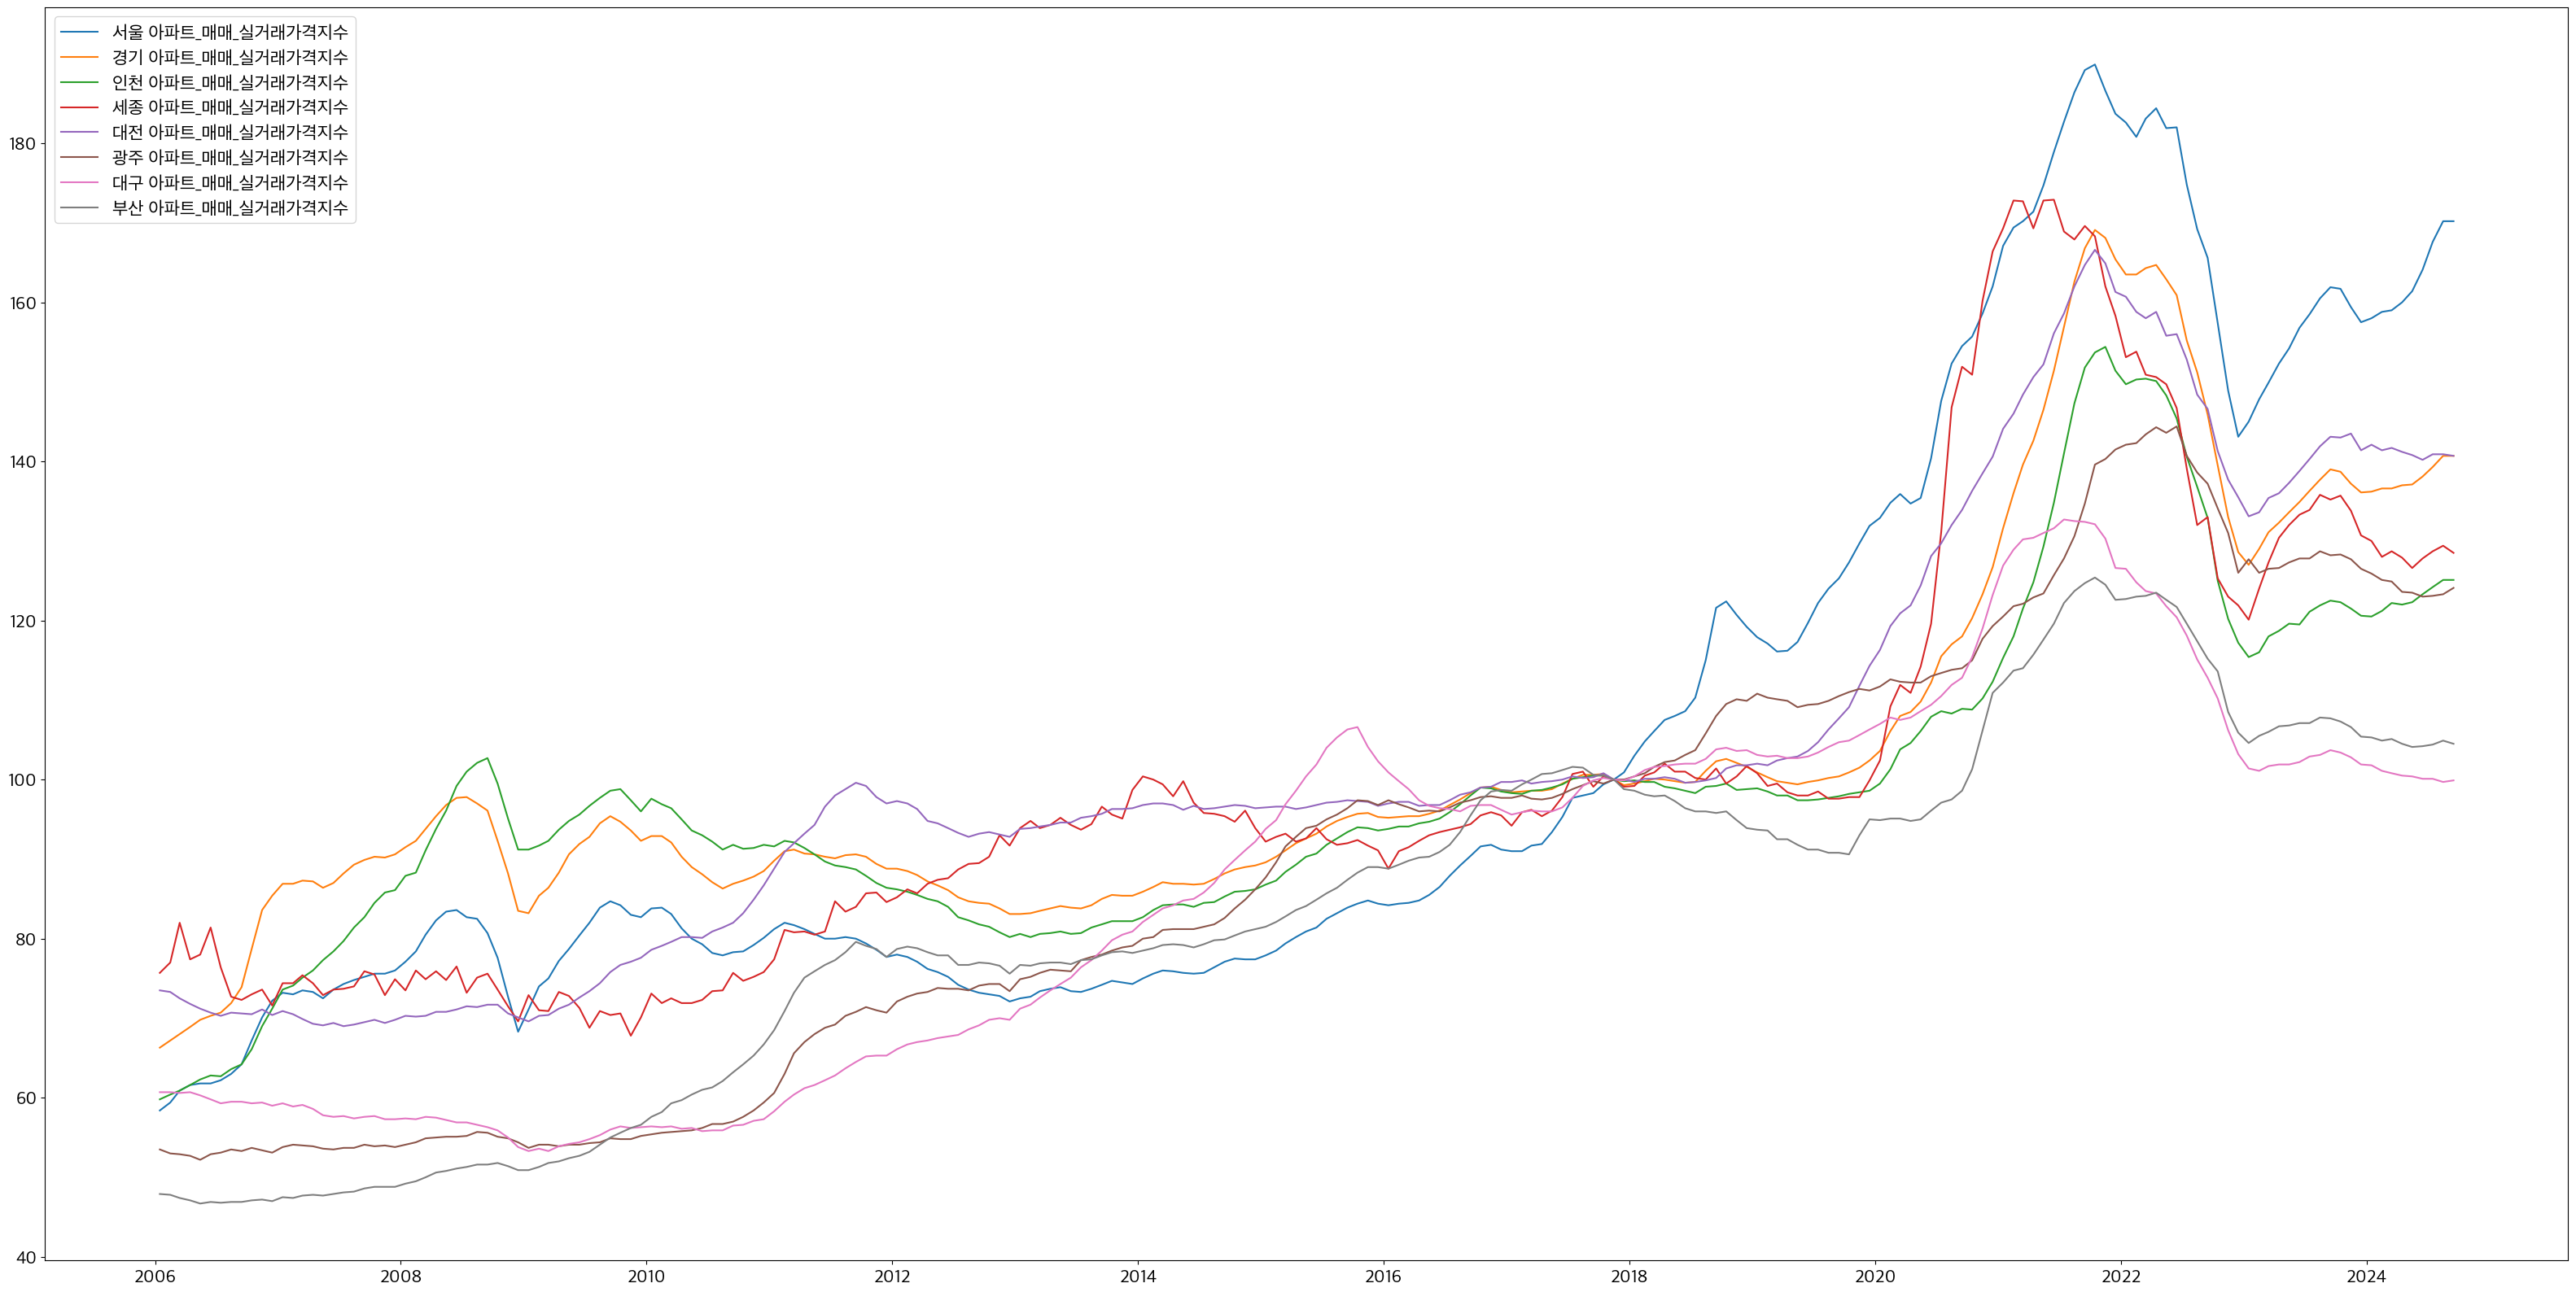

In [59]:
# CSV 파일 경로
file_path = './data/nationwide.csv'

# CSV 파일을 읽어서 데이터프레임으로 저장
df = pd.read_csv(file_path)

plt.figure(figsize=(40,20))
for i in [0,8,3,7,5,4,2,1]:#range(0,16):
    x = df.loc[102+i].values[1:]
    label = df.loc[102+i].values[0]
    plt.plot(pd.to_datetime(df.columns[1:], format='mixed'),x,label=label)
plt.legend()
plt.show()


In [37]:
df_2 = pd.read_csv("./data/merge_data_V4.csv")

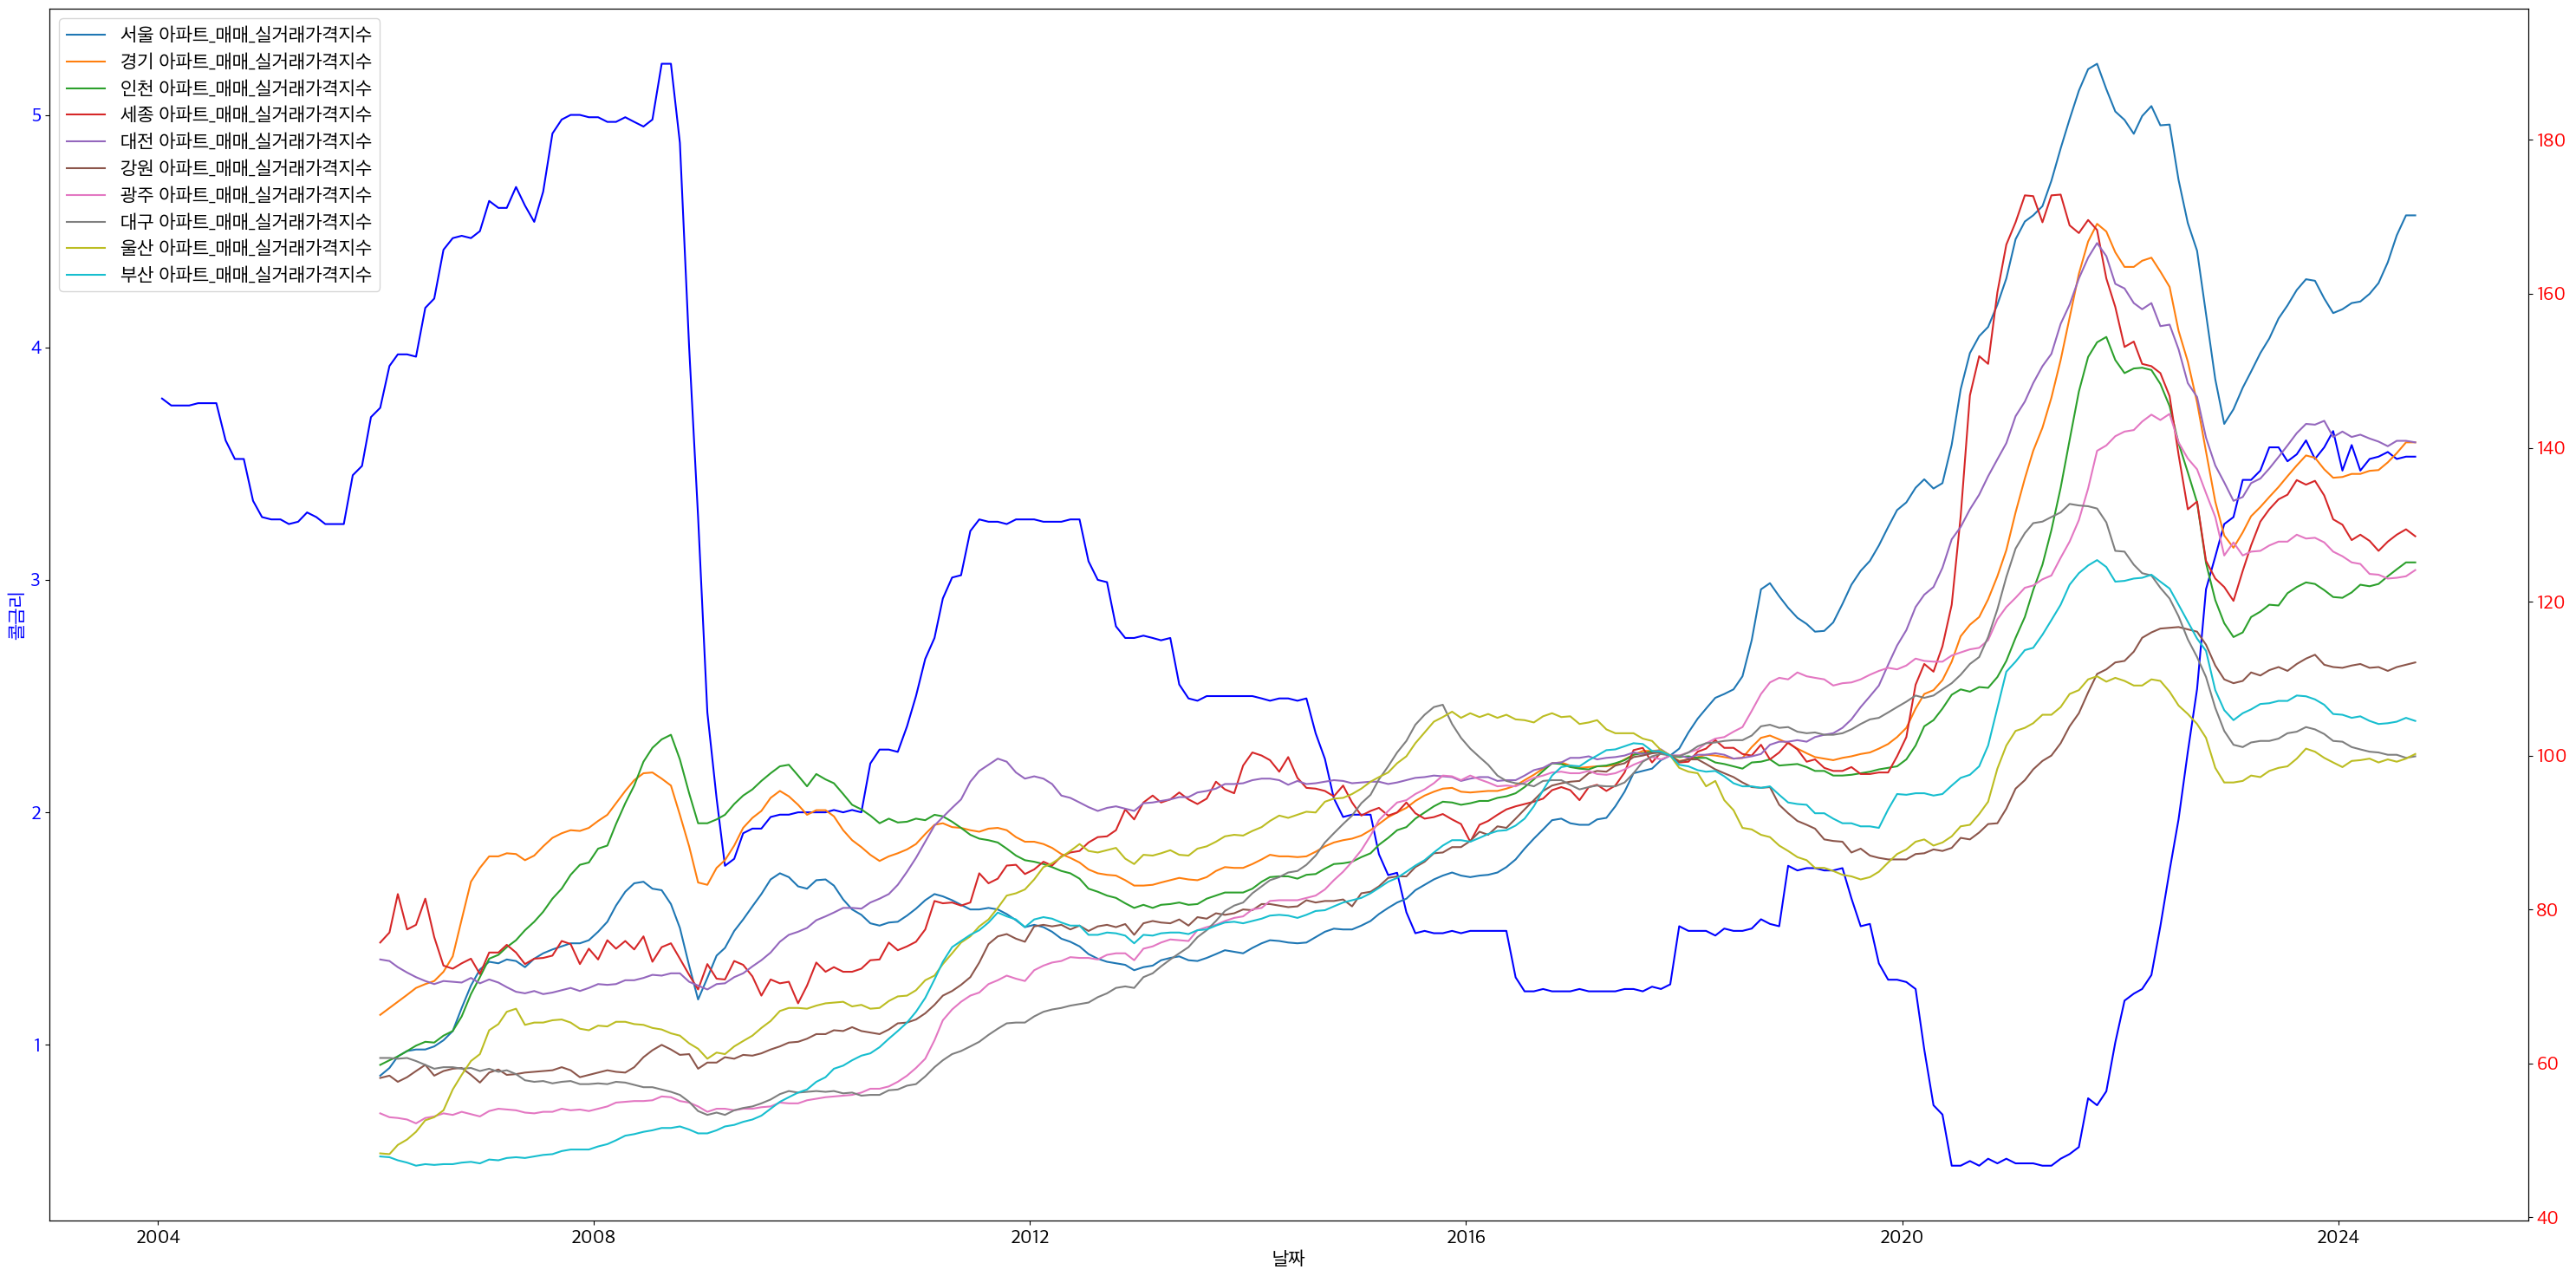

In [50]:
value_x = df_2.loc[0].values[1:]
label_x = df_2.loc[0].values[0]

k = 1
fig, ax1 = plt.subplots(figsize=(30, 15))
# 첫 번째 축 (왼쪽 y축)
ax1.plot(pd.to_datetime(df_2.columns[k:], format='mixed'), pd.to_numeric(np.char.replace(value_x.astype(str), ',', ''), errors='coerce'), color='b', label=label_x)
ax1.set_xlabel('날짜')
ax1.set_ylabel(label_x, color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()  # 두 번째 축 생성
for i in [0,8,3,7,5,9,4,2,6,1]:
    value_y = df.loc[102+i].values[1:]
    label_y = df.loc[102+i].values[0]
    
    # 두 번째 축 (오른쪽 y축)
    ax2.plot(pd.to_datetime(df.columns[k:], format='mixed'), pd.to_numeric(np.char.replace(value_y.astype(str), ',', ''), errors='coerce'), label=label_y)
    # ax2.set_ylabel(label_y, color='r')
    ax2.tick_params(axis='y', labelcolor='r')

# 그래프 타이틀 및 설정
plt.legend()
# plt.title(label_x+" --- "+label_y)
fig.tight_layout()  # 그래프 요소들 간의 레이아웃 조정
plt.show()

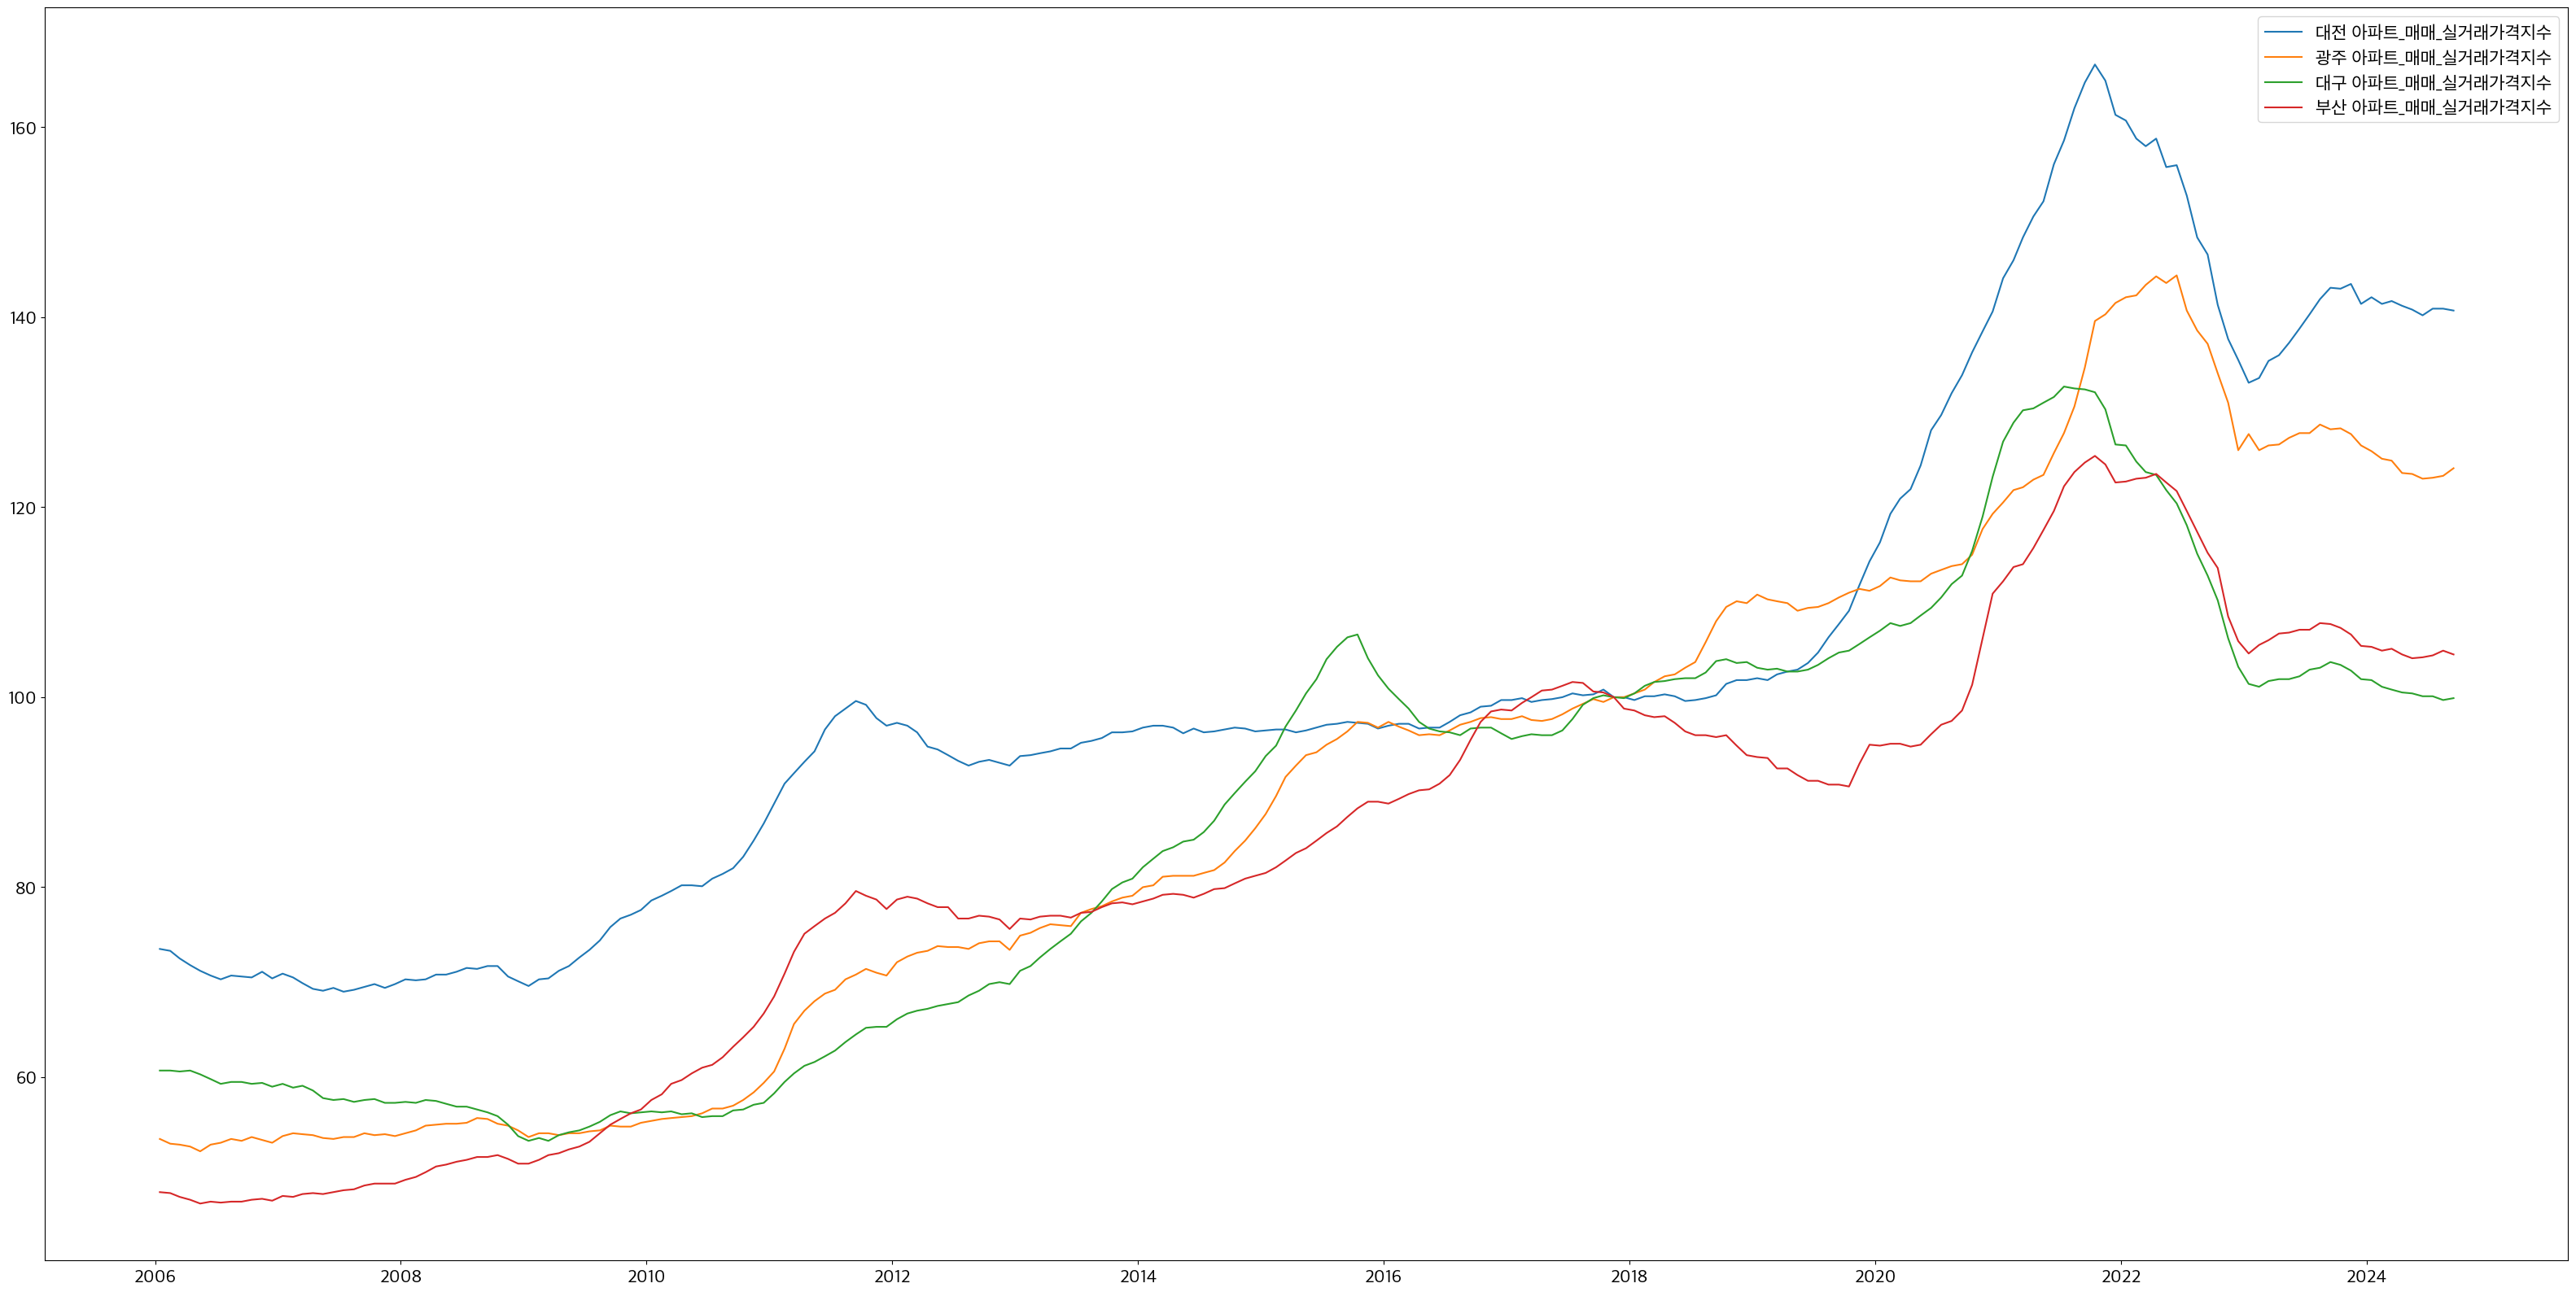

In [53]:
plt.figure(figsize=(40,20))
for i in [5,4,2,1]:# 8,3,
    x = df.loc[102+i].values[1:]
    label = df.loc[102+i].values[0]
    plt.plot(pd.to_datetime(df.columns[1:], format='mixed'),x,label=label)
plt.legend()
plt.show()

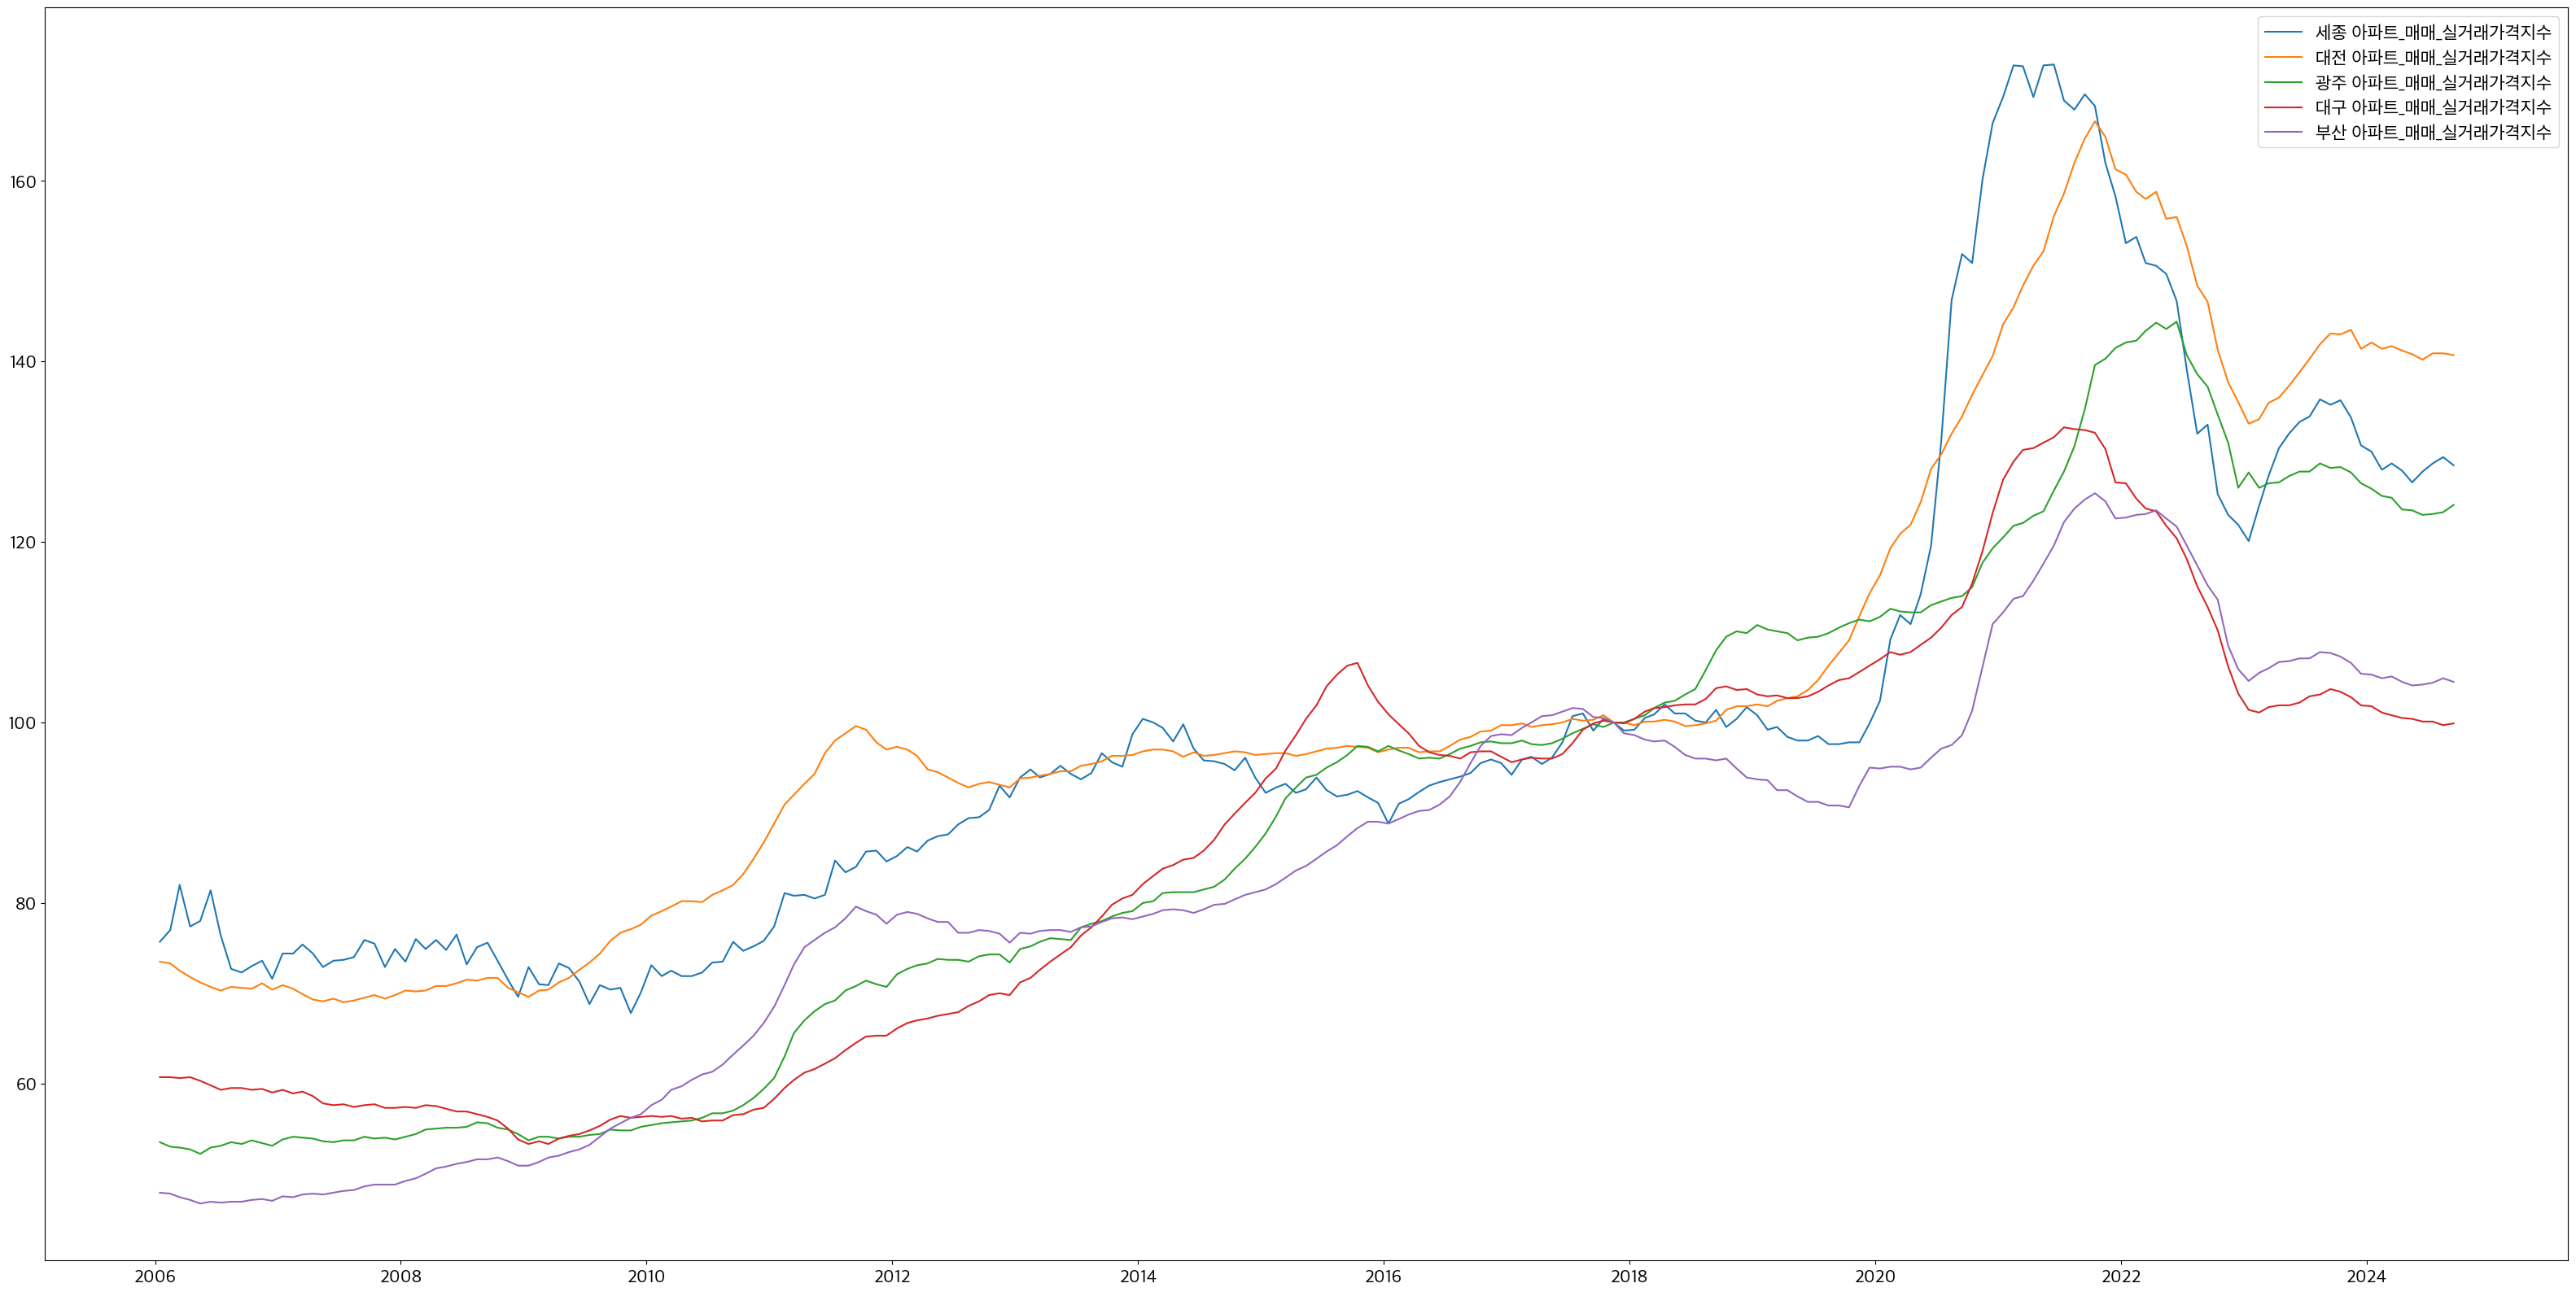

In [55]:
plt.figure(figsize=(40,20))
for i in [7,5,4,2,1]:# 8,3,
    x = df.loc[102+i].values[1:]
    label = df.loc[102+i].values[0]
    plt.plot(pd.to_datetime(df.columns[1:], format='mixed'),x,label=label)
plt.legend()
plt.show()

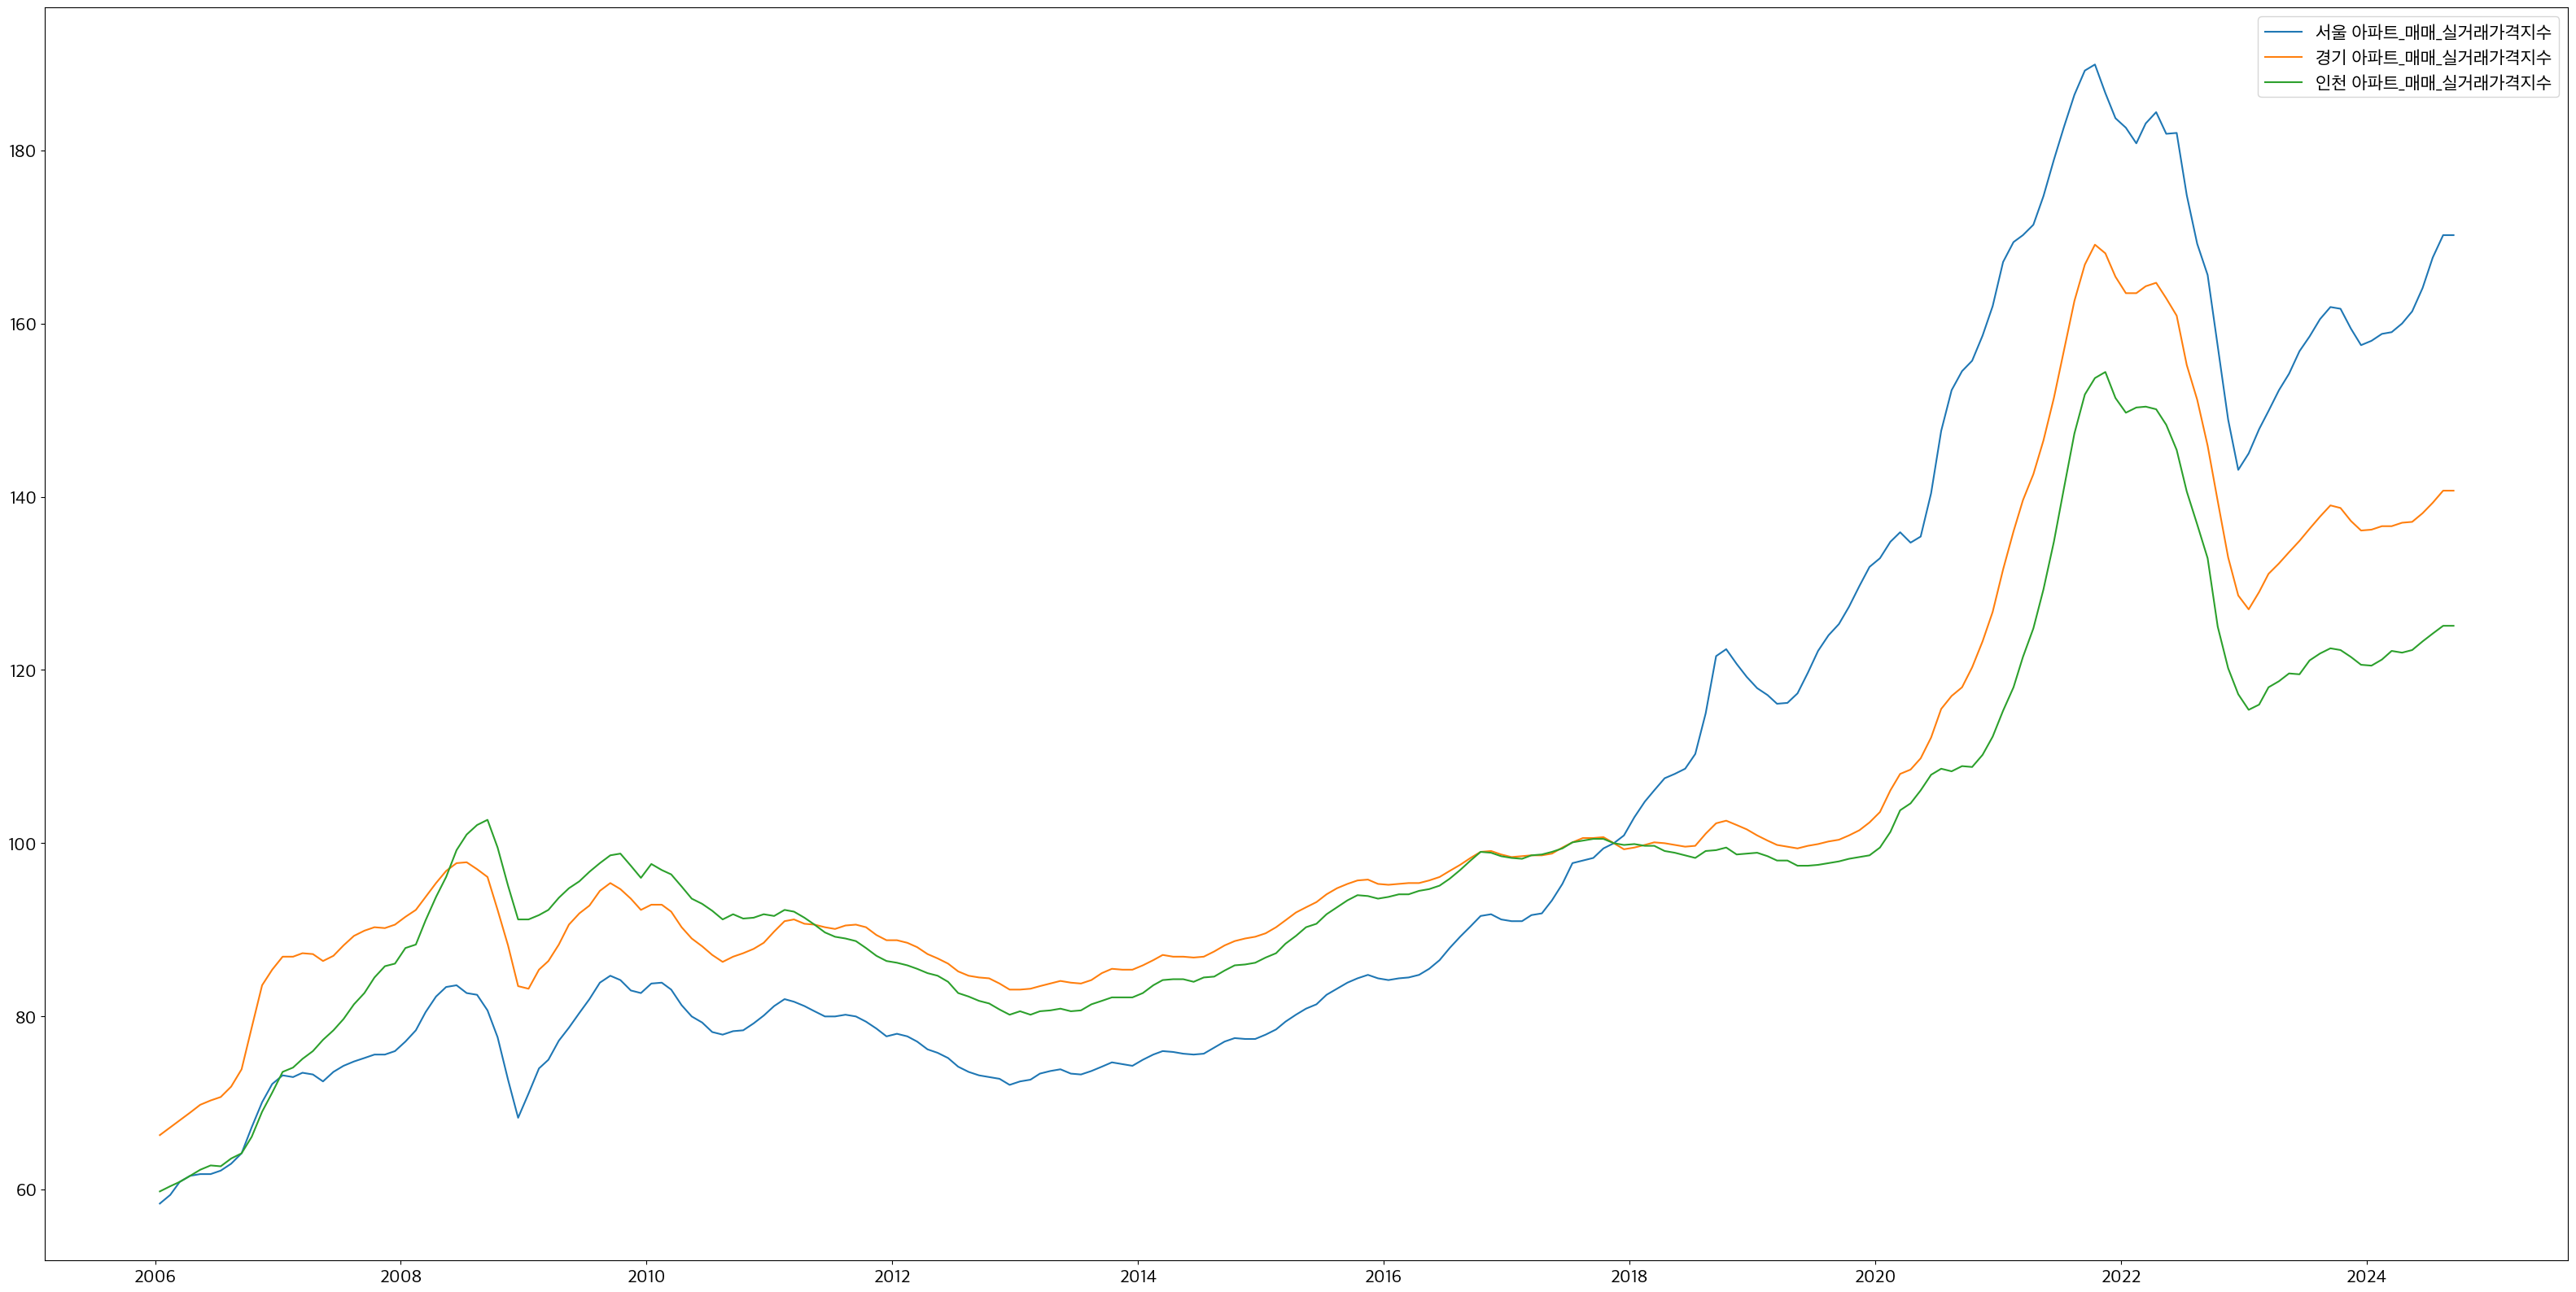

In [ ]:
plt.figure(figsize=(40,20))
for i in [0,8,3]:# 0,8,3,7,5,4,2,1
    x = df.loc[102+i].values[1:]
    label = df.loc[102+i].values[0]
    plt.plot(pd.to_datetime(df.columns[1:], format='mixed'),x,label=label)
plt.legend()
plt.show()

### 서울 아파트 매매가격지수

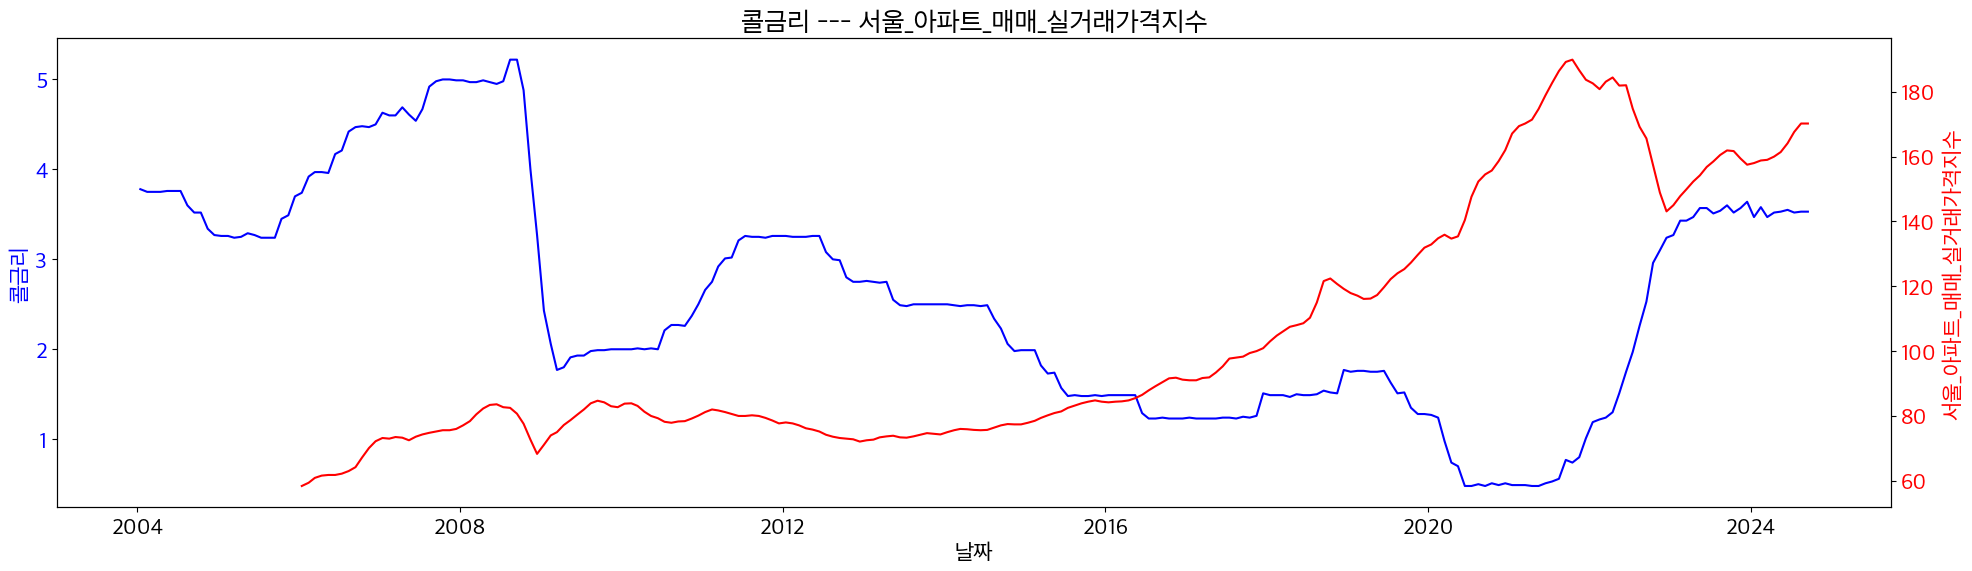

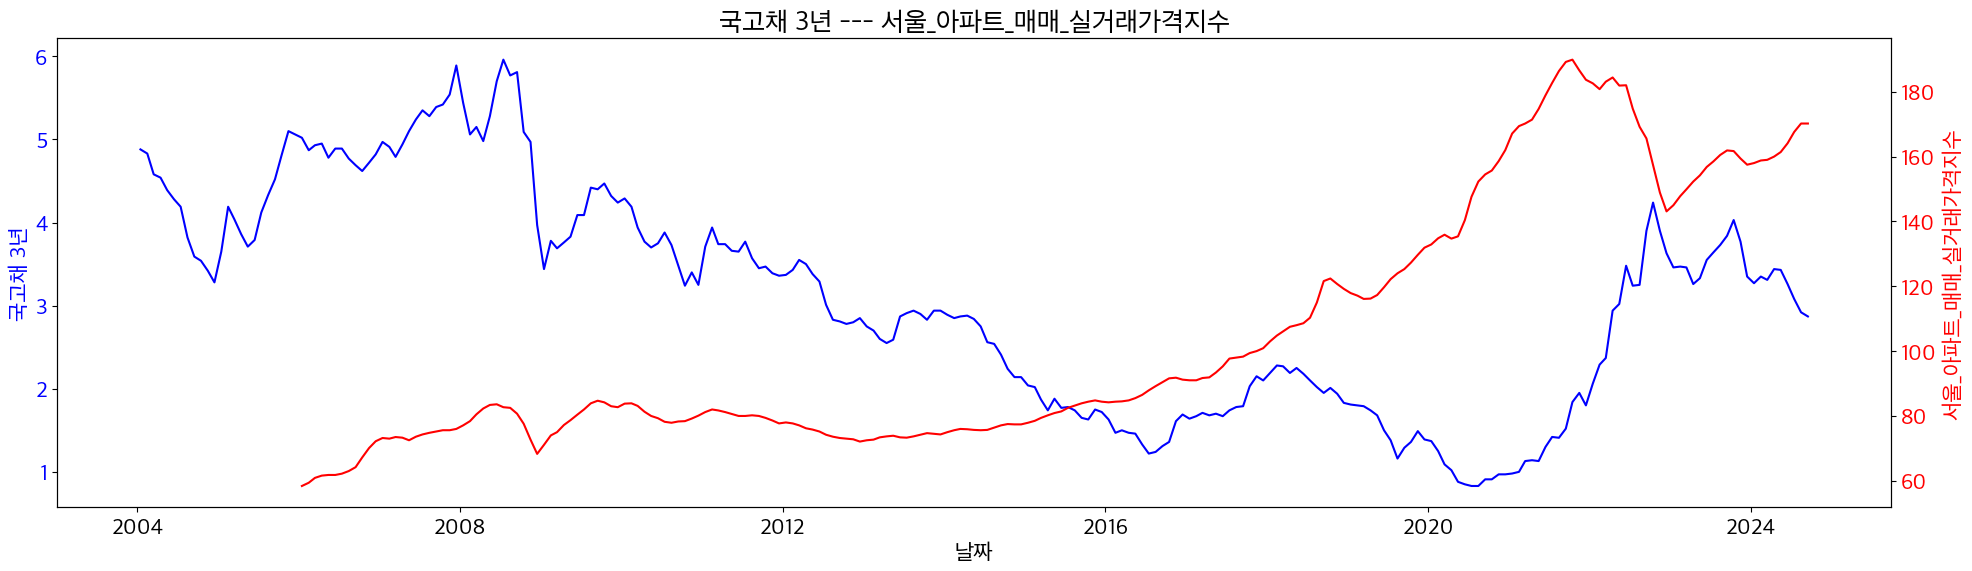

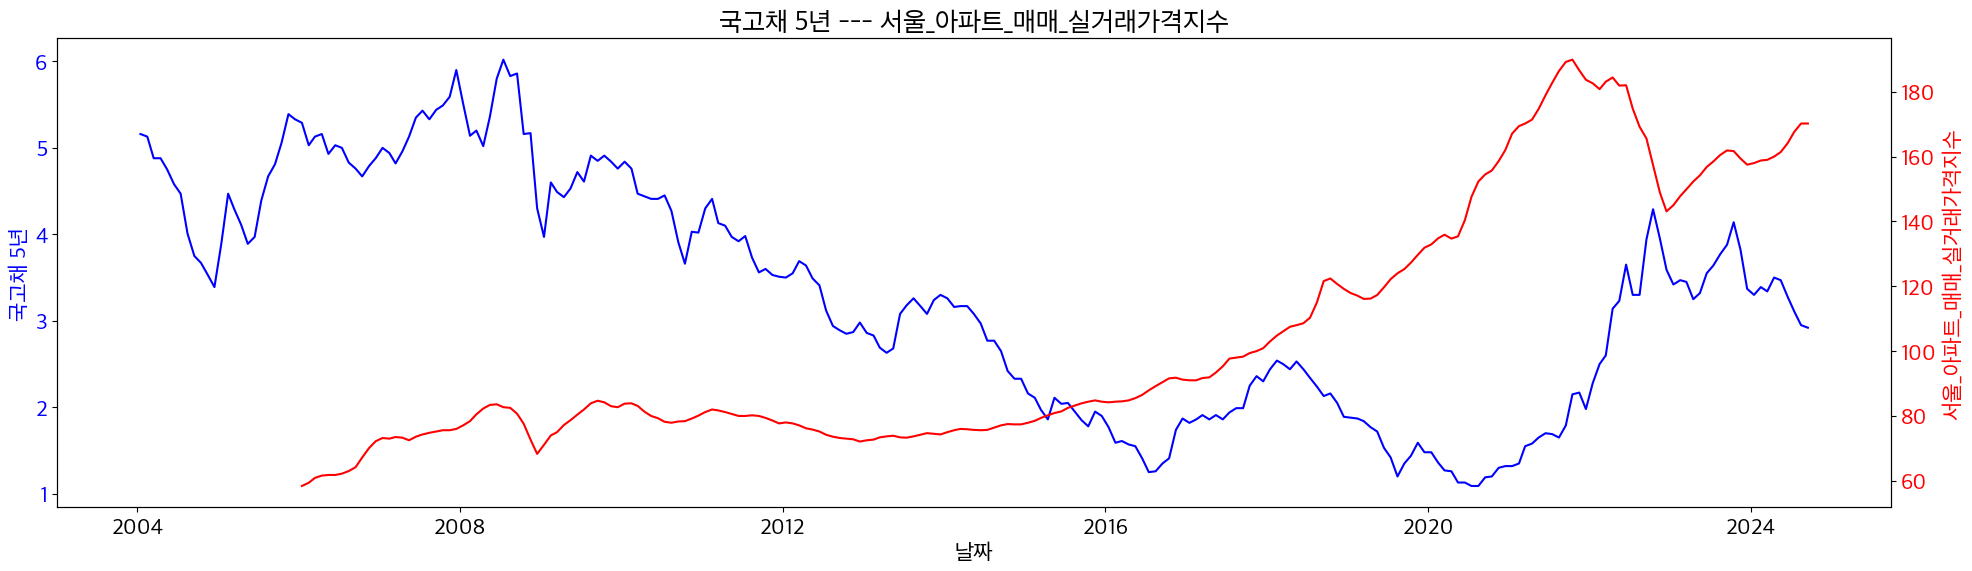

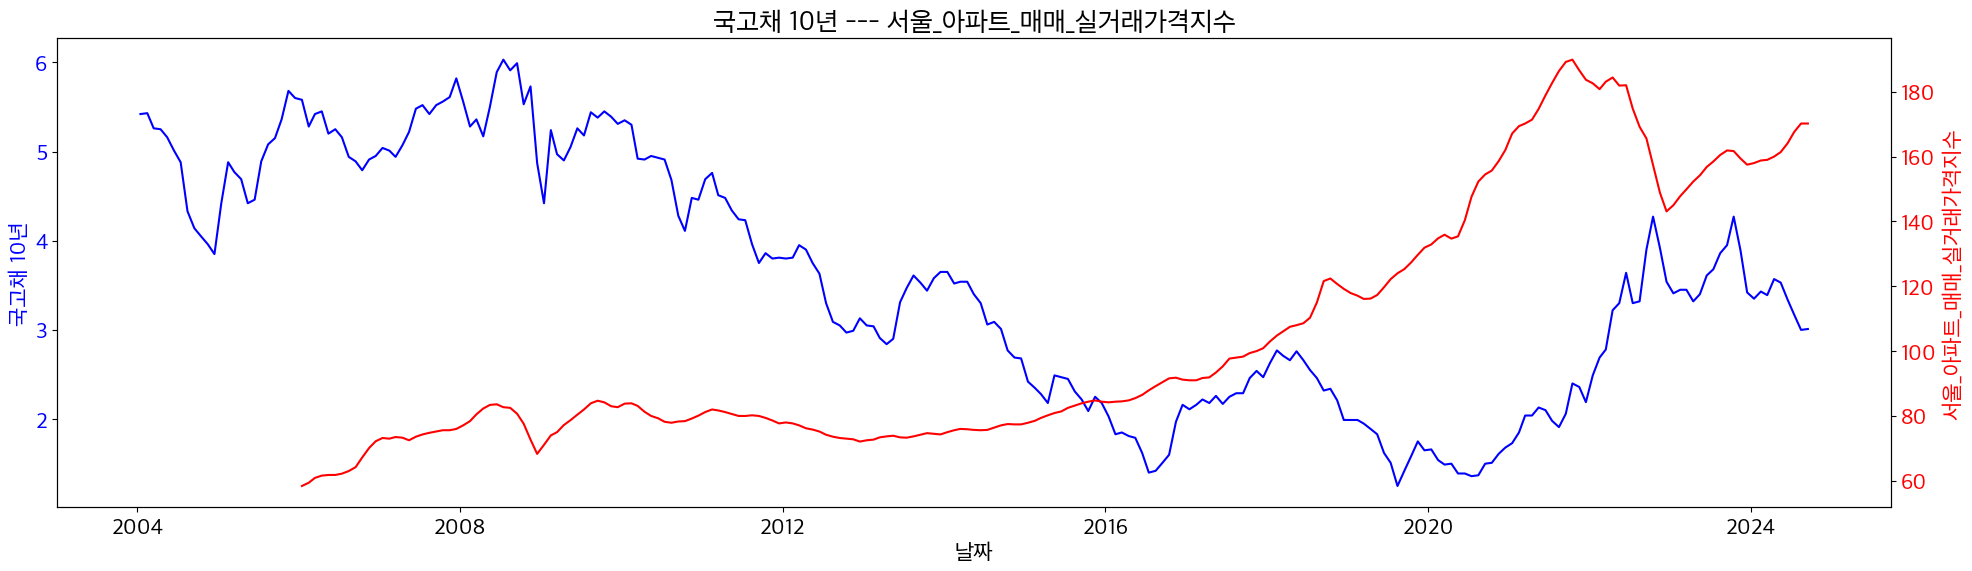

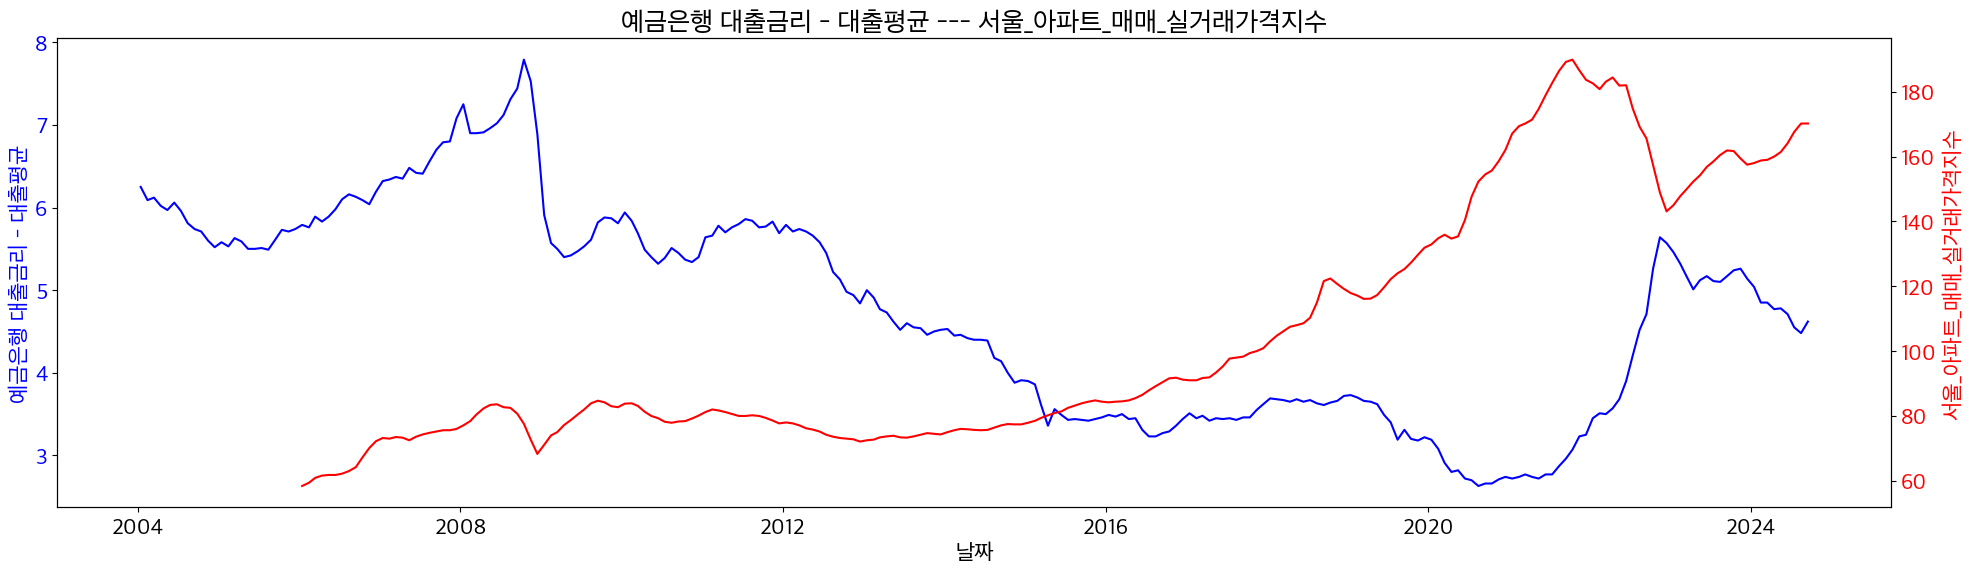

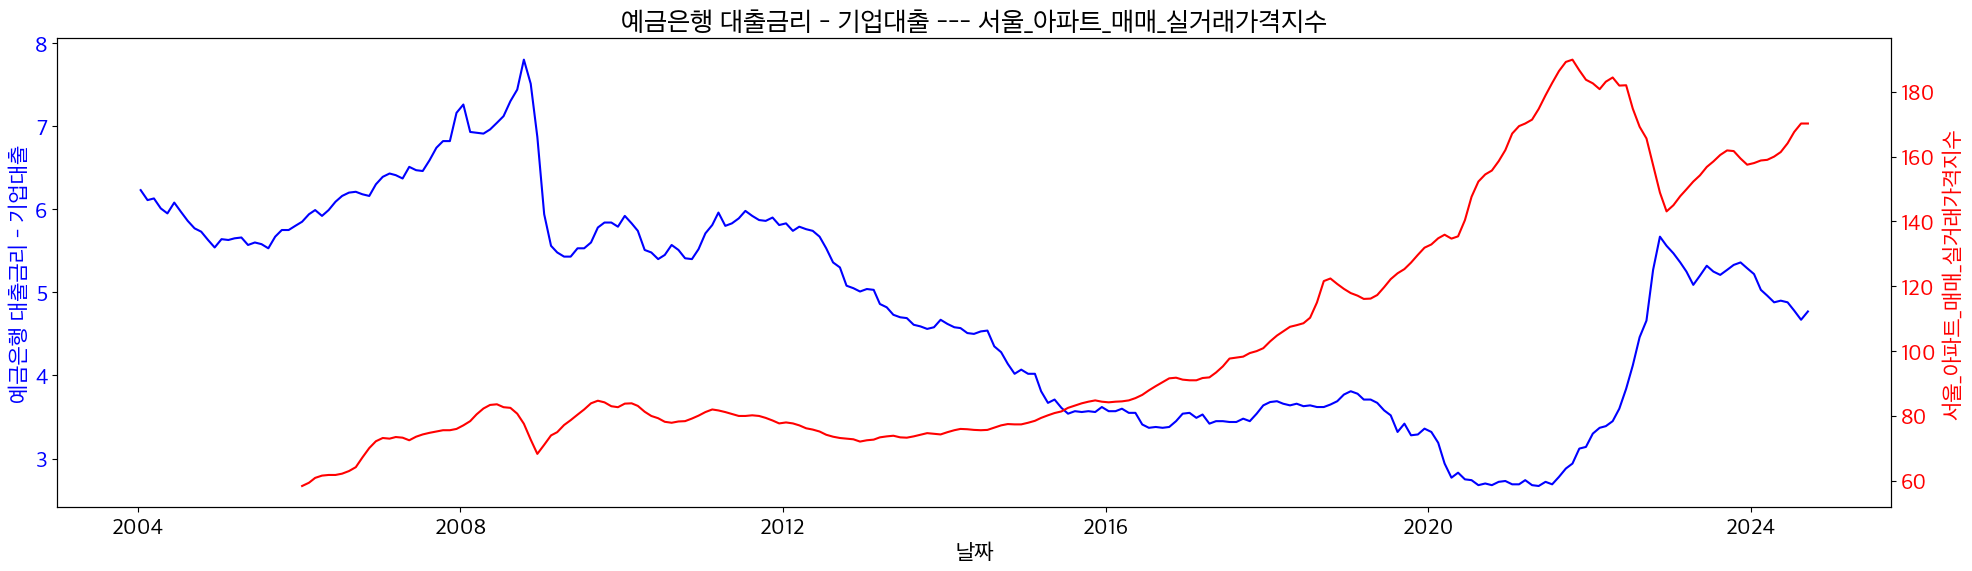

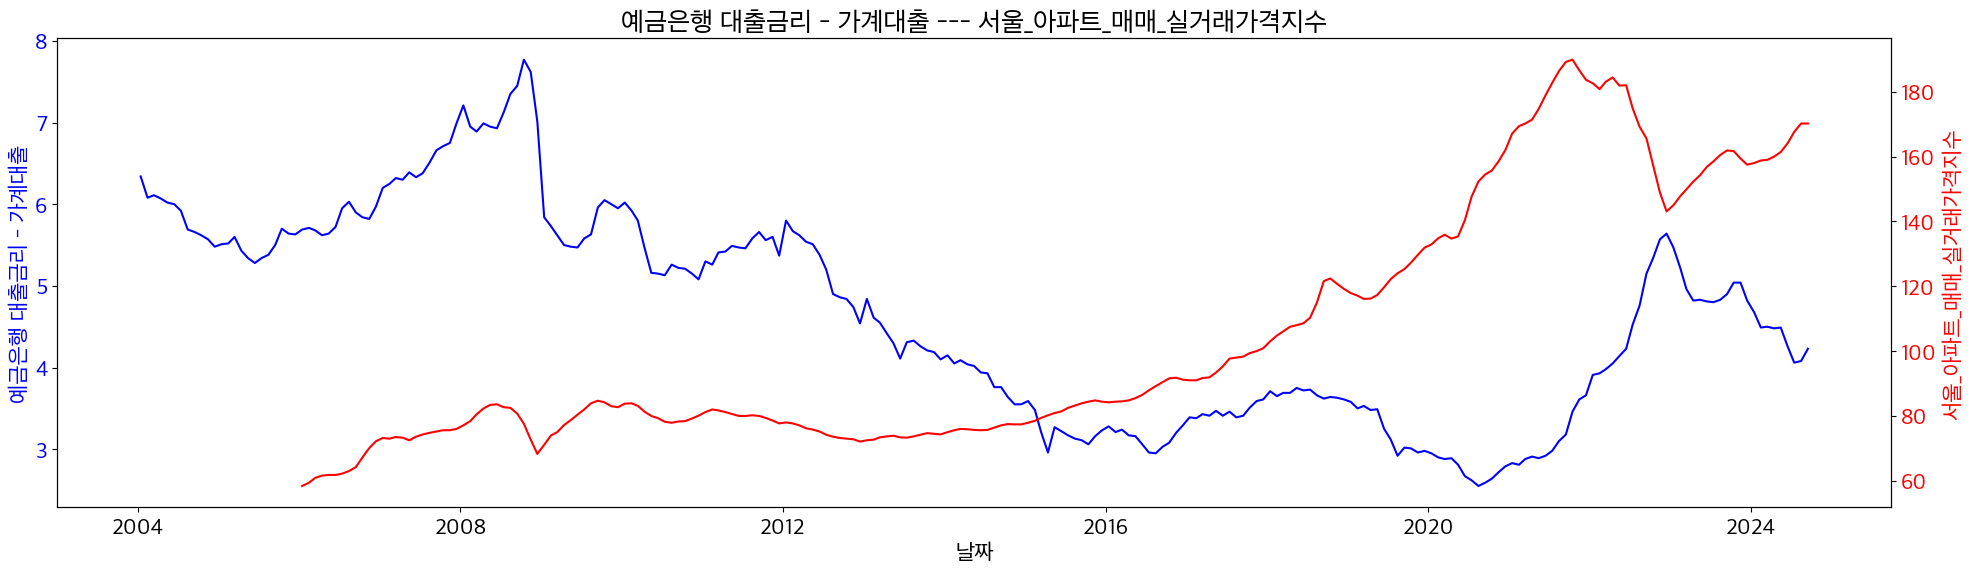

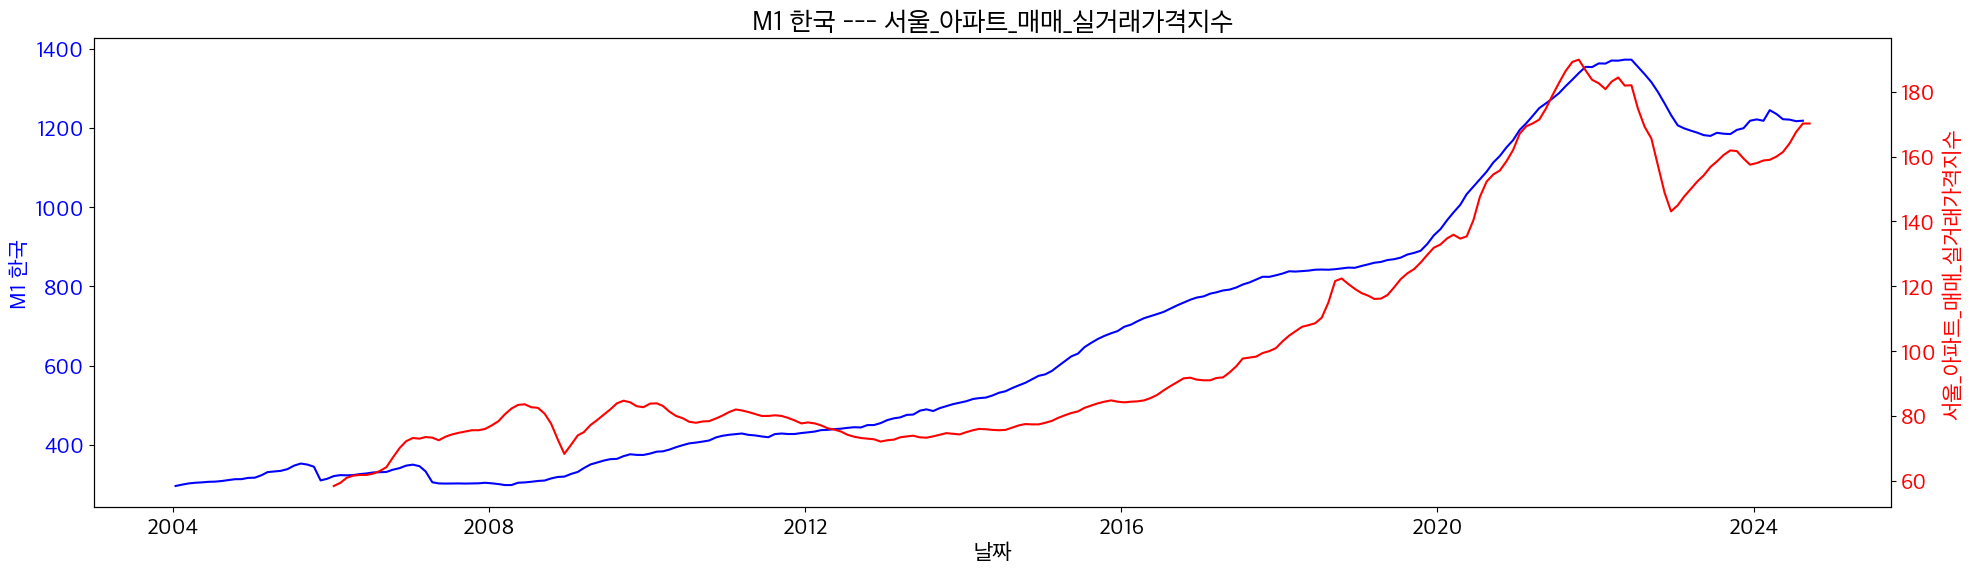

/var/folders/pc/0_qqcqxd1fncd71rzs72fhr00000gn/T/ipykernel_20472/526132485.py:25: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.tight_layout()  # 그래프 요소들 간의 레이아웃 조정
/Users/yeojisu/opt/anaconda3/envs/cv2024/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


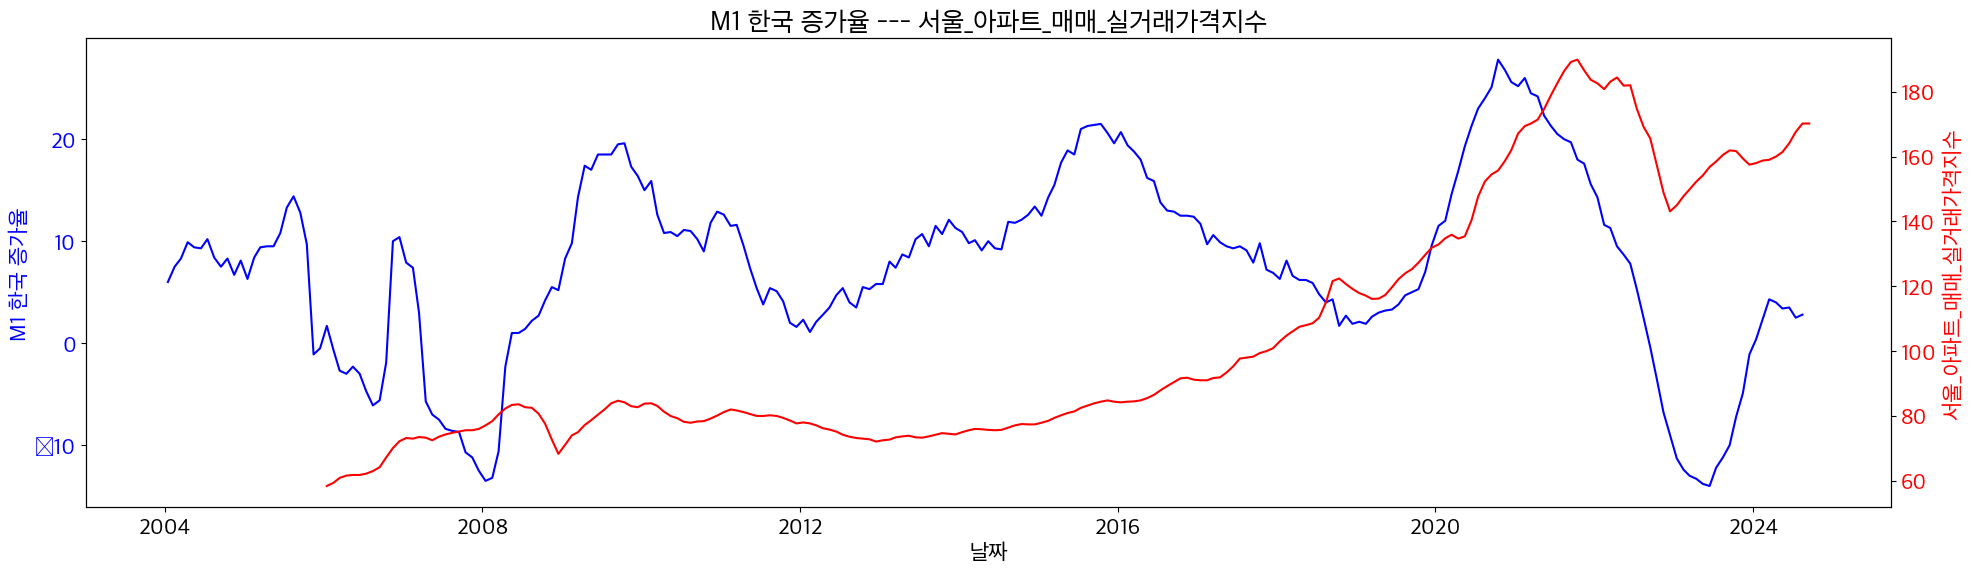

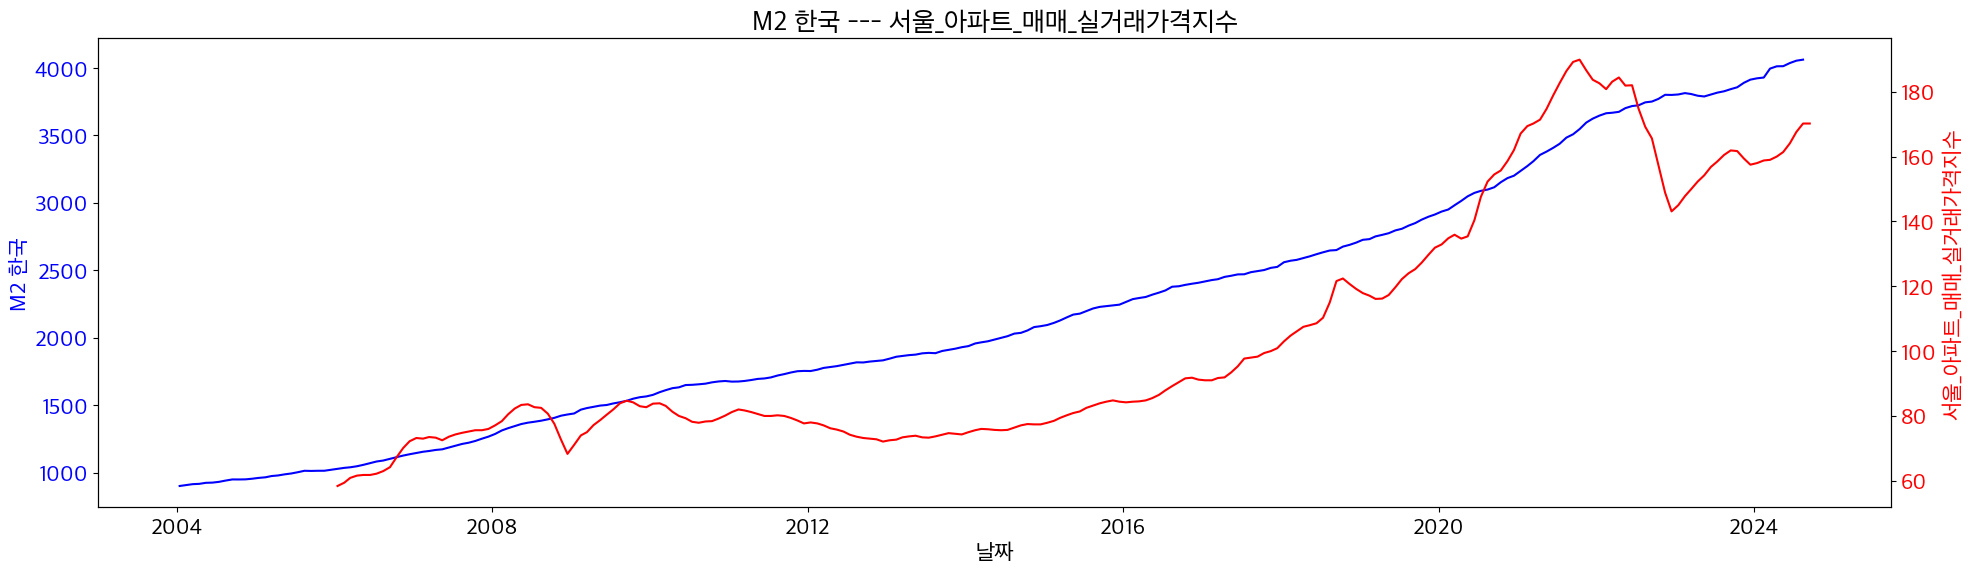

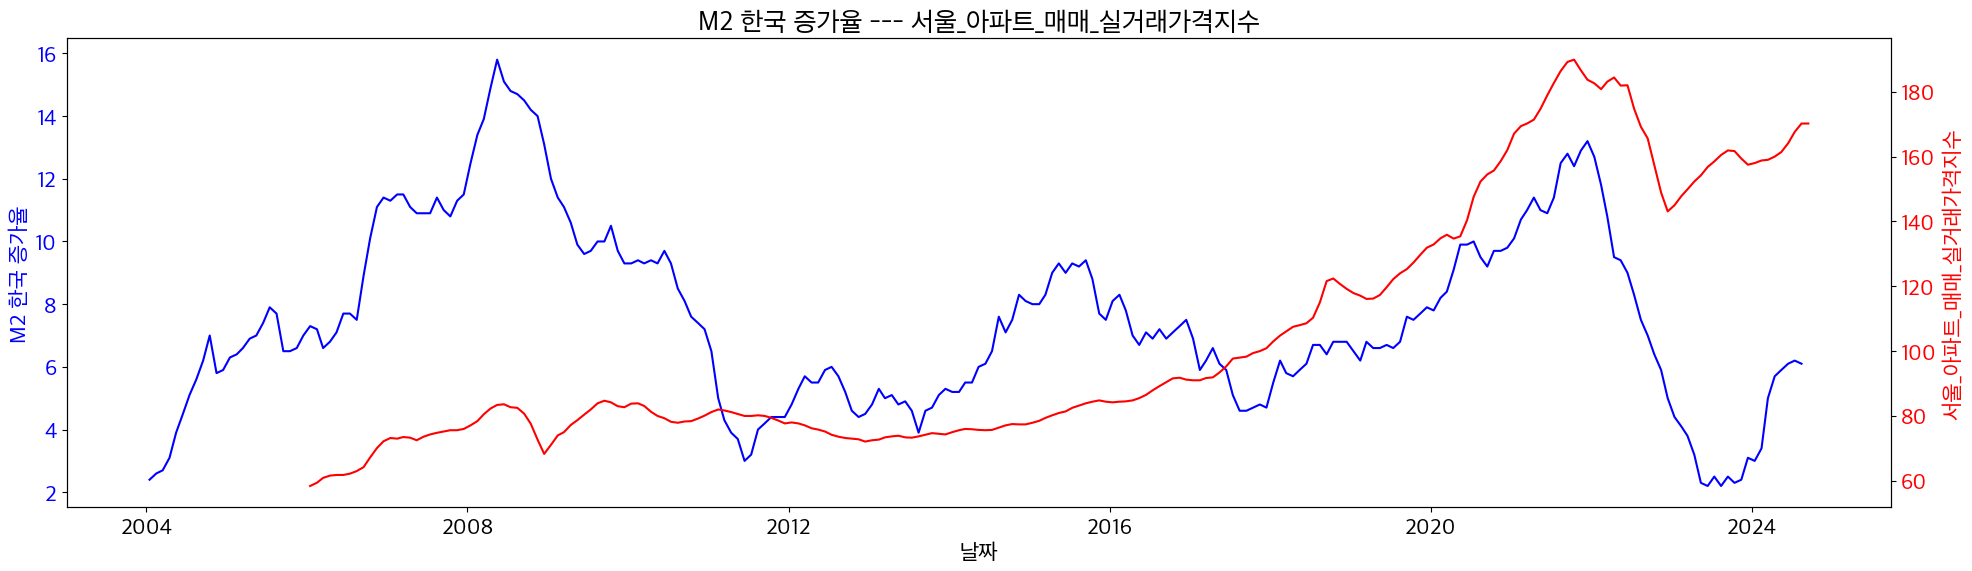

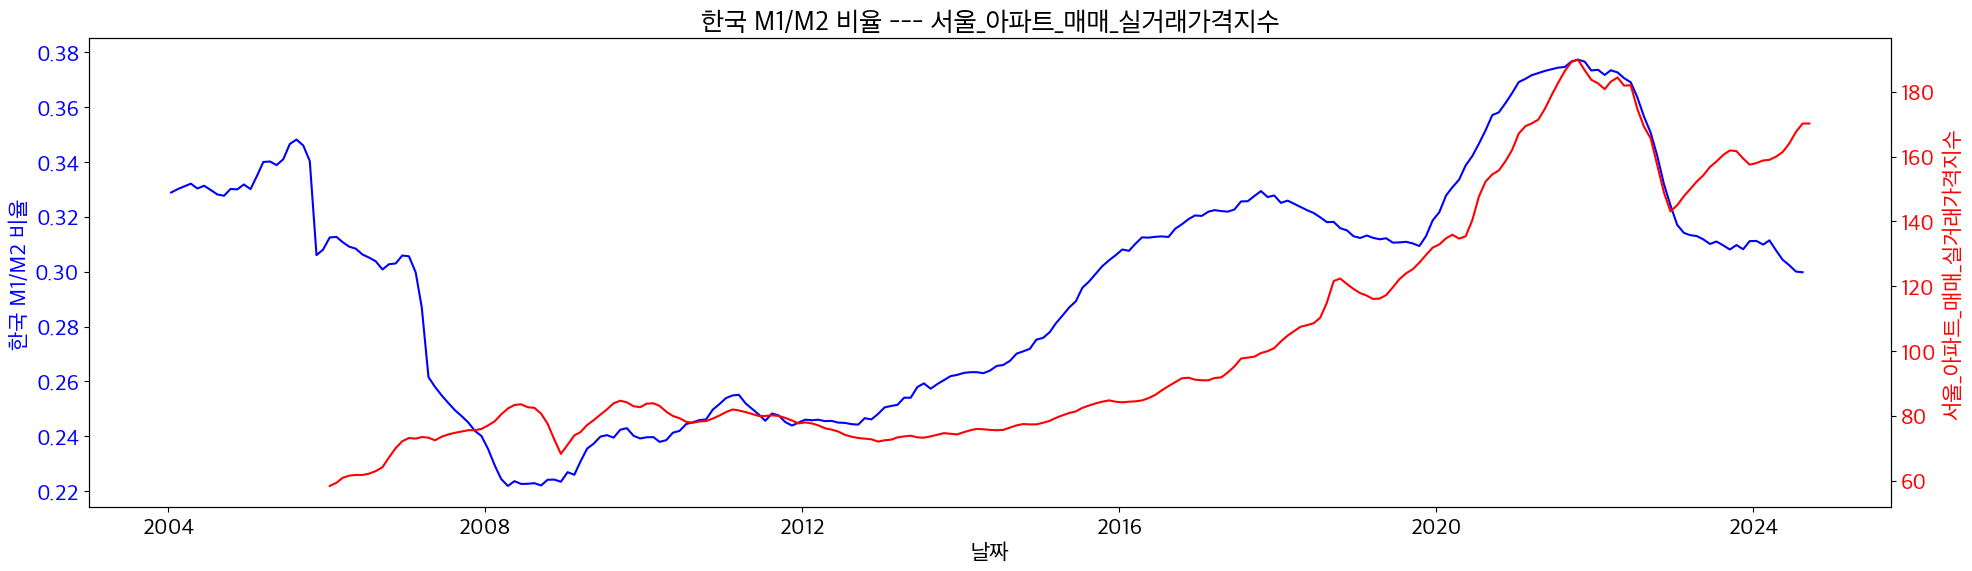

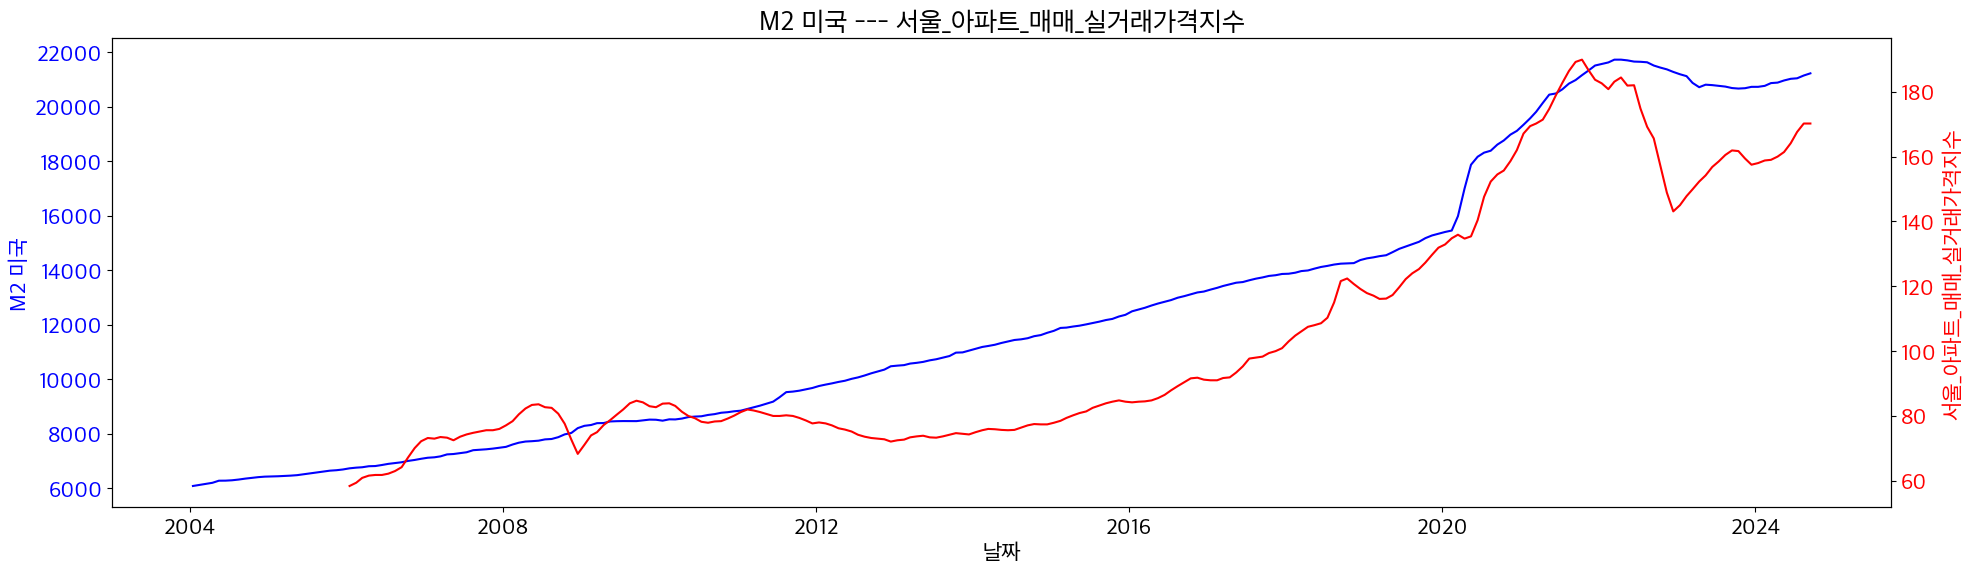

/var/folders/pc/0_qqcqxd1fncd71rzs72fhr00000gn/T/ipykernel_20472/526132485.py:25: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.tight_layout()  # 그래프 요소들 간의 레이아웃 조정
/Users/yeojisu/opt/anaconda3/envs/cv2024/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


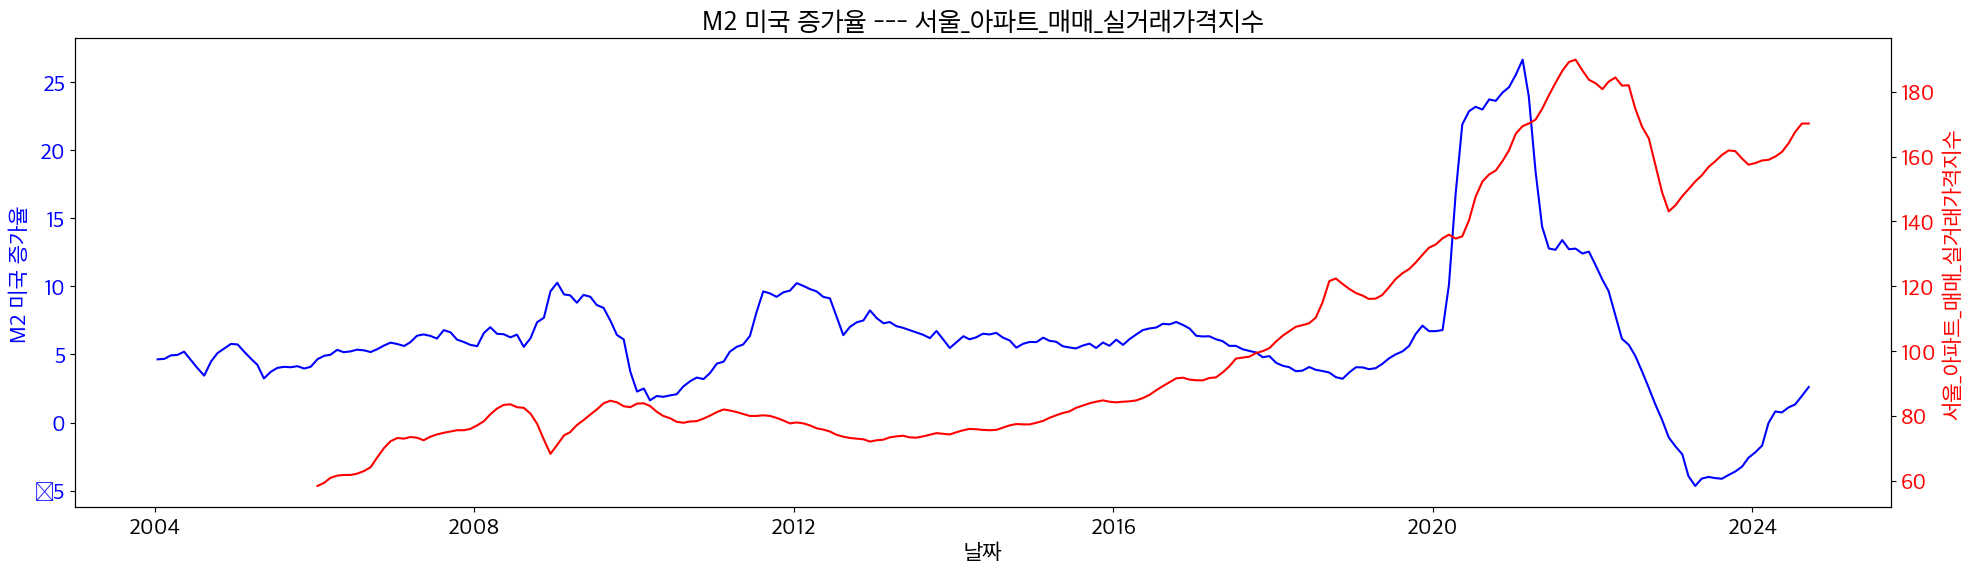

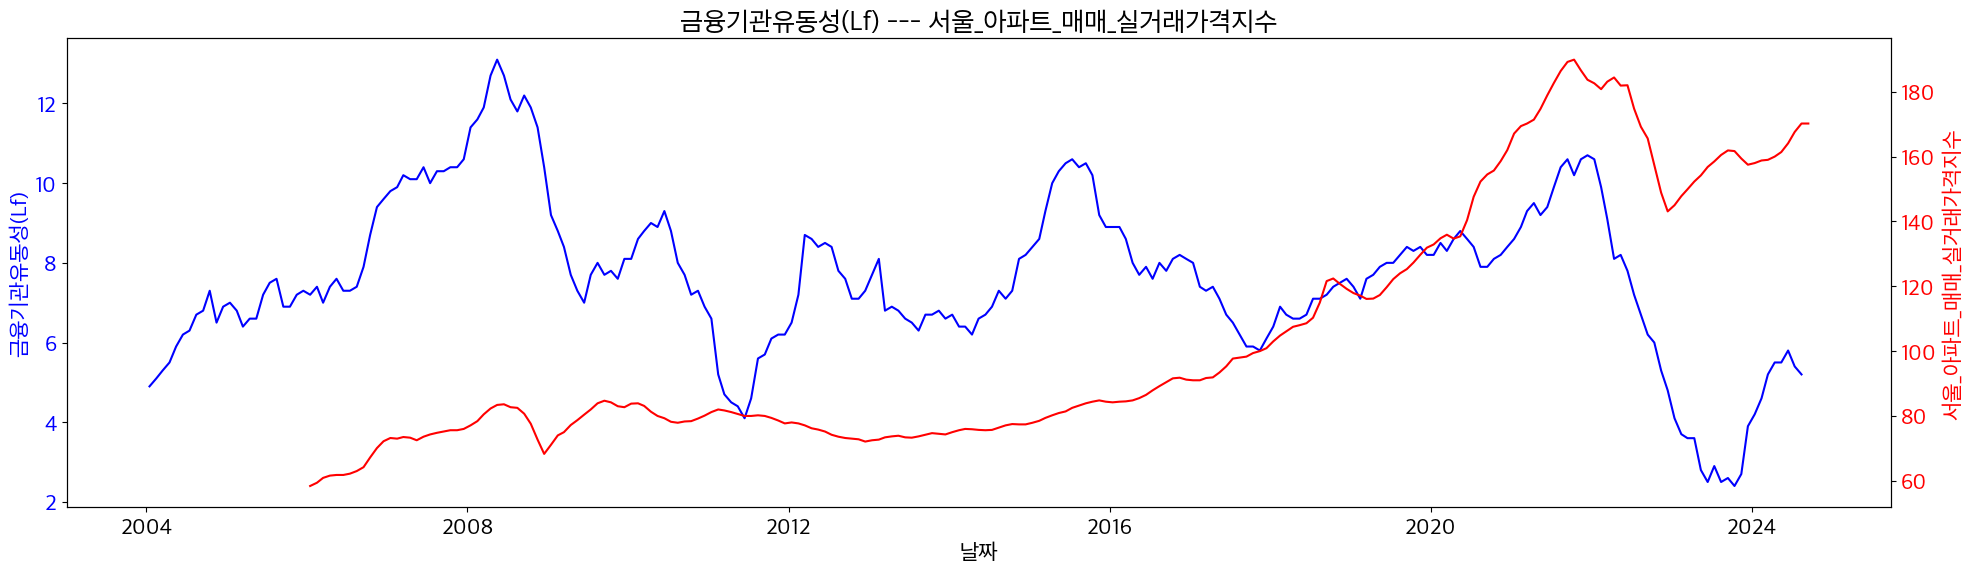

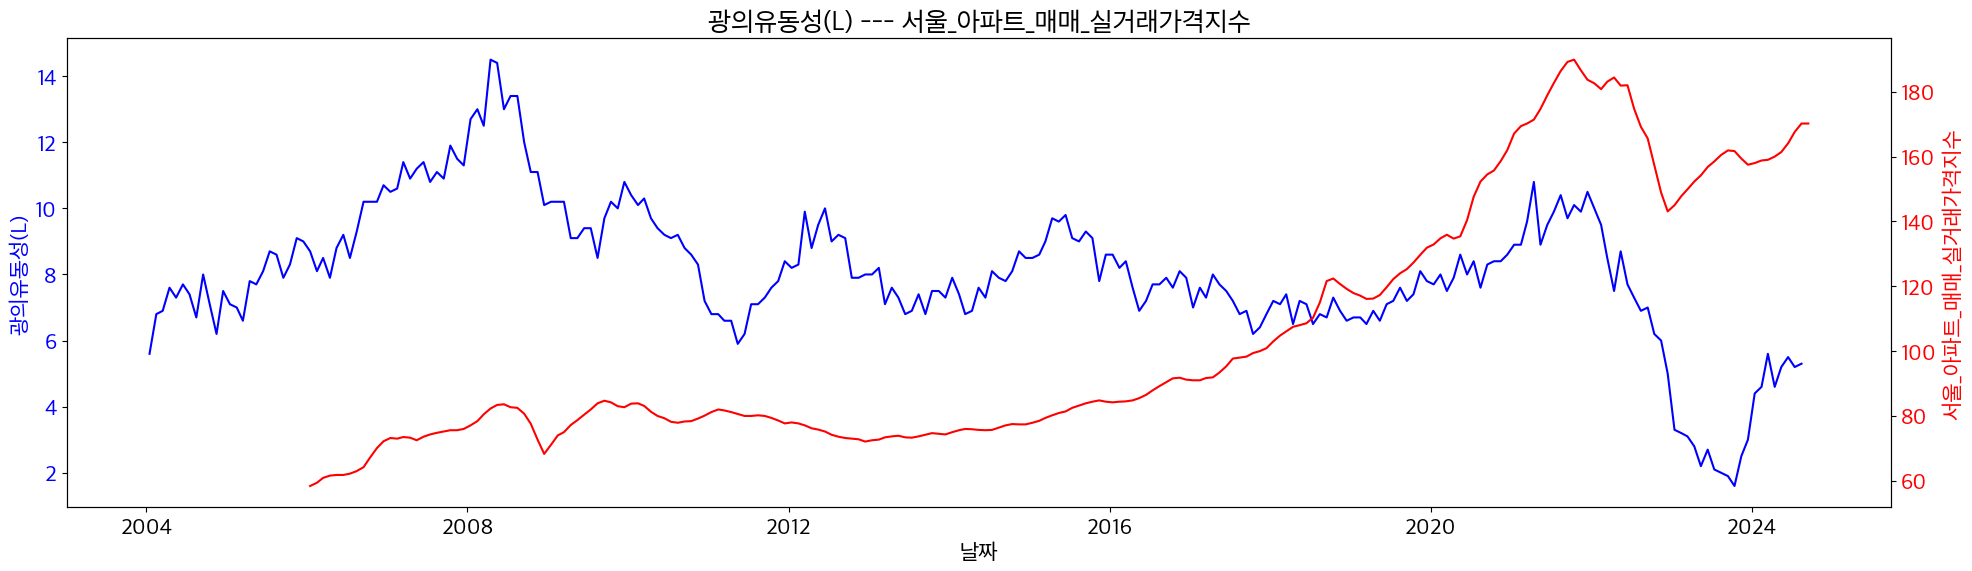

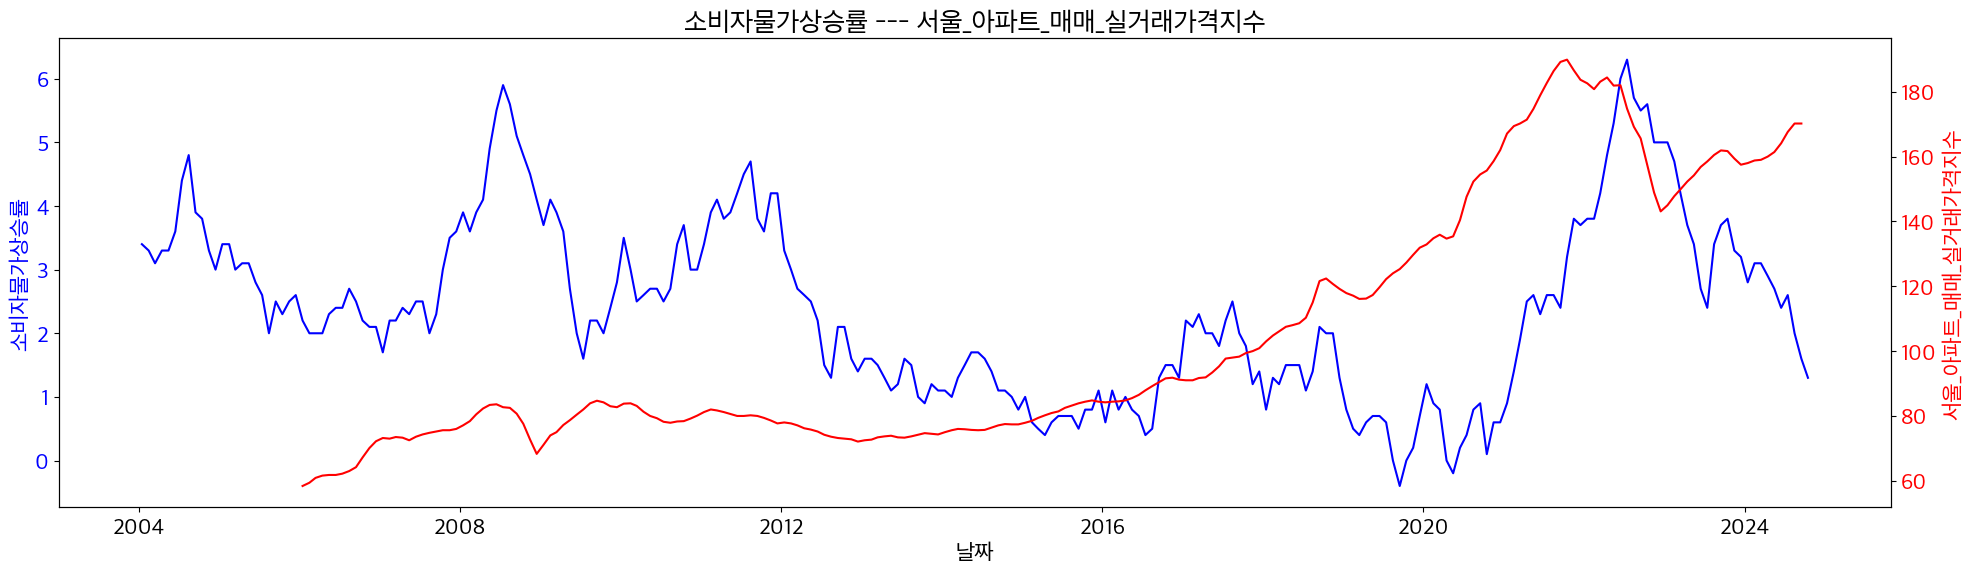

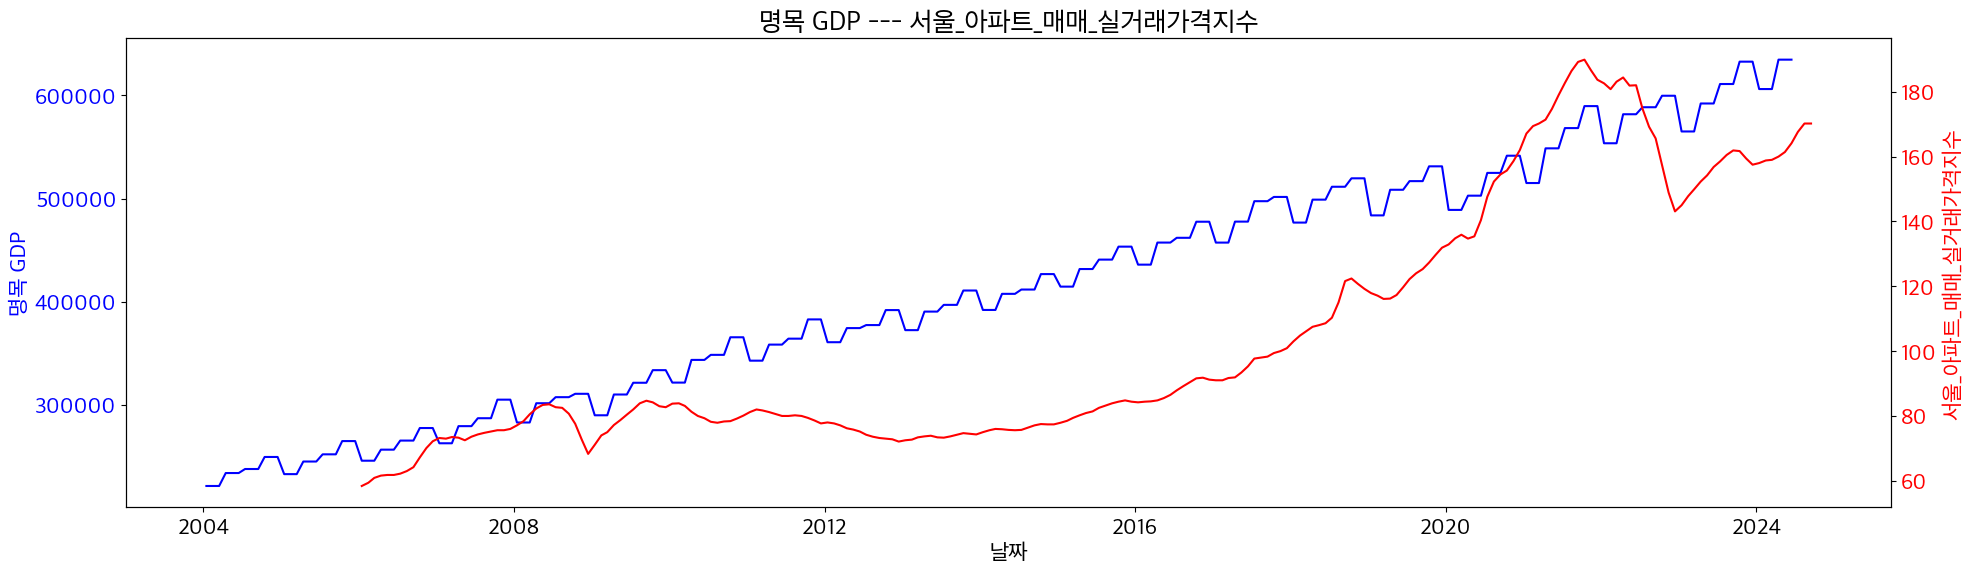

/var/folders/pc/0_qqcqxd1fncd71rzs72fhr00000gn/T/ipykernel_20472/526132485.py:25: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.tight_layout()  # 그래프 요소들 간의 레이아웃 조정
/Users/yeojisu/opt/anaconda3/envs/cv2024/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


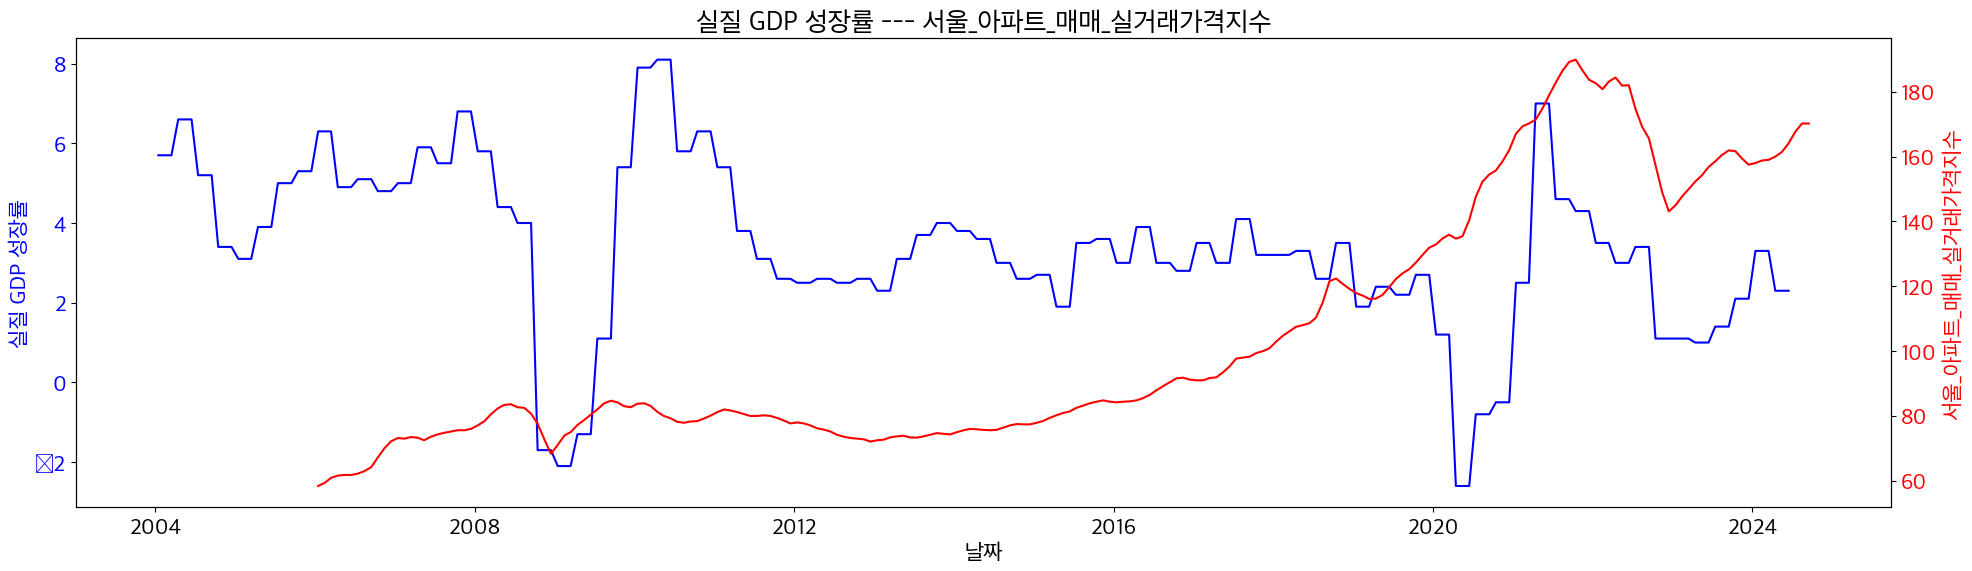

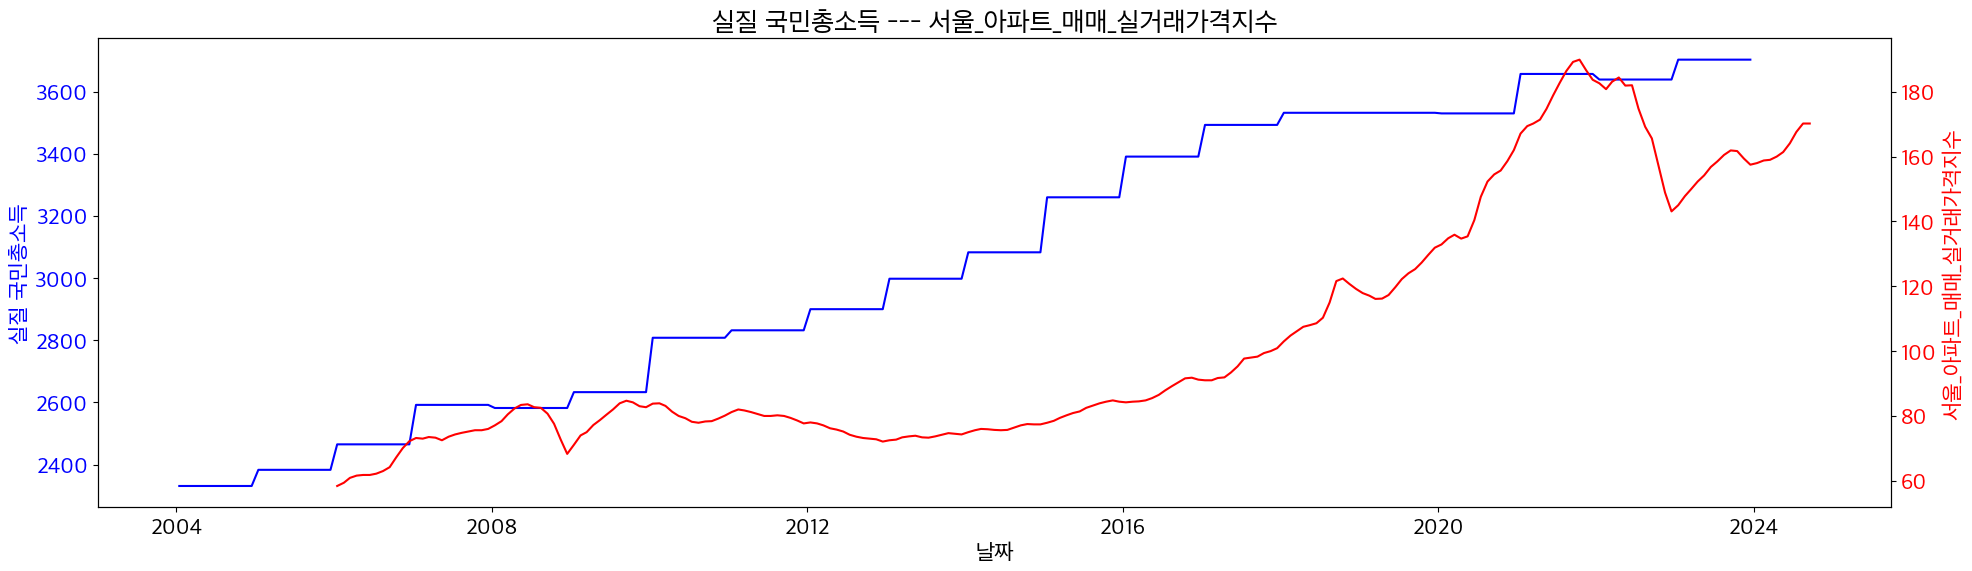

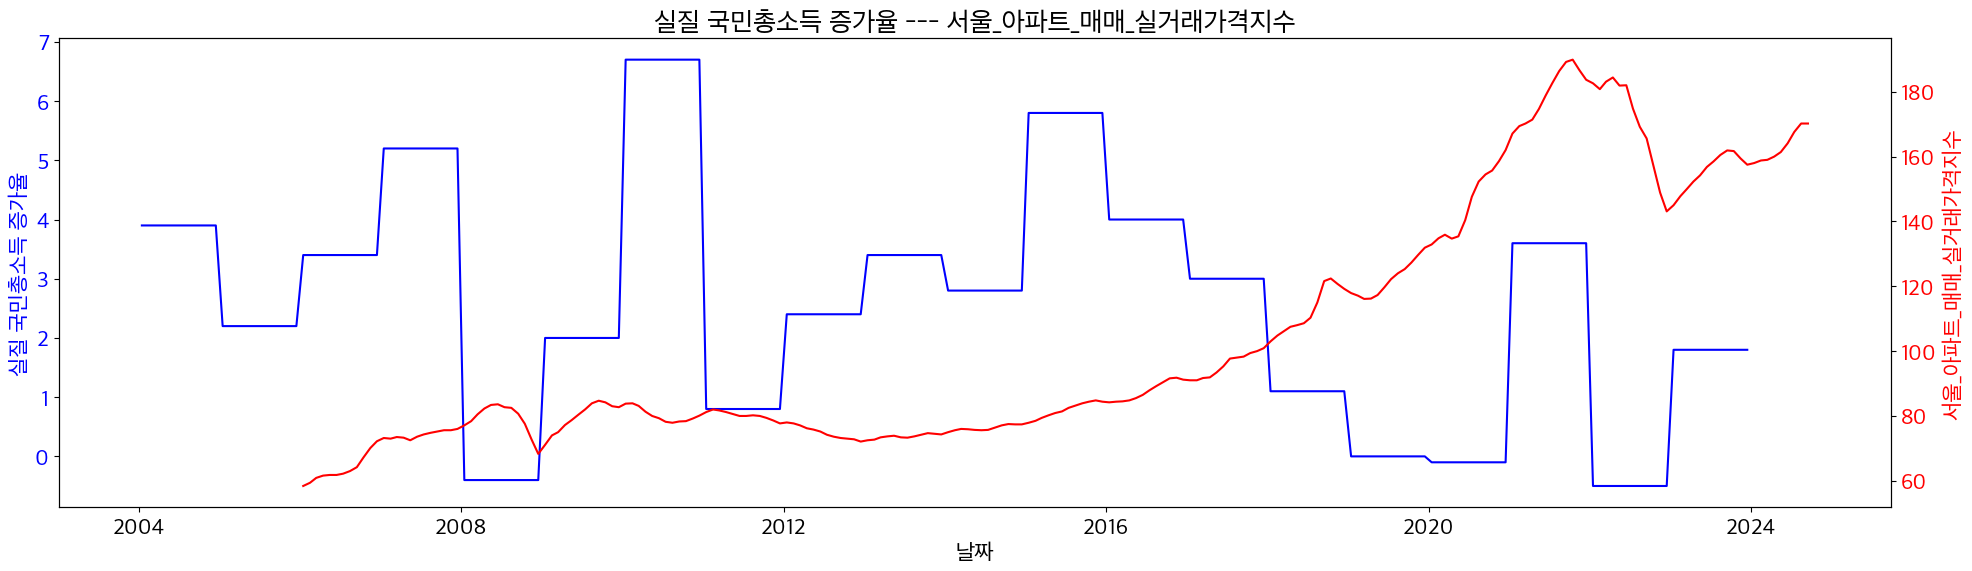

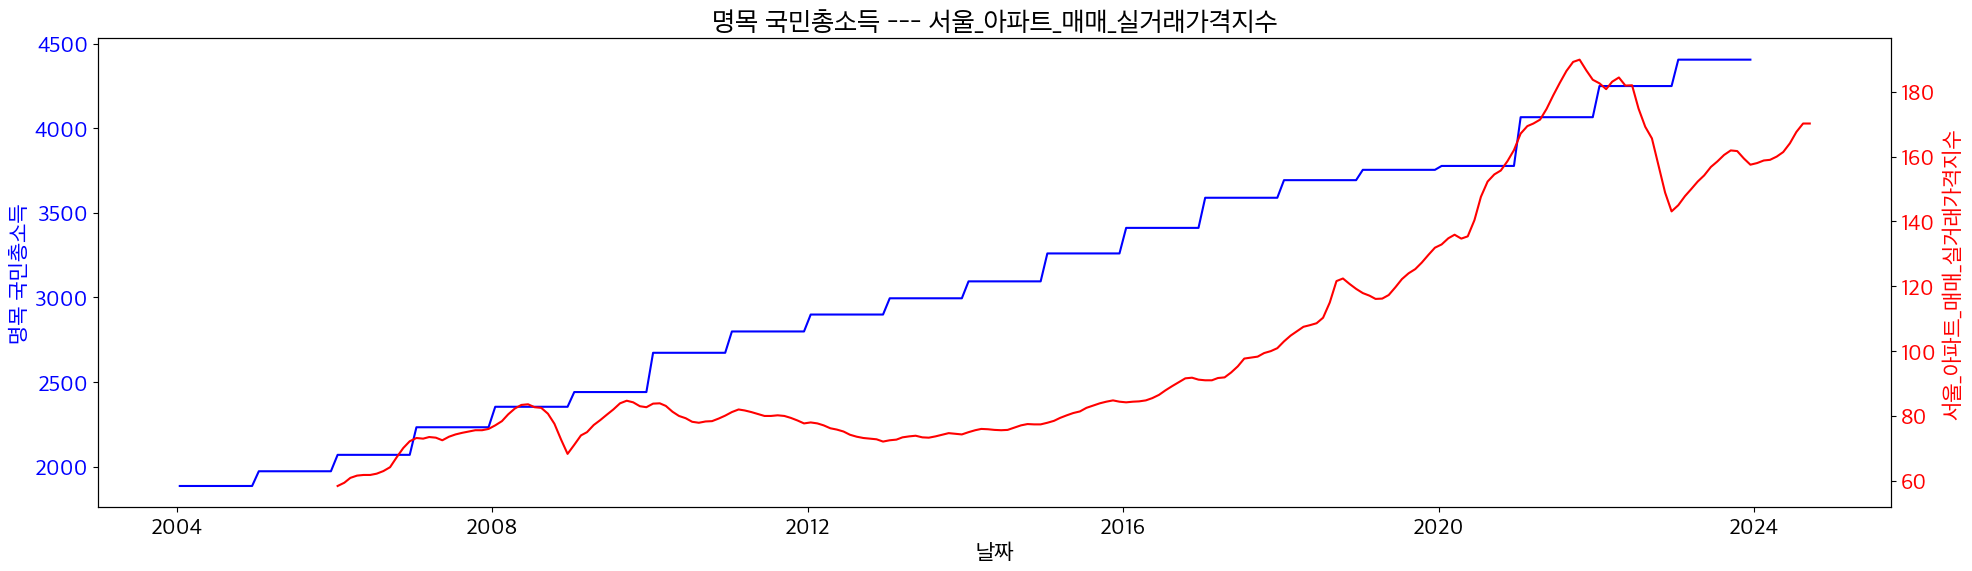

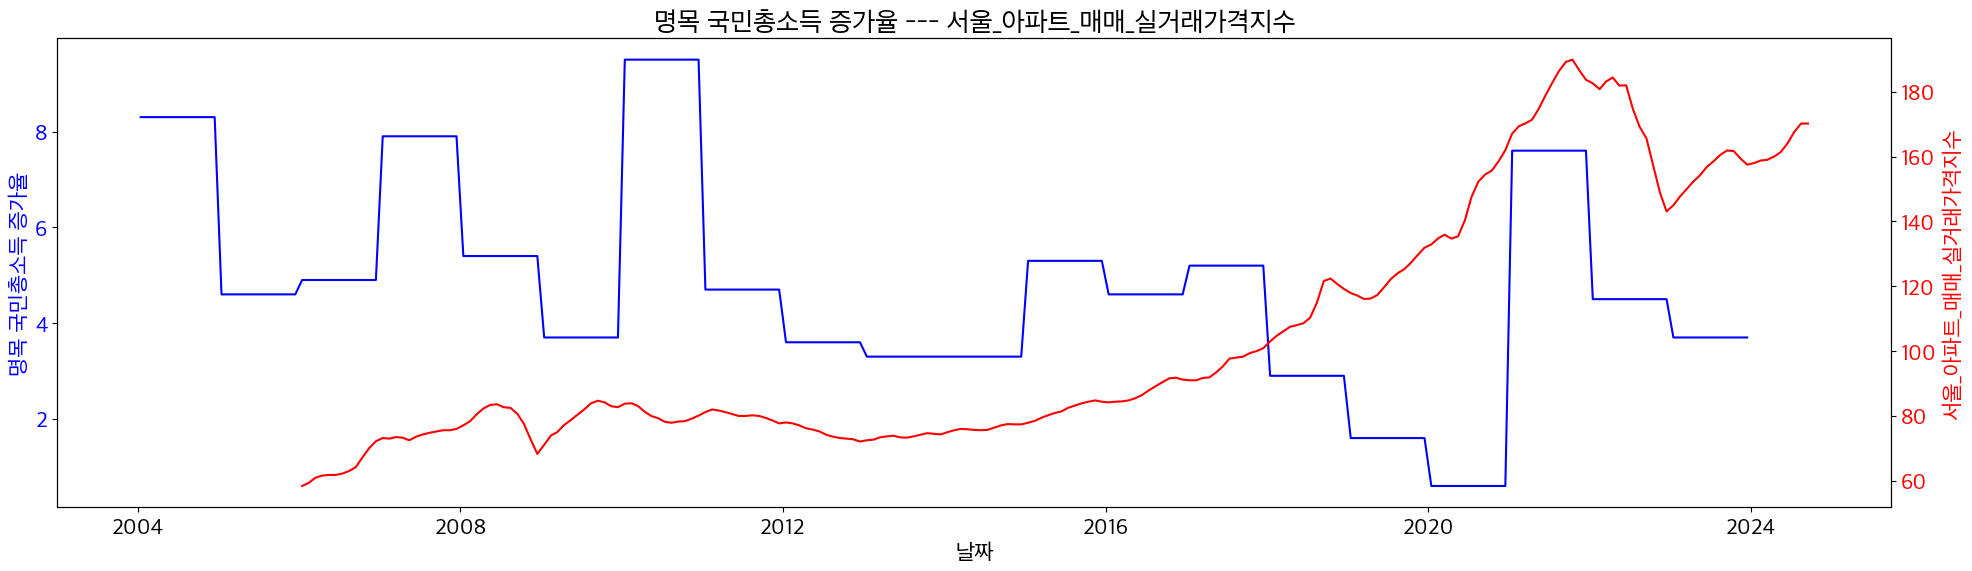

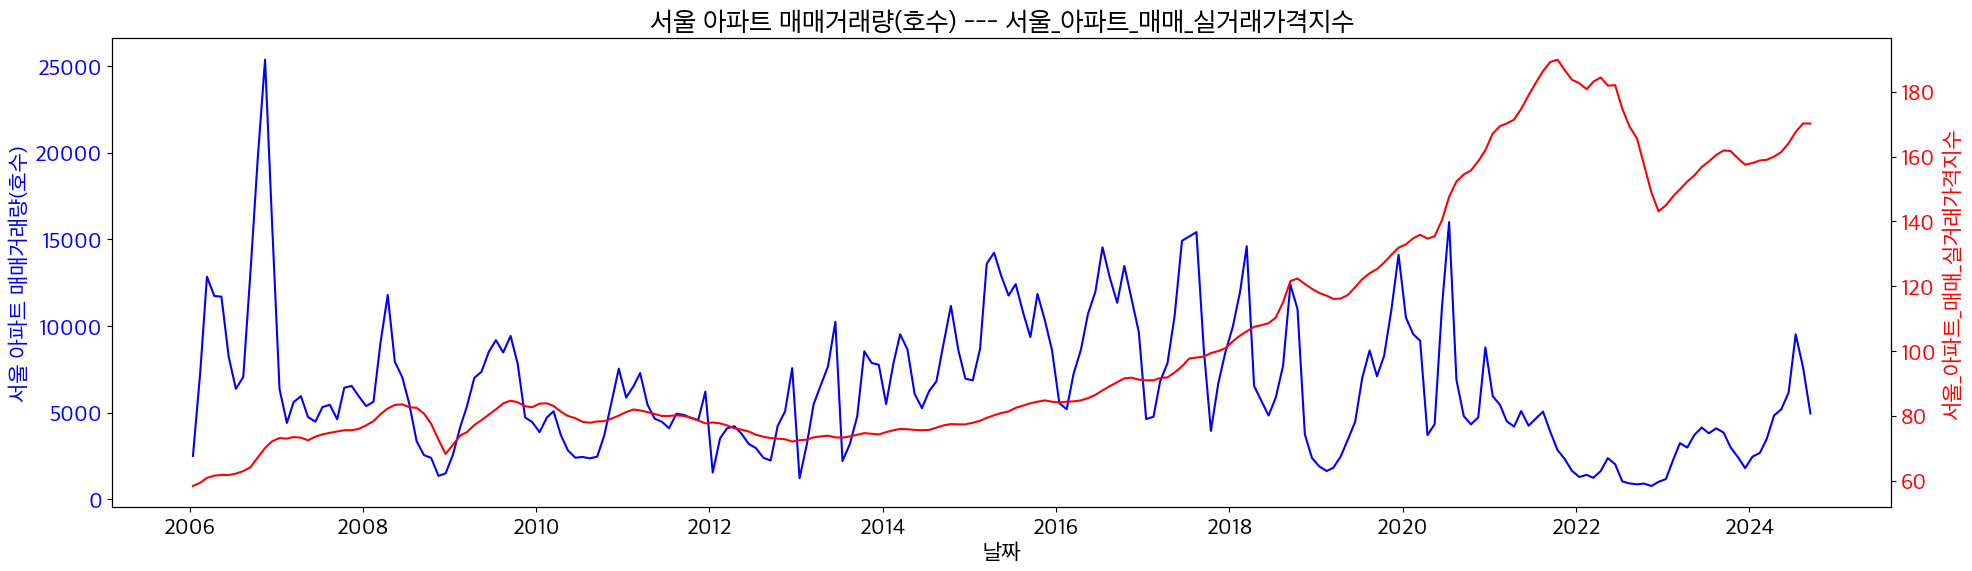

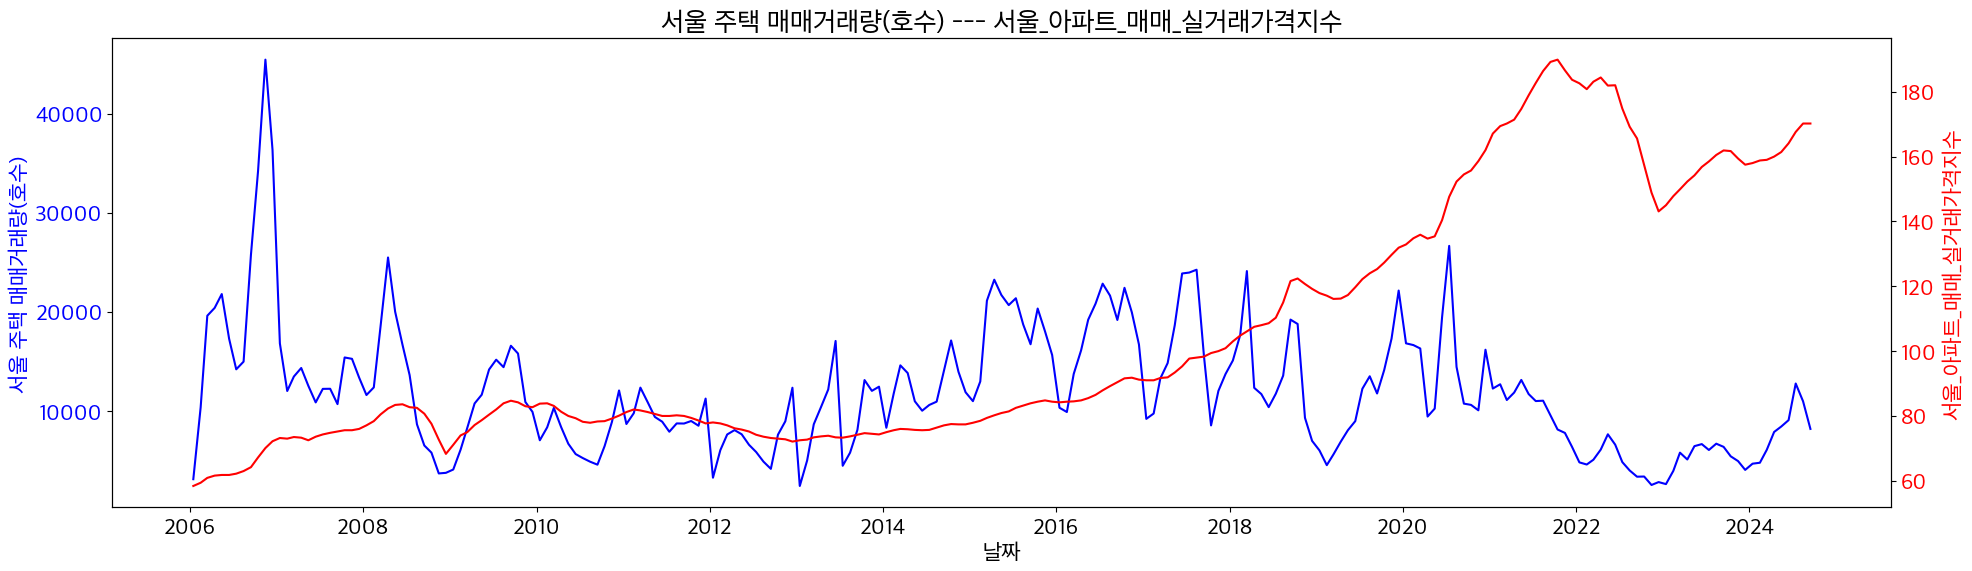

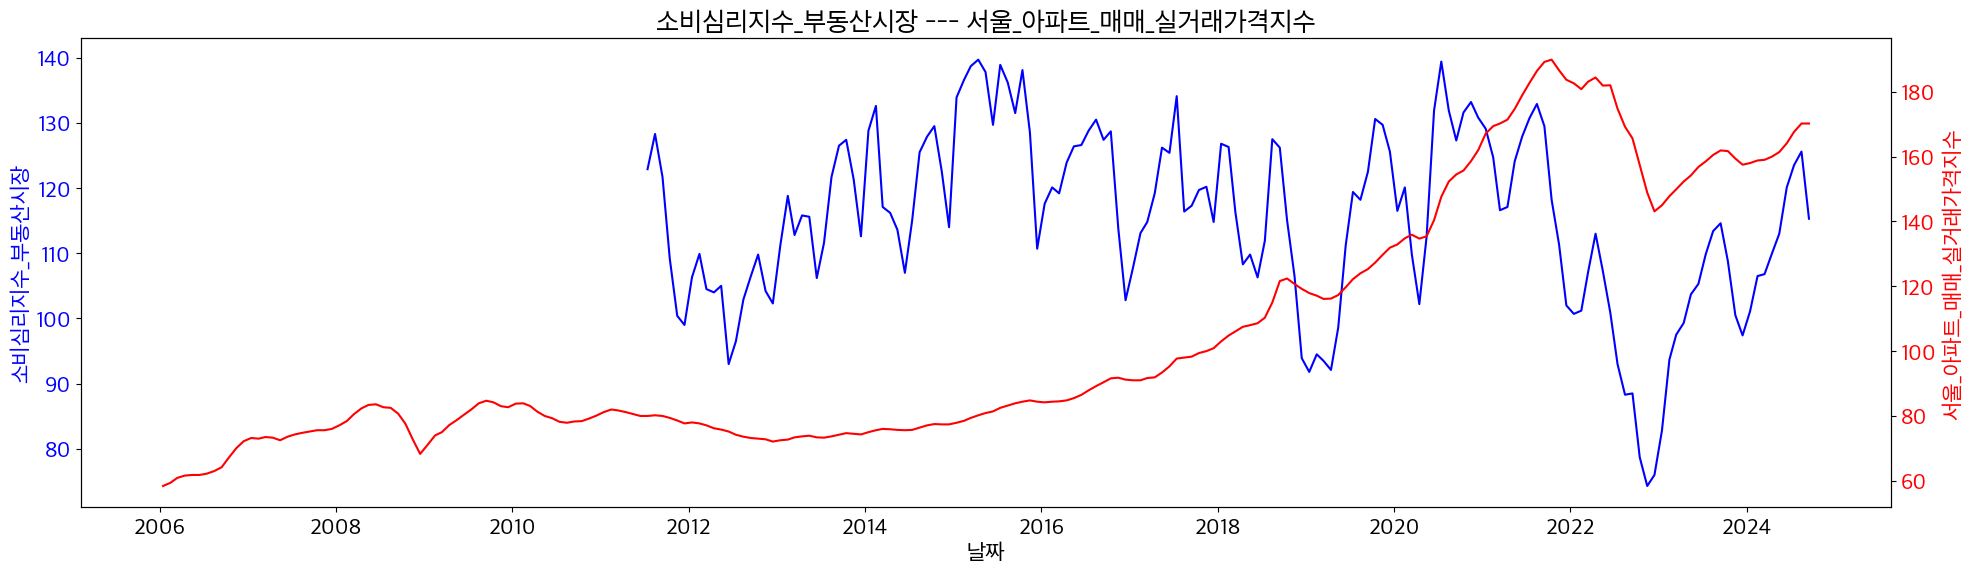

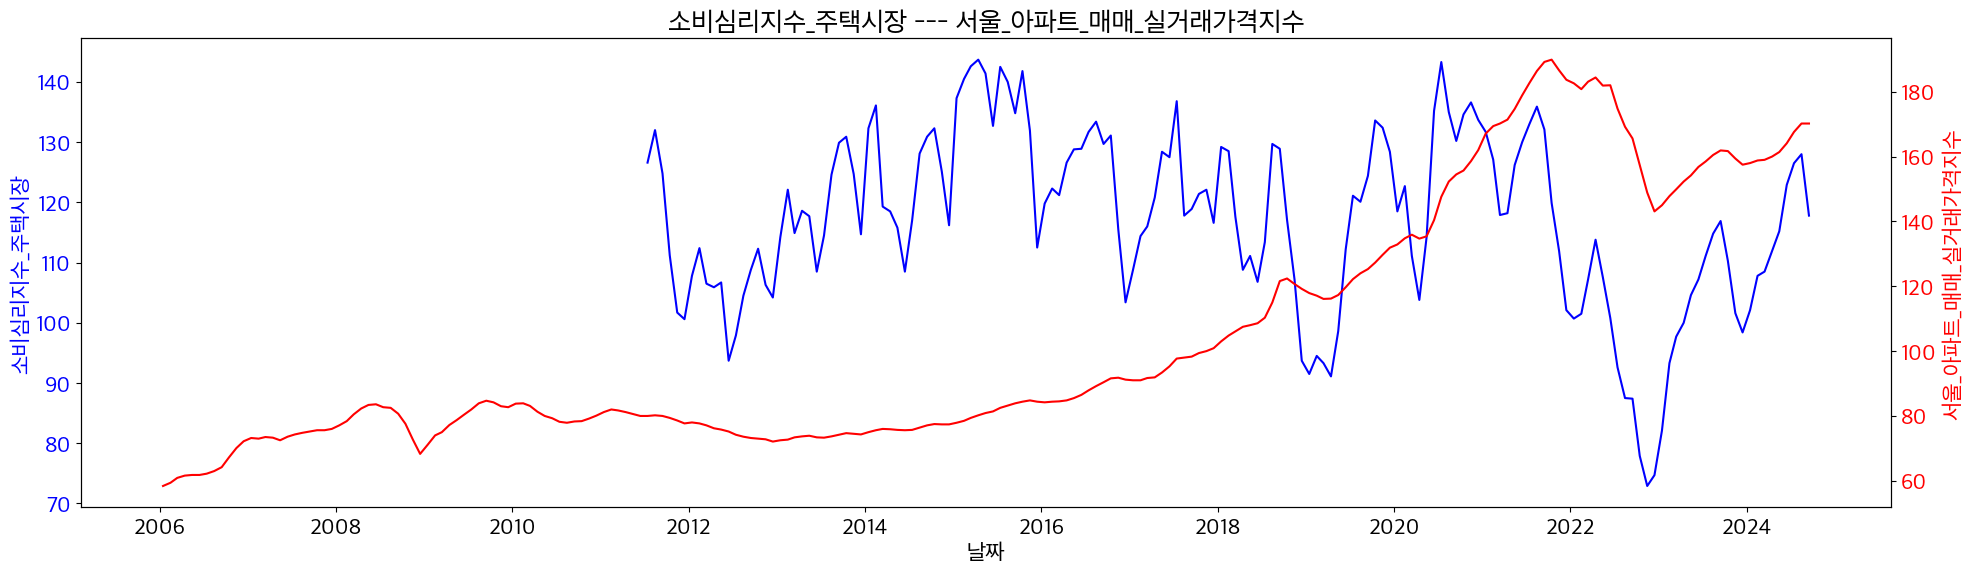

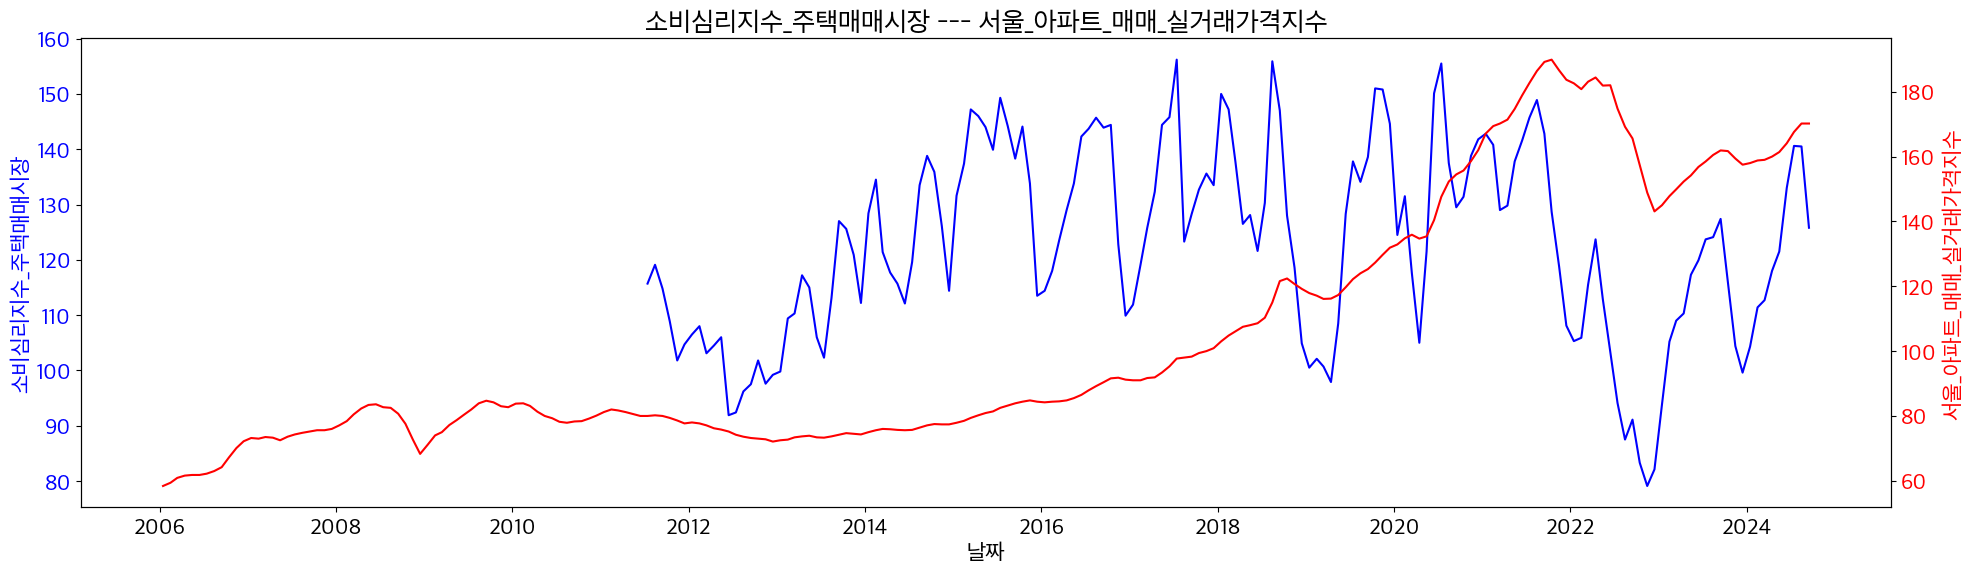

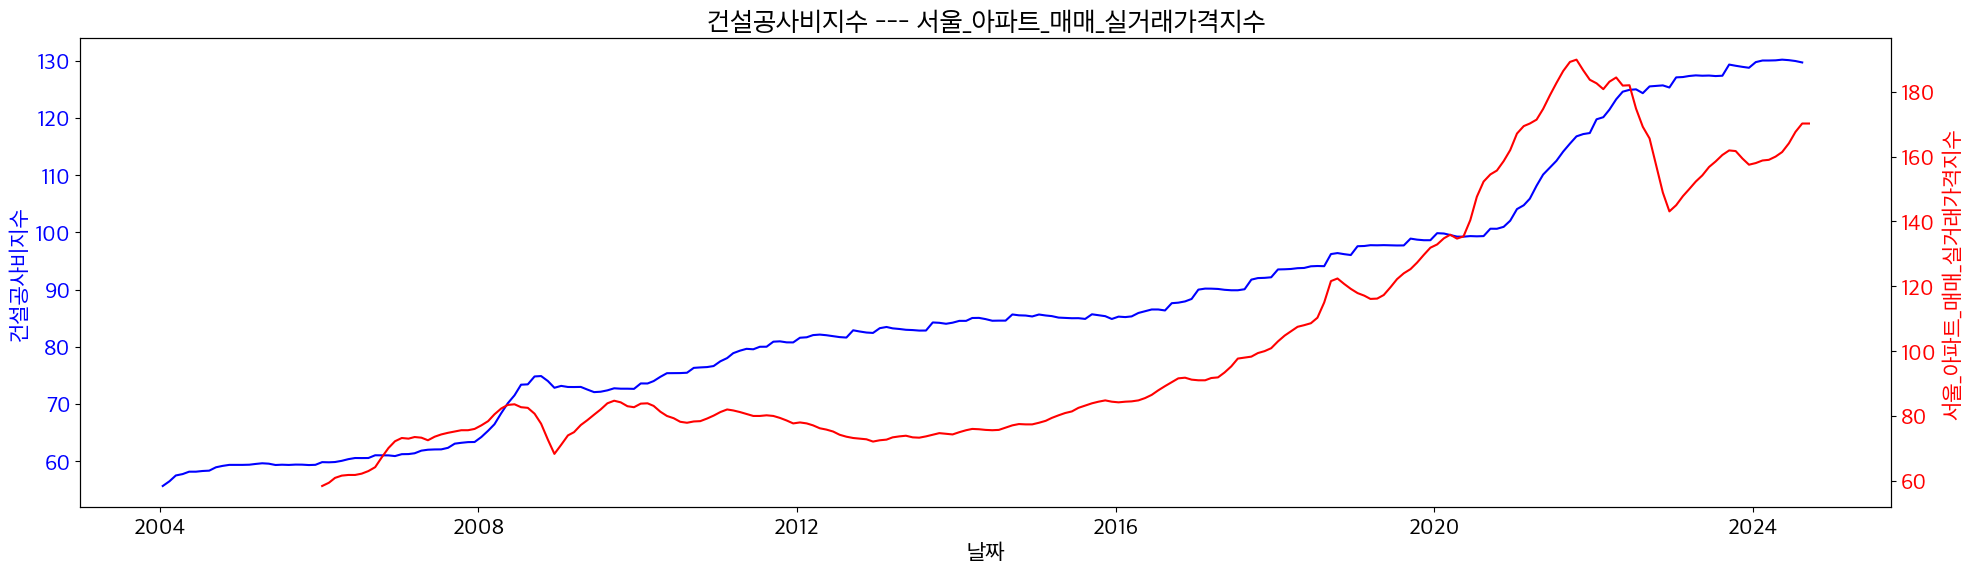

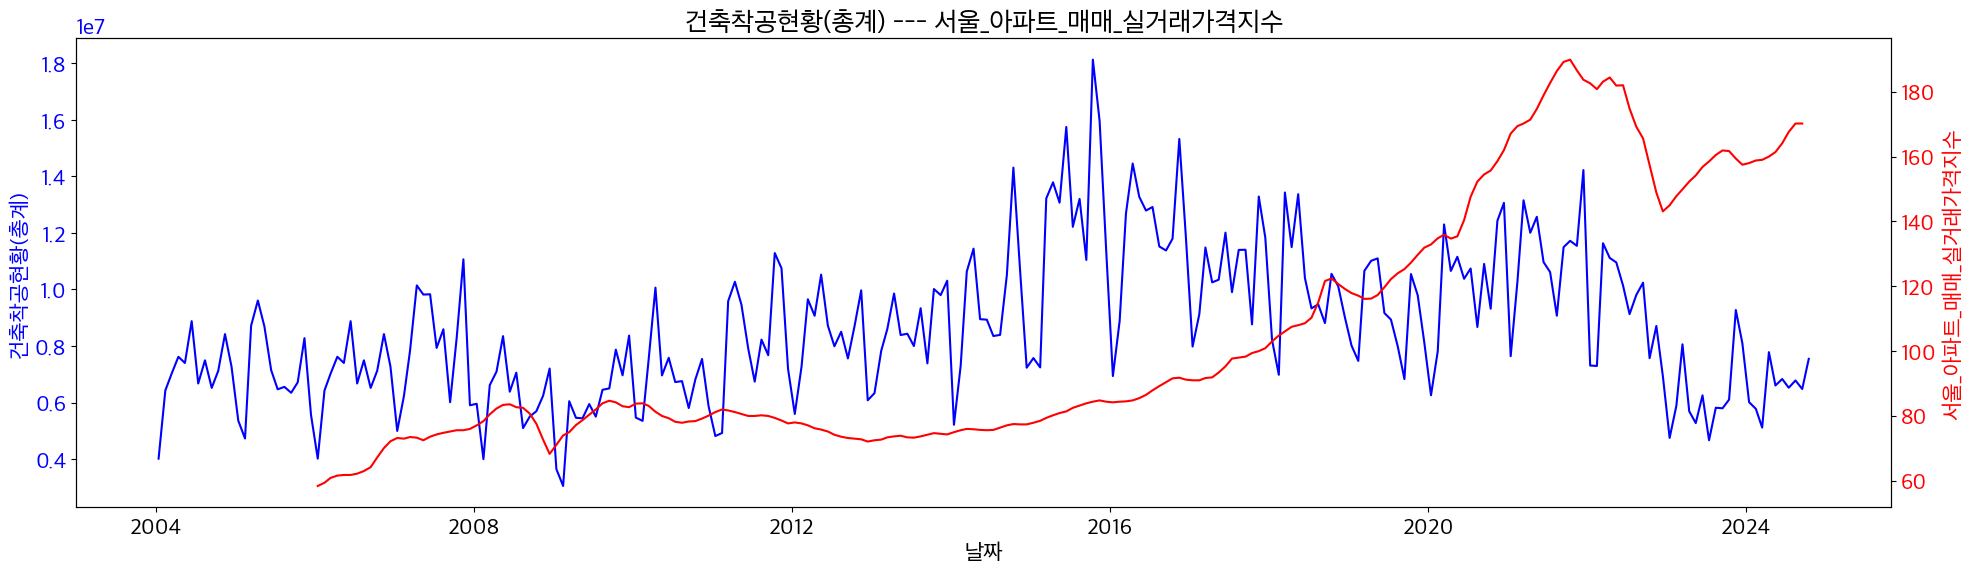

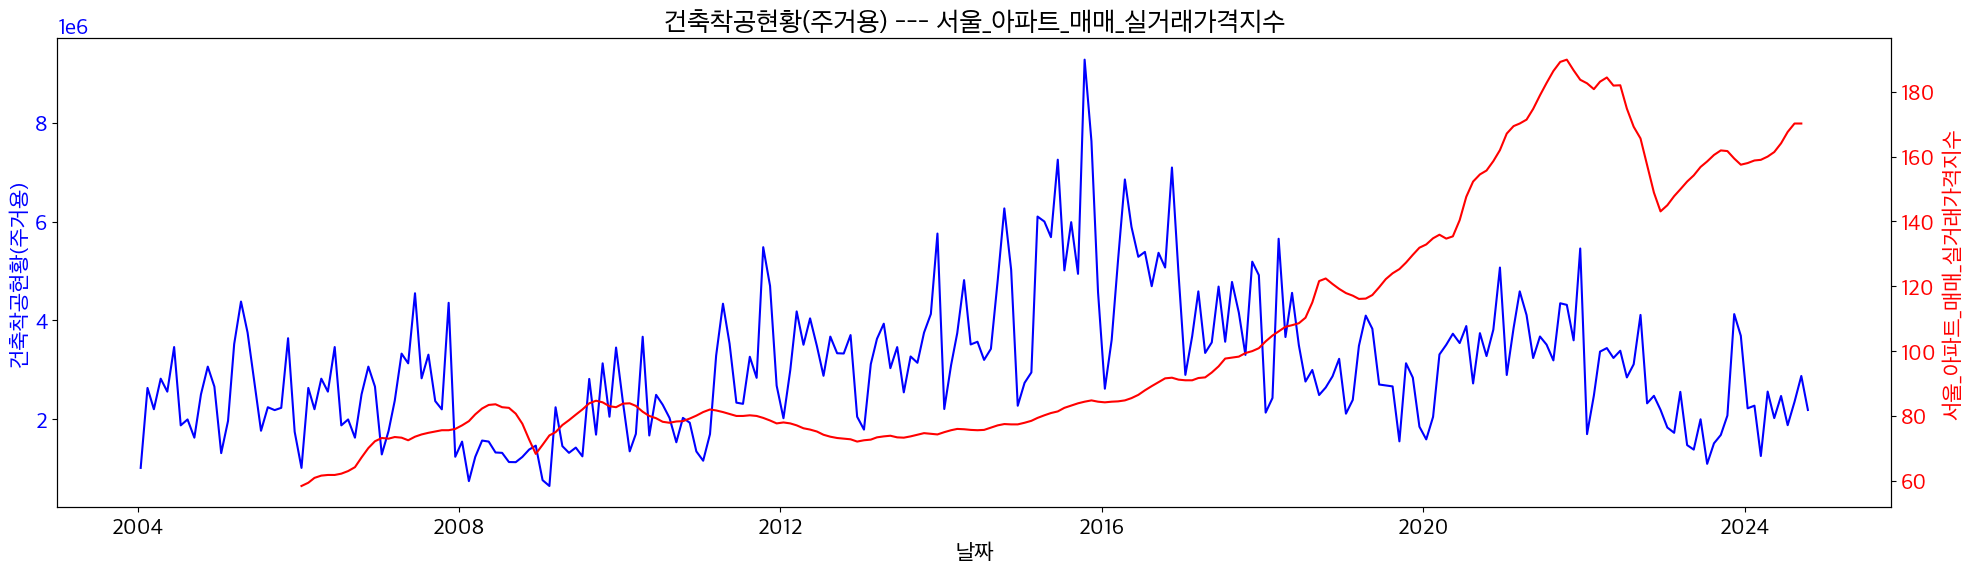

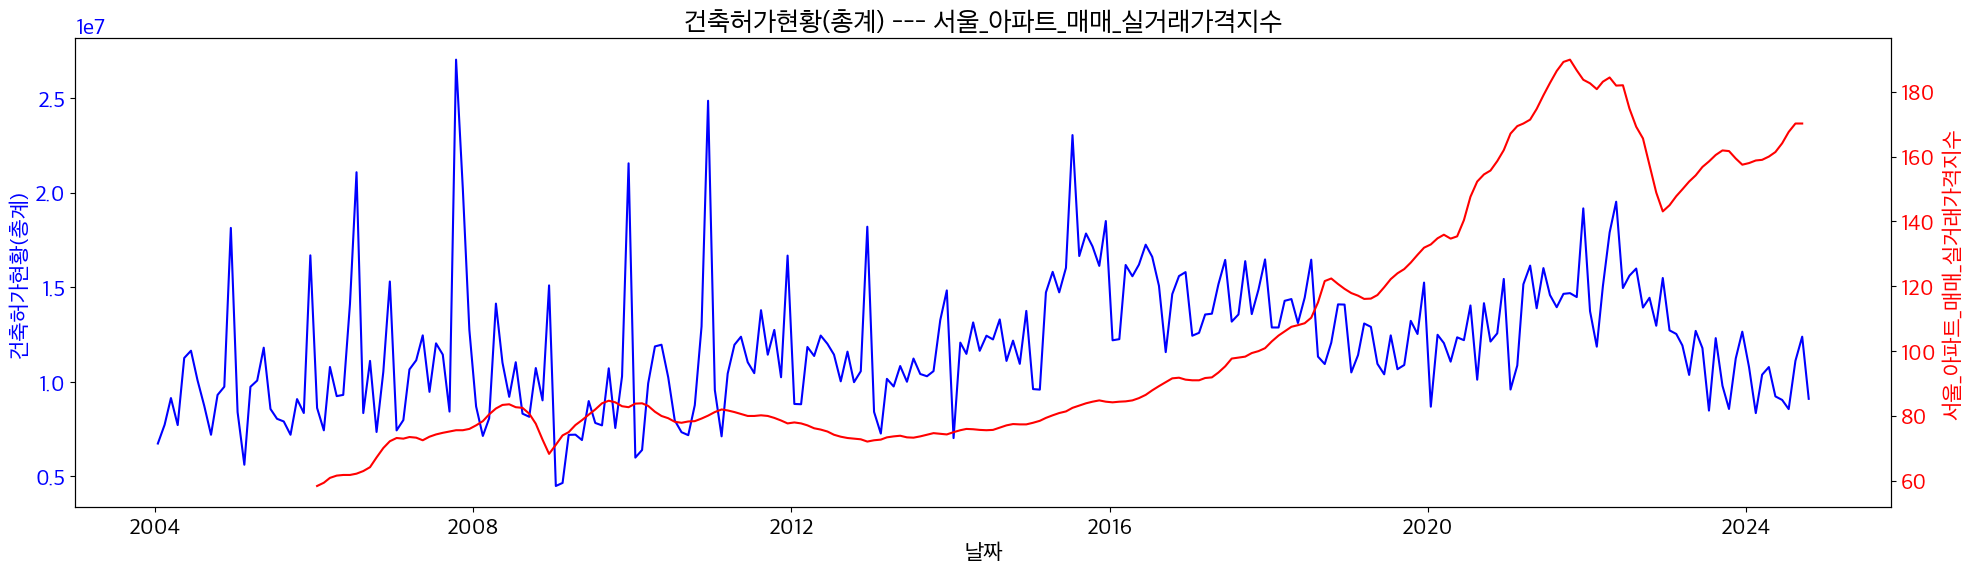

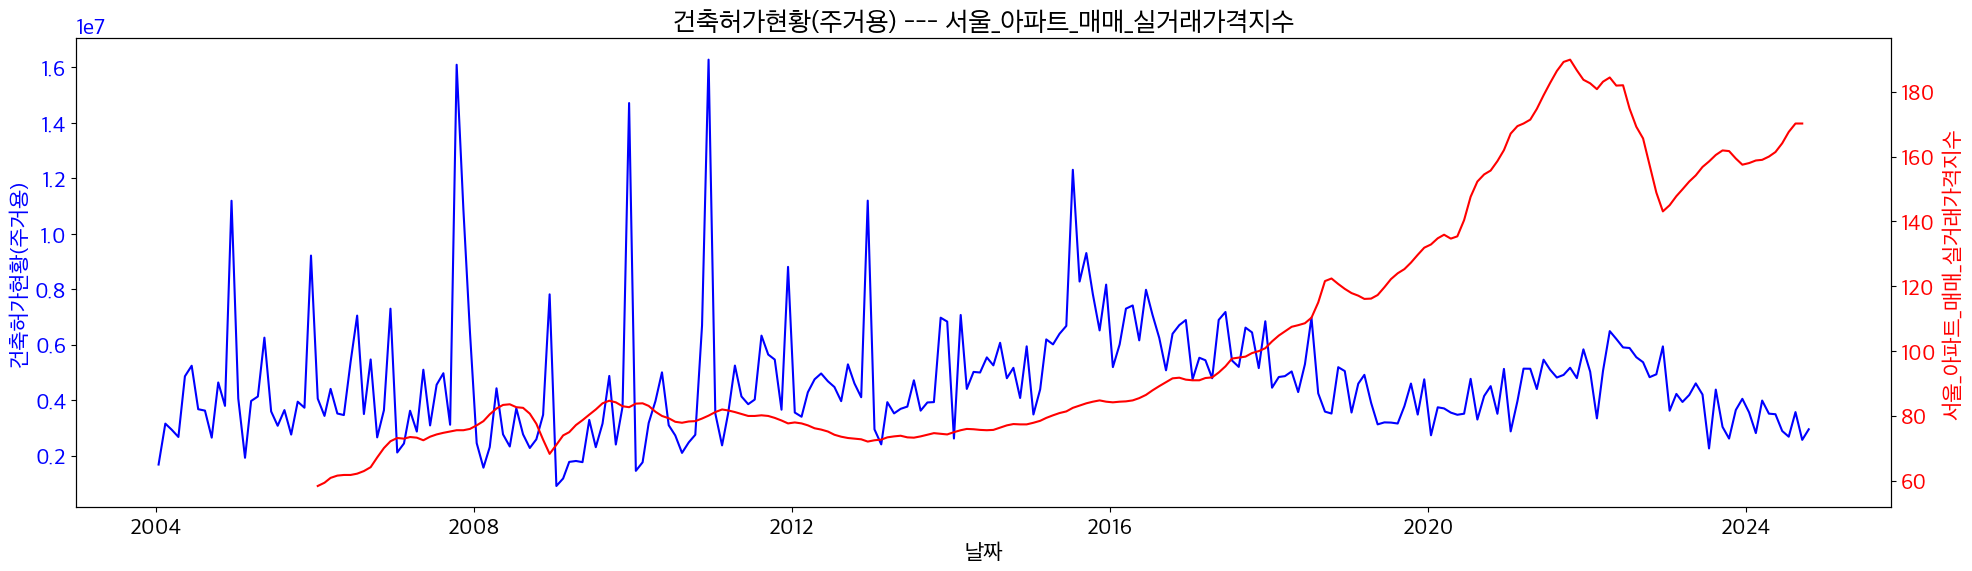

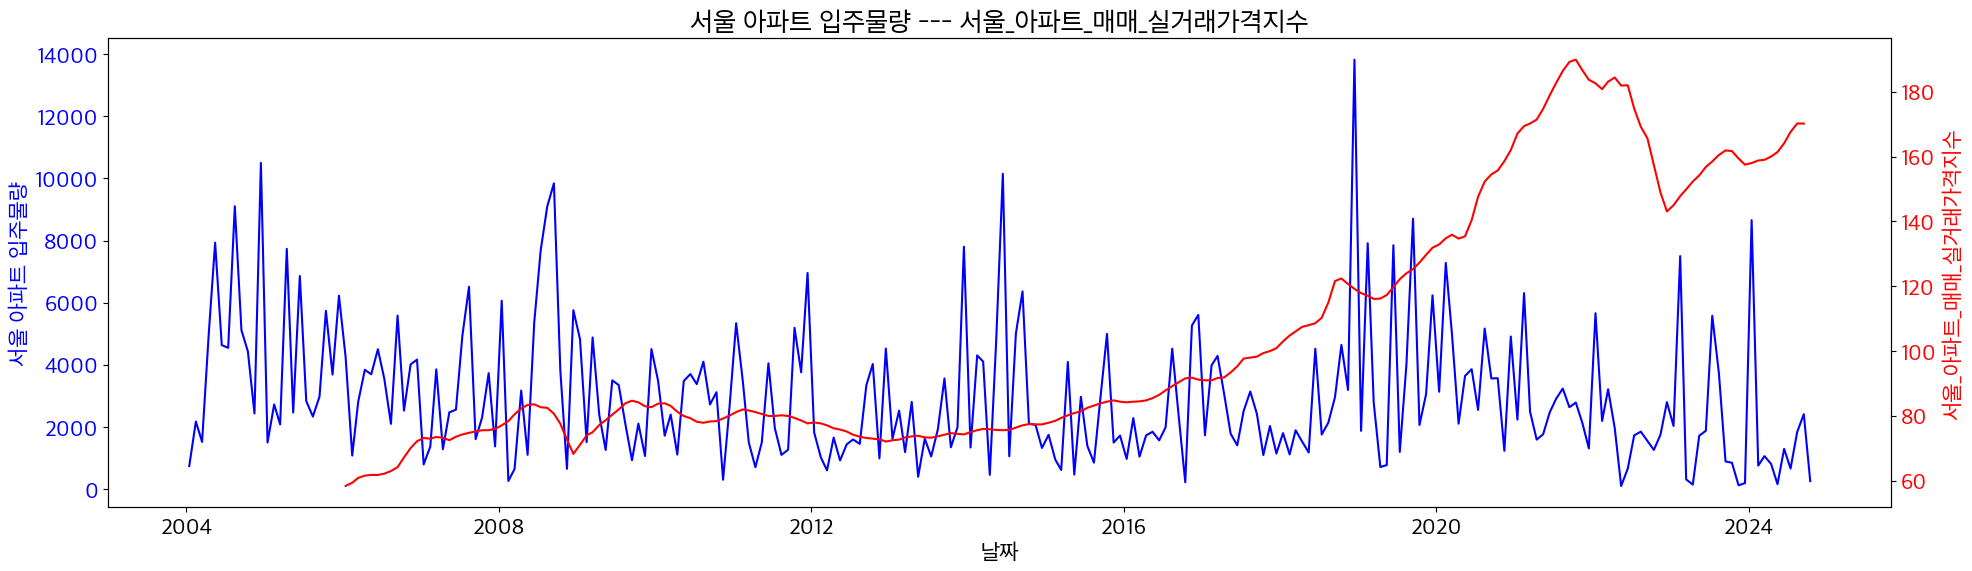

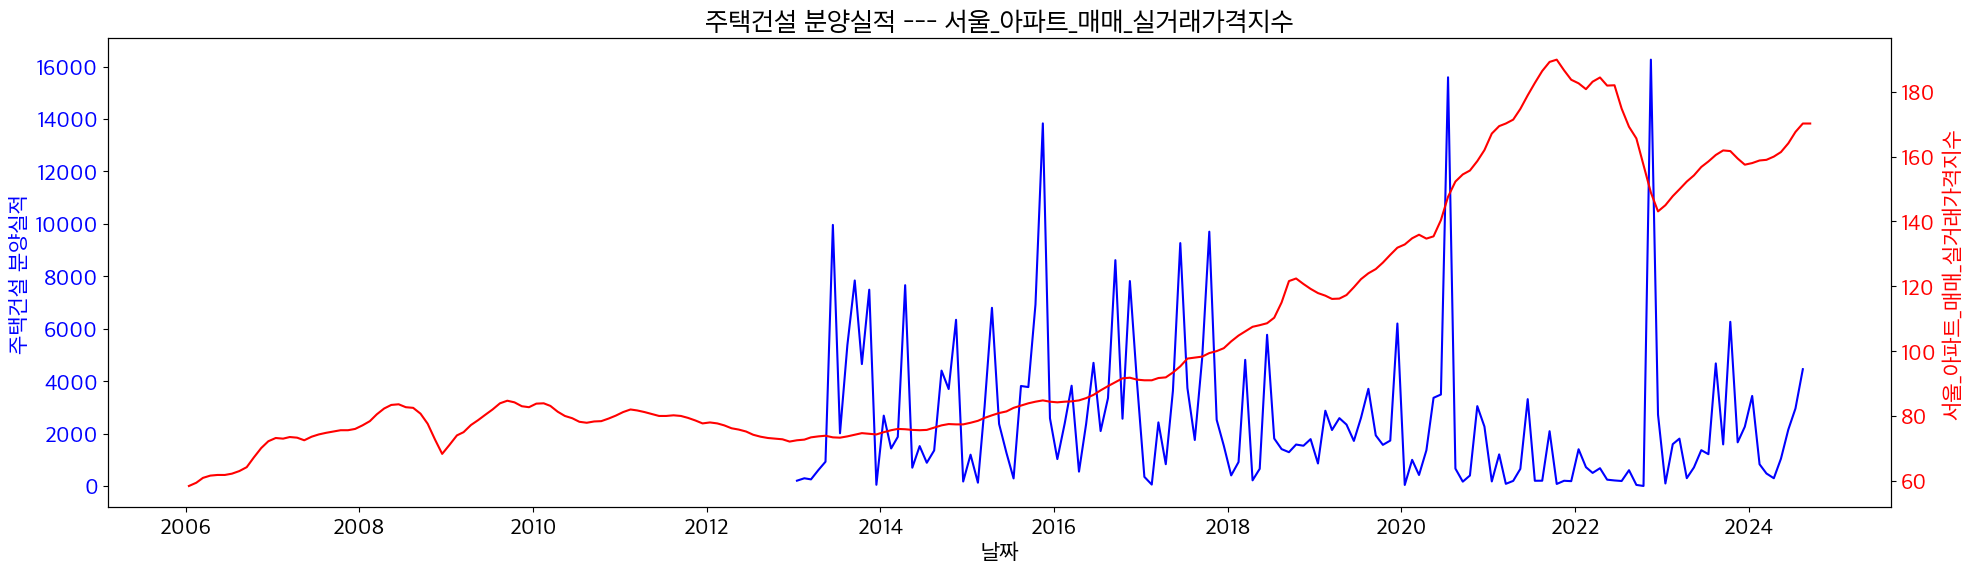

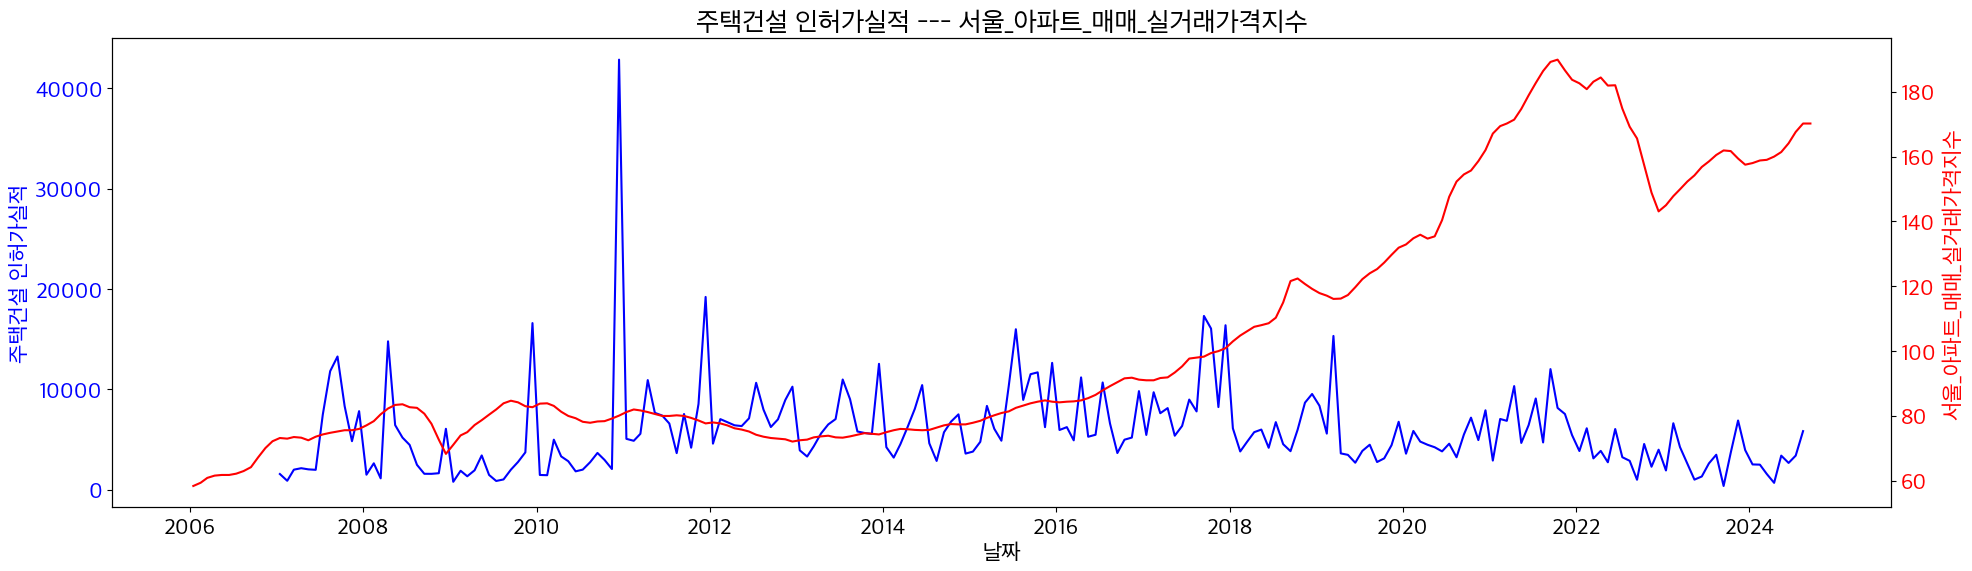

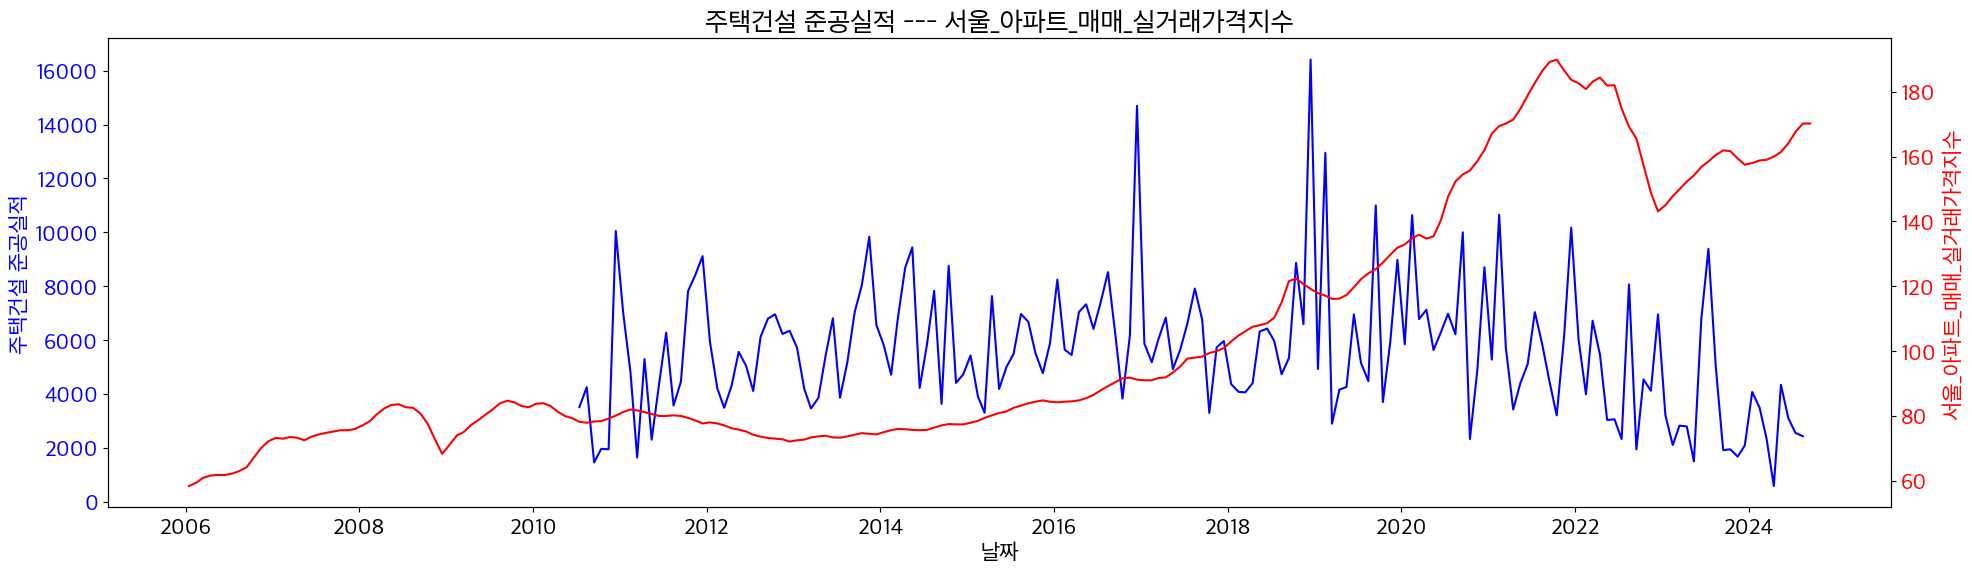

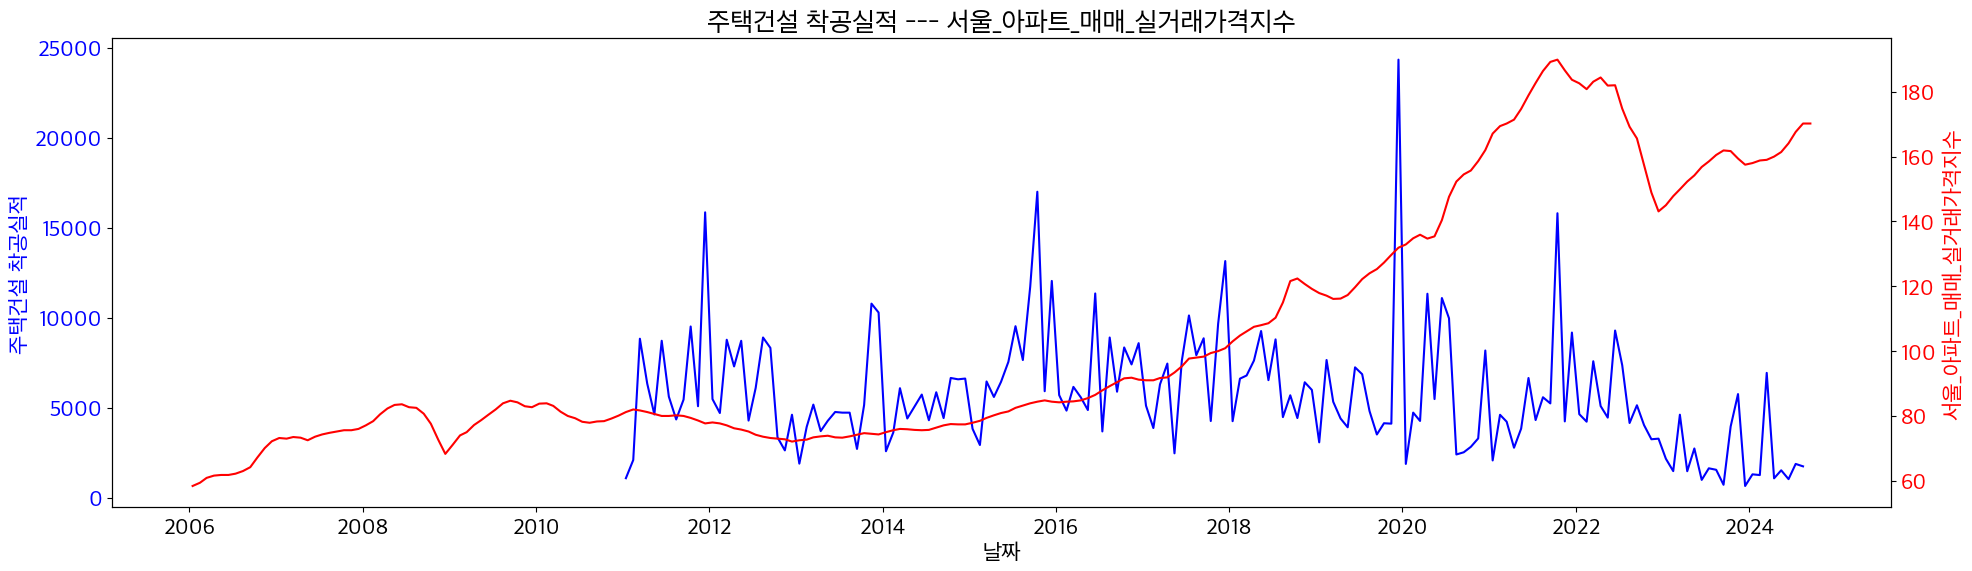

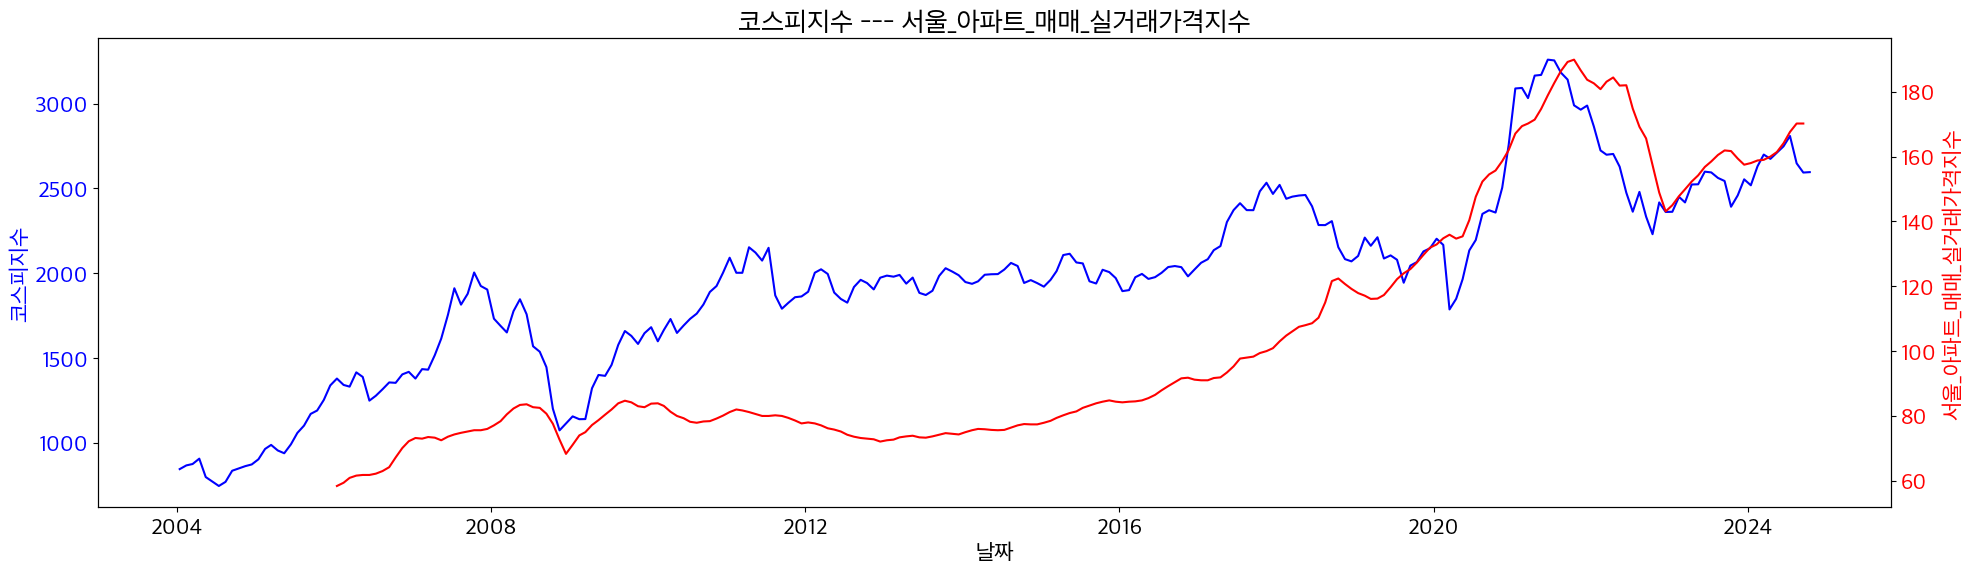

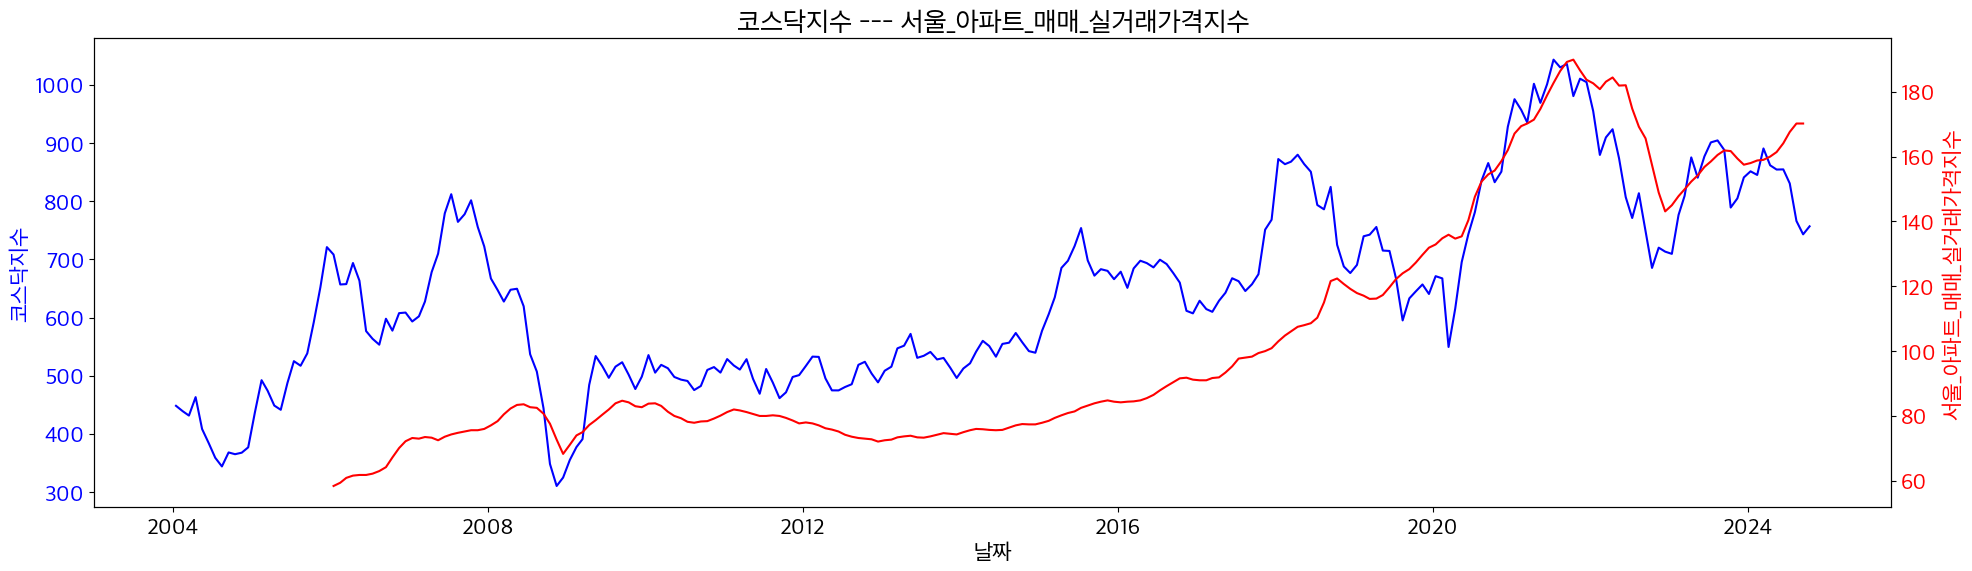

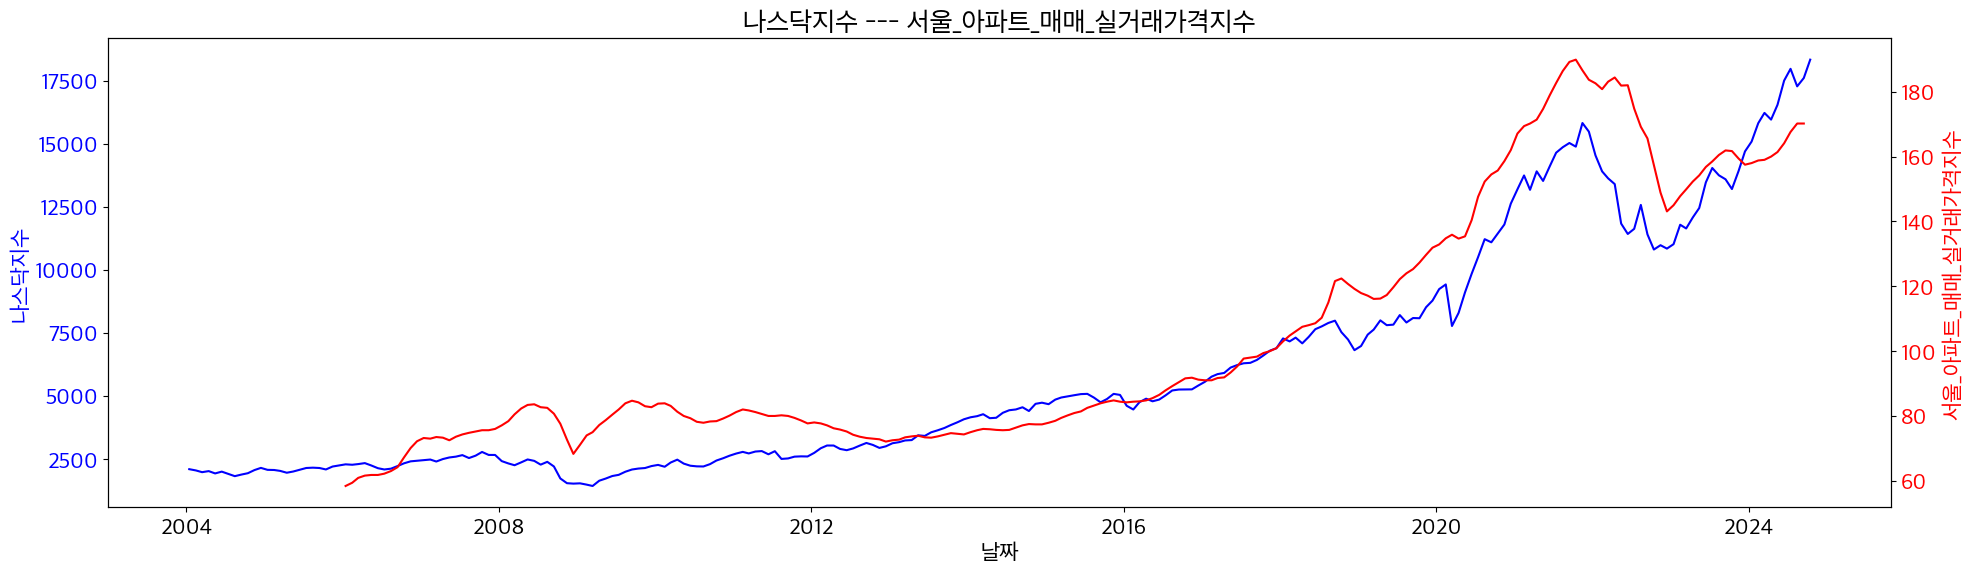

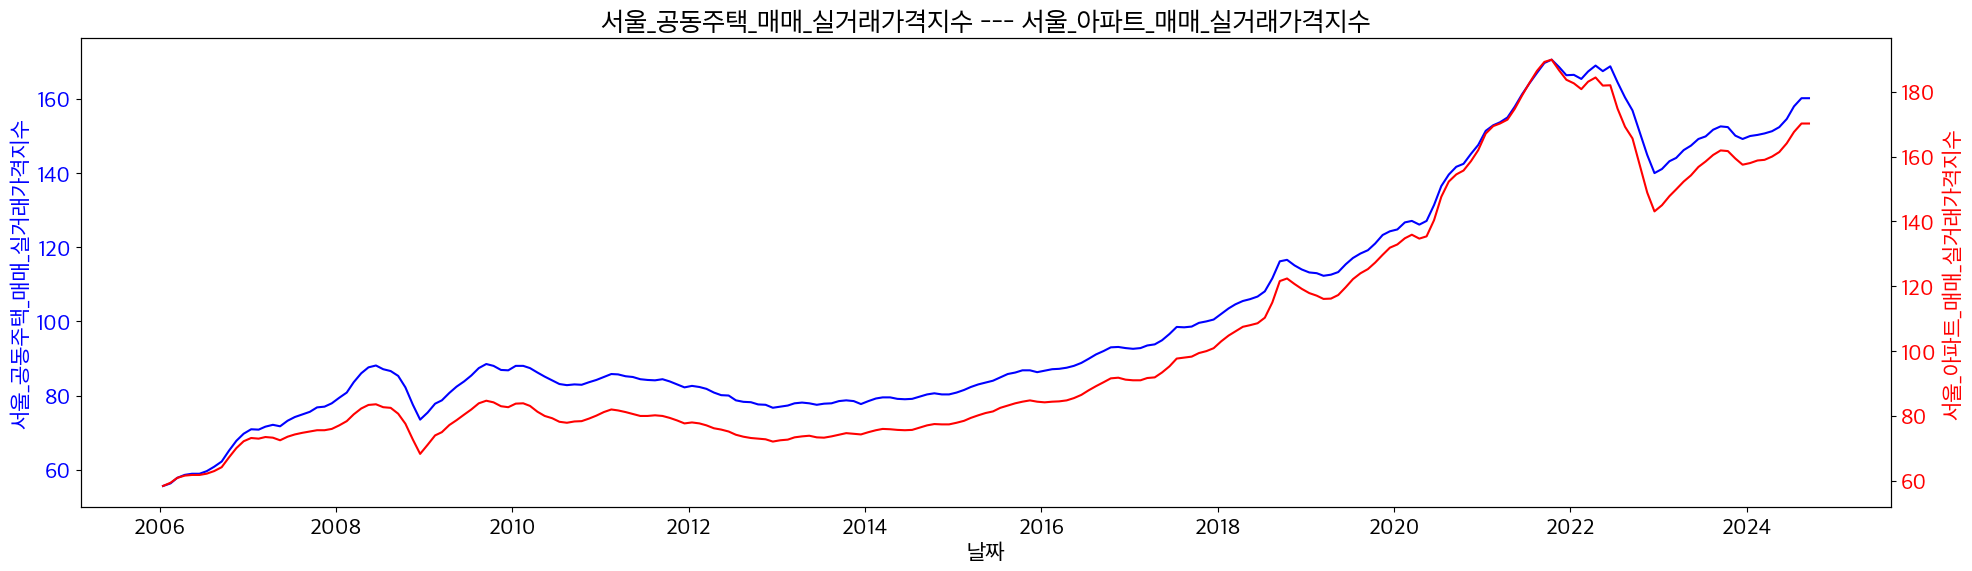

In [5]:
k = 1
value_y = df.loc[len(df)-1].values[k:] 
label_y = df.loc[len(df)-1].values[0] 

for i in range(0, len(df)-1) : 
    
    value_x = df.loc[i].values[k:]
    label_x = df.loc[i].values[0]
    fig, ax1 = plt.subplots(figsize=(20, 6))

    # 첫 번째 축 (왼쪽 y축)
    ax1.plot(pd.to_datetime(df.columns[k:], format='mixed'), pd.to_numeric(np.char.replace(value_x.astype(str), ',', ''), errors='coerce'), color='b', label=label_x)
    ax1.set_xlabel('날짜')
    ax1.set_ylabel(label_x, color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    # 두 번째 축 (오른쪽 y축)
    ax2 = ax1.twinx()  # 두 번째 축 생성
    ax2.plot(pd.to_datetime(df.columns[k:], format='mixed'), pd.to_numeric(np.char.replace(value_y.astype(str), ',', ''), errors='coerce'), color='r', label=label_y)
    ax2.set_ylabel(label_y, color='r')
    ax2.tick_params(axis='y', labelcolor='r')

    # 그래프 타이틀 및 설정
    plt.title(label_x+" --- "+label_y)
    fig.tight_layout()  # 그래프 요소들 간의 레이아웃 조정
    plt.show()